<a href="https://colab.research.google.com/github/hj245668/ds6_mini_project/blob/main/1119_tsd_nodeMinipjt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ① tsfresh 라이브러리 설치
!pip install tsfresh

In [ ]:
# ③ robot execution 데이터셋 다운로드 및 불러오기
from tsfresh.examples.robot_execution_failures import download_robot_execution_failures, load_robot_execution_failures
download_robot_execution_failures()

④ 불러온 데이터 확인

     - timeseries : 데이터셋의 feature 입니다. (독립변수)
     - y : True, False로 되어있는 binary classification 입니다. (종속변수)

In [ ]:
# ④ 불러온 데이터 확인
timeseries, y = load_robot_execution_failures()

In [ ]:
timeseries

,id,time,F_x,F_y,F_z,T_x,T_y,T_z
0,1,0,-1,-1,63,-3,-1,0
1,1,1,0,0,62,-3,-1,0
2,1,2,-1,-1,61,-3,0,0
3,1,3,-1,-1,63,-2,-1,0
4,1,4,-1,-1,63,-3,-1,0
...,...,...,...,...,...,...,...,...
1315,88,10,-10,2,39,-21,-24,5
1316,88,11,-11,2,38,-24,-22,6
1317,88,12,-12,3,23,-24,-24,5
1318,88,13,-13,4,26,-29,-27,5


In [ ]:
y

,0
1,True
2,True
3,True
4,True
5,True
...,...
84,False
85,False
86,False
87,False


In [6]:
y

,0
1,True
2,True
3,True
4,True
5,True
...,...
84,False
85,False
86,False
87,False


In [7]:
# ⑤ 특징 추출(feature extraction)
from tsfresh import extract_features
extracted_features = extract_features(timeseries, column_id="id", column_sort="time")

Feature Extraction: 100%|██████████| 528/528 [00:52<00:00,  9.98it/s]


In [8]:
extracted_features

,F_x__variance_larger_than_standard_deviation,F_x__has_duplicate_max,F_x__has_duplicate_min,F_x__has_duplicate,F_x__sum_values,F_x__abs_energy,F_x__mean_abs_change,F_x__mean_change,F_x__mean_second_derivative_central,F_x__median,...,T_z__fourier_entropy__bins_5,T_z__fourier_entropy__bins_10,T_z__fourier_entropy__bins_100,T_z__permutation_entropy__dimension_3__tau_1,T_z__permutation_entropy__dimension_4__tau_1,T_z__permutation_entropy__dimension_5__tau_1,T_z__permutation_entropy__dimension_6__tau_1,T_z__permutation_entropy__dimension_7__tau_1,T_z__query_similarity_count__query_None__threshold_0.0,T_z__mean_n_absolute_max__number_of_maxima_7
1,0.0,0.0,1.0,1.0,-14.0,14.0,0.142857,0.000000,-0.038462,-1.0,...,NaN,NaN,NaN,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,NaN,0.000000
2,0.0,1.0,1.0,1.0,-13.0,25.0,1.000000,0.000000,-0.038462,-1.0,...,1.073543,1.494175,2.079442,0.937156,1.234268,1.540306,1.748067,1.831020,NaN,0.571429
3,0.0,0.0,1.0,1.0,-10.0,12.0,0.714286,0.000000,-0.038462,-1.0,...,1.386294,1.732868,2.079442,1.265857,1.704551,2.019815,2.163956,2.197225,NaN,0.571429
4,0.0,1.0,1.0,1.0,-6.0,16.0,1.214286,-0.071429,-0.038462,0.0,...,1.073543,1.494175,2.079442,1.156988,1.907284,2.397895,2.302585,2.197225,NaN,1.000000
5,0.0,0.0,0.0,1.0,-9.0,17.0,0.928571,-0.071429,0.038462,-1.0,...,0.900256,1.320888,2.079442,1.156988,1.863680,2.271869,2.302585,2.197225,NaN,0.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,1.0,1.0,0.0,1.0,-1073.0,96833.0,7.142857,-5.428571,-0.038462,-98.0,...,0.735622,0.735622,1.386294,1.585771,1.907284,2.098274,2.302585,2.197225,NaN,24.285714
85,1.0,0.0,1.0,1.0,143.0,1683.0,1.357143,1.071429,0.076923,8.0,...,0.735622,0.735622,1.667462,1.332245,1.308605,1.893788,2.163956,2.197225,NaN,5.571429
86,1.0,0.0,0.0,0.0,961.0,83497.0,9.071429,9.071429,0.807692,52.0,...,0.735622,1.073543,1.732868,0.687092,0.983088,1.159589,1.227529,1.303092,NaN,9.285714
87,1.0,1.0,0.0,1.0,4509.0,1405437.0,12.928571,12.214286,-1.038462,338.0,...,0.735622,0.735622,1.386294,0.535961,0.836988,1.159589,1.497866,1.581094,NaN,40.285714


⑥ impute

    - 특징 추출된 모든 값을 동일한 열의 중앙/극단값으로 바꿉니다.
         -inf -> min
         +inf -> max
         NaN -> median

⑦ select_features(X, y)

   - 특징 행렬 X의 모든 특징(열)의 중요성을 확인하고 관련 특징만 포함하는 축소된 특징 행렬을 반환합니다.(필터링



In [9]:
from tsfresh import select_features
from tsfresh.utilities.dataframe_functions import impute

# ⑥ impute
impute(extracted_features)

# ⑦ select_features(X, y)
features_filtered = select_features(extracted_features, y)

/usr/local/lib/python3.12/dist-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['F_x__partial_autocorrelation__lag_7'
 'F_x__partial_autocorrelation__lag_8'
 'F_x__partial_autocorrelation__lag_9' ...
 'T_z__agg_linear_trend__attr_"stderr"__chunk_len_50__f_agg_"mean"'
 'T_z__agg_linear_trend__attr_"stderr"__chunk_len_50__f_agg_"var"'
 'T_z__query_similarity_count__query_None__threshold_0.0'] did not have any finite values. Filling with zeros.
  warnings.warn(


In [10]:
# ⑧ 필터링된 값 확인
features_filtered

,F_x__value_count__value_-1,F_x__root_mean_square,F_x__abs_energy,T_y__absolute_maximum,F_x__mean_n_absolute_max__number_of_maxima_7,F_x__range_count__max_1__min_-1,F_y__root_mean_square,F_y__abs_energy,F_y__mean_n_absolute_max__number_of_maxima_7,T_y__standard_deviation,...,"F_z__change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.8",T_x__quantile__q_0.1,F_y__has_duplicate_max,T_y__lempel_ziv_complexity__bins_3,T_y__quantile__q_0.1,F_z__time_reversal_asymmetry_statistic__lag_1,F_x__quantile__q_0.2,F_y__quantile__q_0.7,F_z__permutation_entropy__dimension_4__tau_1,"T_x__change_quantiles__f_agg_""var""__isabs_False__qh_0.2__ql_0.0"
1,14.0,0.966092,14.0,1.0,1.000000,15.0,0.930949,13.0,1.000000,0.471405,...,0.0,-3.0,1.0,0.400000,-1.0,-5.960000e+02,-1.0,-1.0,1.698783,0.000000
2,7.0,1.290994,25.0,5.0,1.571429,13.0,2.250926,76.0,3.000000,2.054805,...,1.0,-9.2,1.0,0.533333,-3.6,-6.803846e+02,-1.0,-1.0,2.369382,0.000000
3,11.0,0.894427,12.0,5.0,1.000000,14.0,1.632993,40.0,2.142857,1.768867,...,3.0,-6.6,0.0,0.533333,-4.0,-6.170000e+02,-1.0,0.0,2.369382,0.000000
4,5.0,1.032796,16.0,6.0,1.285714,10.0,2.000000,60.0,2.428571,2.669998,...,0.0,-9.0,0.0,0.533333,-4.6,3.426308e+03,-1.0,1.0,1.979205,0.000000
5,9.0,1.064581,17.0,5.0,1.285714,13.0,1.751190,46.0,2.285714,2.039608,...,0.0,-9.6,0.0,0.466667,-5.0,-2.609000e+03,-1.0,0.8,1.979205,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,0.0,80.346334,96833.0,167.0,105.285714,0.0,53.404120,42780.0,71.428571,39.541483,...,46.0,203.2,0.0,0.533333,36.4,-7.700628e+07,-105.0,66.8,1.126929,64.000000
85,0.0,10.592450,1683.0,14.0,13.714286,0.0,10.076375,1523.0,12.142857,3.841296,...,4.5,-41.6,0.0,0.466667,1.0,-1.050785e+04,5.8,10.6,1.704551,13.555556
86,0.0,74.608757,83497.0,191.0,98.142857,0.0,37.473546,21064.0,47.714286,52.807154,...,7.0,-84.8,0.0,0.466667,19.6,-5.544922e+06,30.4,38.4,0.566086,0.250000
87,0.0,306.097697,1405437.0,471.0,340.000000,0.0,143.447551,308658.0,157.285714,80.098162,...,90.5,-139.2,0.0,0.466667,272.6,-9.881845e+07,246.8,154.8,1.126929,0.000000


In [11]:
features_filtered.shape
features_filtered.head()


,F_x__value_count__value_-1,F_x__root_mean_square,F_x__abs_energy,T_y__absolute_maximum,F_x__mean_n_absolute_max__number_of_maxima_7,F_x__range_count__max_1__min_-1,F_y__root_mean_square,F_y__abs_energy,F_y__mean_n_absolute_max__number_of_maxima_7,T_y__standard_deviation,...,"F_z__change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.8",T_x__quantile__q_0.1,F_y__has_duplicate_max,T_y__lempel_ziv_complexity__bins_3,T_y__quantile__q_0.1,F_z__time_reversal_asymmetry_statistic__lag_1,F_x__quantile__q_0.2,F_y__quantile__q_0.7,F_z__permutation_entropy__dimension_4__tau_1,"T_x__change_quantiles__f_agg_""var""__isabs_False__qh_0.2__ql_0.0"
1,14.0,0.966092,14.0,1.0,1.000000,15.0,0.930949,13.0,1.000000,0.471405,...,0.0,-3.0,1.0,0.400000,-1.0,-596.000000,-1.0,-1.0,1.698783,0.0
2,7.0,1.290994,25.0,5.0,1.571429,13.0,2.250926,76.0,3.000000,2.054805,...,1.0,-9.2,1.0,0.533333,-3.6,-680.384615,-1.0,-1.0,2.369382,0.0
3,11.0,0.894427,12.0,5.0,1.000000,14.0,1.632993,40.0,2.142857,1.768867,...,3.0,-6.6,0.0,0.533333,-4.0,-617.000000,-1.0,0.0,2.369382,0.0
4,5.0,1.032796,16.0,6.0,1.285714,10.0,2.000000,60.0,2.428571,2.669998,...,0.0,-9.0,0.0,0.533333,-4.6,3426.307692,-1.0,1.0,1.979205,0.0
5,9.0,1.064581,17.0,5.0,1.285714,13.0,1.751190,46.0,2.285714,2.039608,...,0.0,-9.6,0.0,0.466667,-5.0,-2609.000000,-1.0,0.8,1.979205,0.0


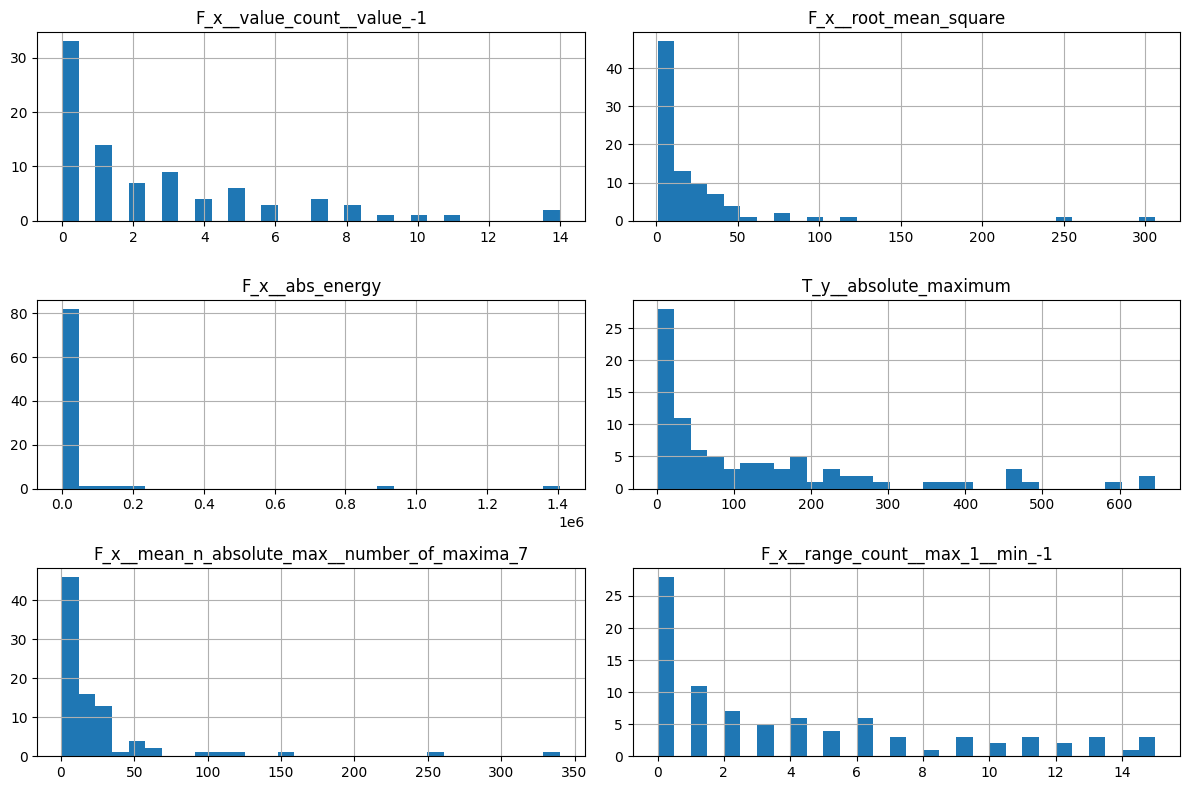

In [12]:
import matplotlib.pyplot as plt

# 너무 많으면 처음 몇 개만 골라서
cols = features_filtered.columns[:6]

features_filtered[cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

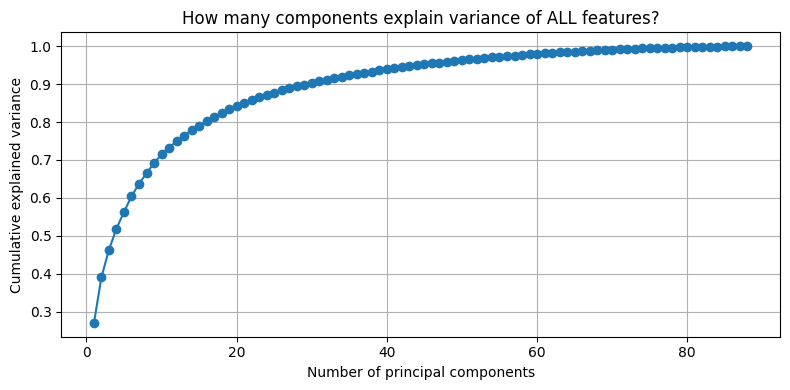

In [13]:
# 1. 전체 구조 요약: PCA 기준으로 다 쓰기
# (1) 스케일링 + 주성분 설명력 보기

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = features_filtered.copy()

# 1) 스케일링 (각 feature 평균 0, 분산 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) PCA로 전체 분산 설명력 확인
pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("How many components explain variance of ALL features?")
plt.grid(True)
plt.tight_layout()
plt.show()


x축: 주성분 개수(PC 개수), y축: 그때까지의 누적 설명 분산 비율
-

PC 1개 → 전체 분산의 약 26% /
PC 10개 → 약 70% 정도 /
PC 20개 → 약 85% /
PC 30개 → 약 90% /
PC 40개 → 약 95% / PC 60개 → 약 98% 이상 /
80~90개쯤 되면 거의 100%에 수렴

~~~~ 671개 feature 전부를 쓰지 않아도, 대략 30~40개의 주성분만으로 원래 정보의 90~95%를 유지

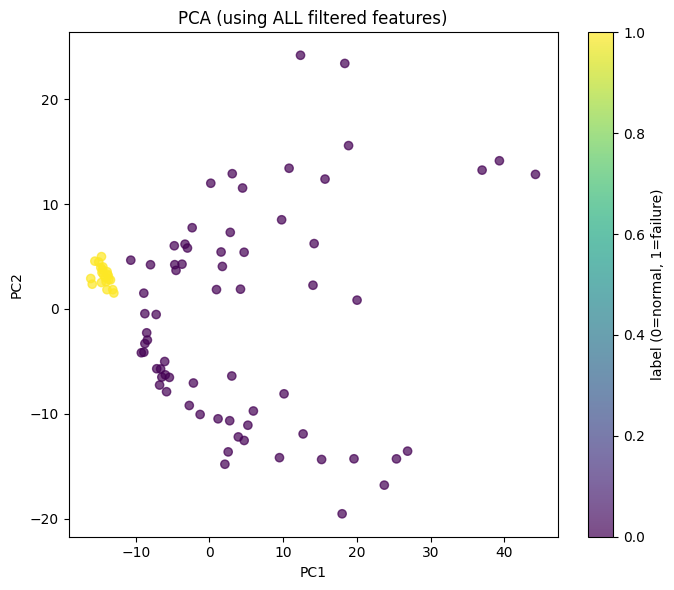

In [14]:
# (2) PCA 2D에 투영해서 라벨까지 함께 보기
# y의 인덱스가 X와 맞다고 가정
# 671개 전체 feature를 다 사용해서
#“고장/정상 run이 어느 정도 분리되는지” 시각적으로 확인 가능

y_aligned = y.loc[X.index]

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1],
                      c=y_aligned, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (using ALL filtered features)")
plt.colorbar(scatter, label="label (0=normal, 1=failure)")
plt.tight_layout()
plt.show()


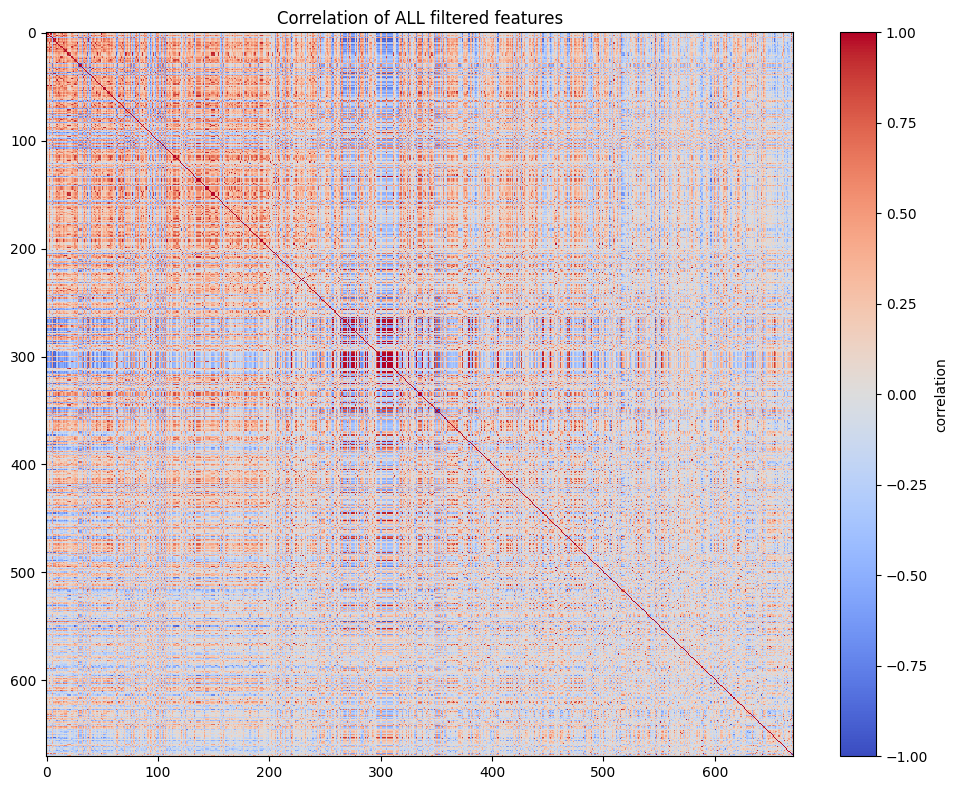

In [15]:
#
# 2. 전체 feature 사이 관계: 상관계수 heatmap
# 671×671라 좀 크긴 하지만, 전체 feature의 상관 구조를 보기. imshow

import matplotlib.pyplot as plt

corr = X.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1,
           aspect='auto', interpolation='nearest')
plt.colorbar(label='correlation')
plt.title("Correlation of ALL filtered features")
plt.tight_layout()
plt.show()


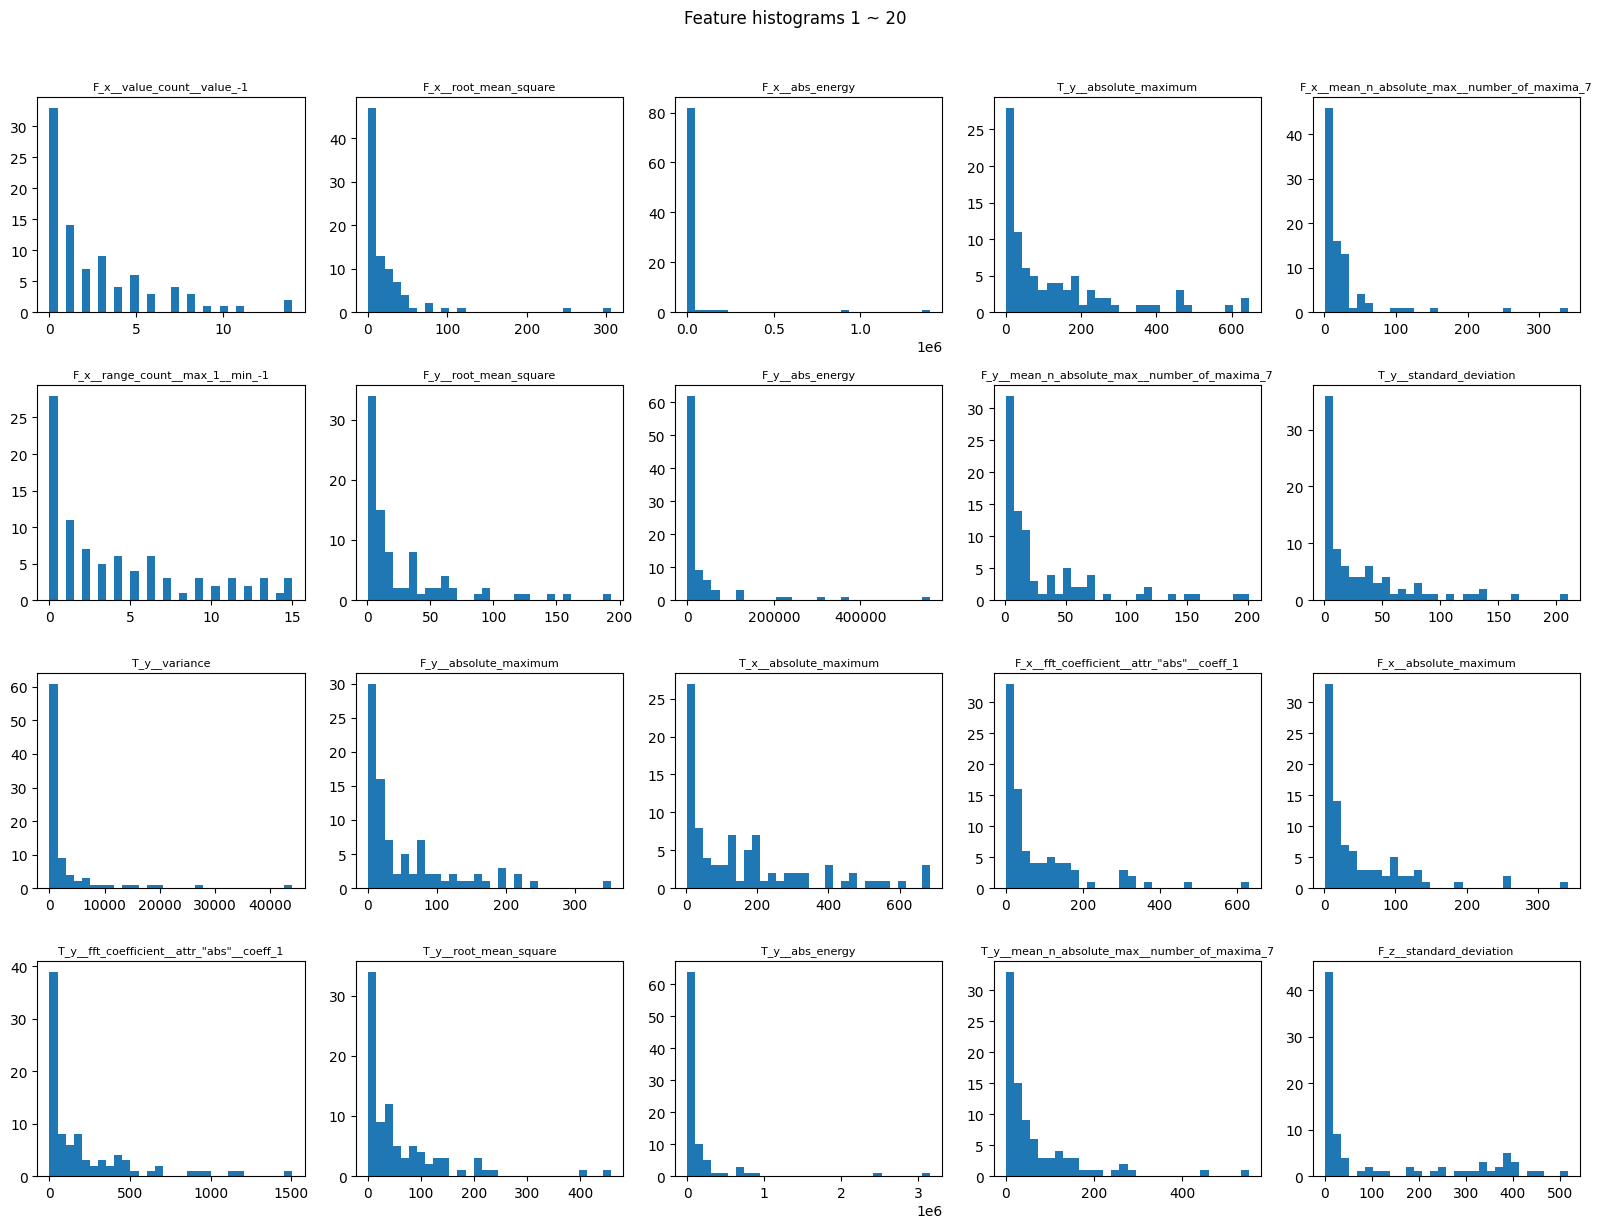

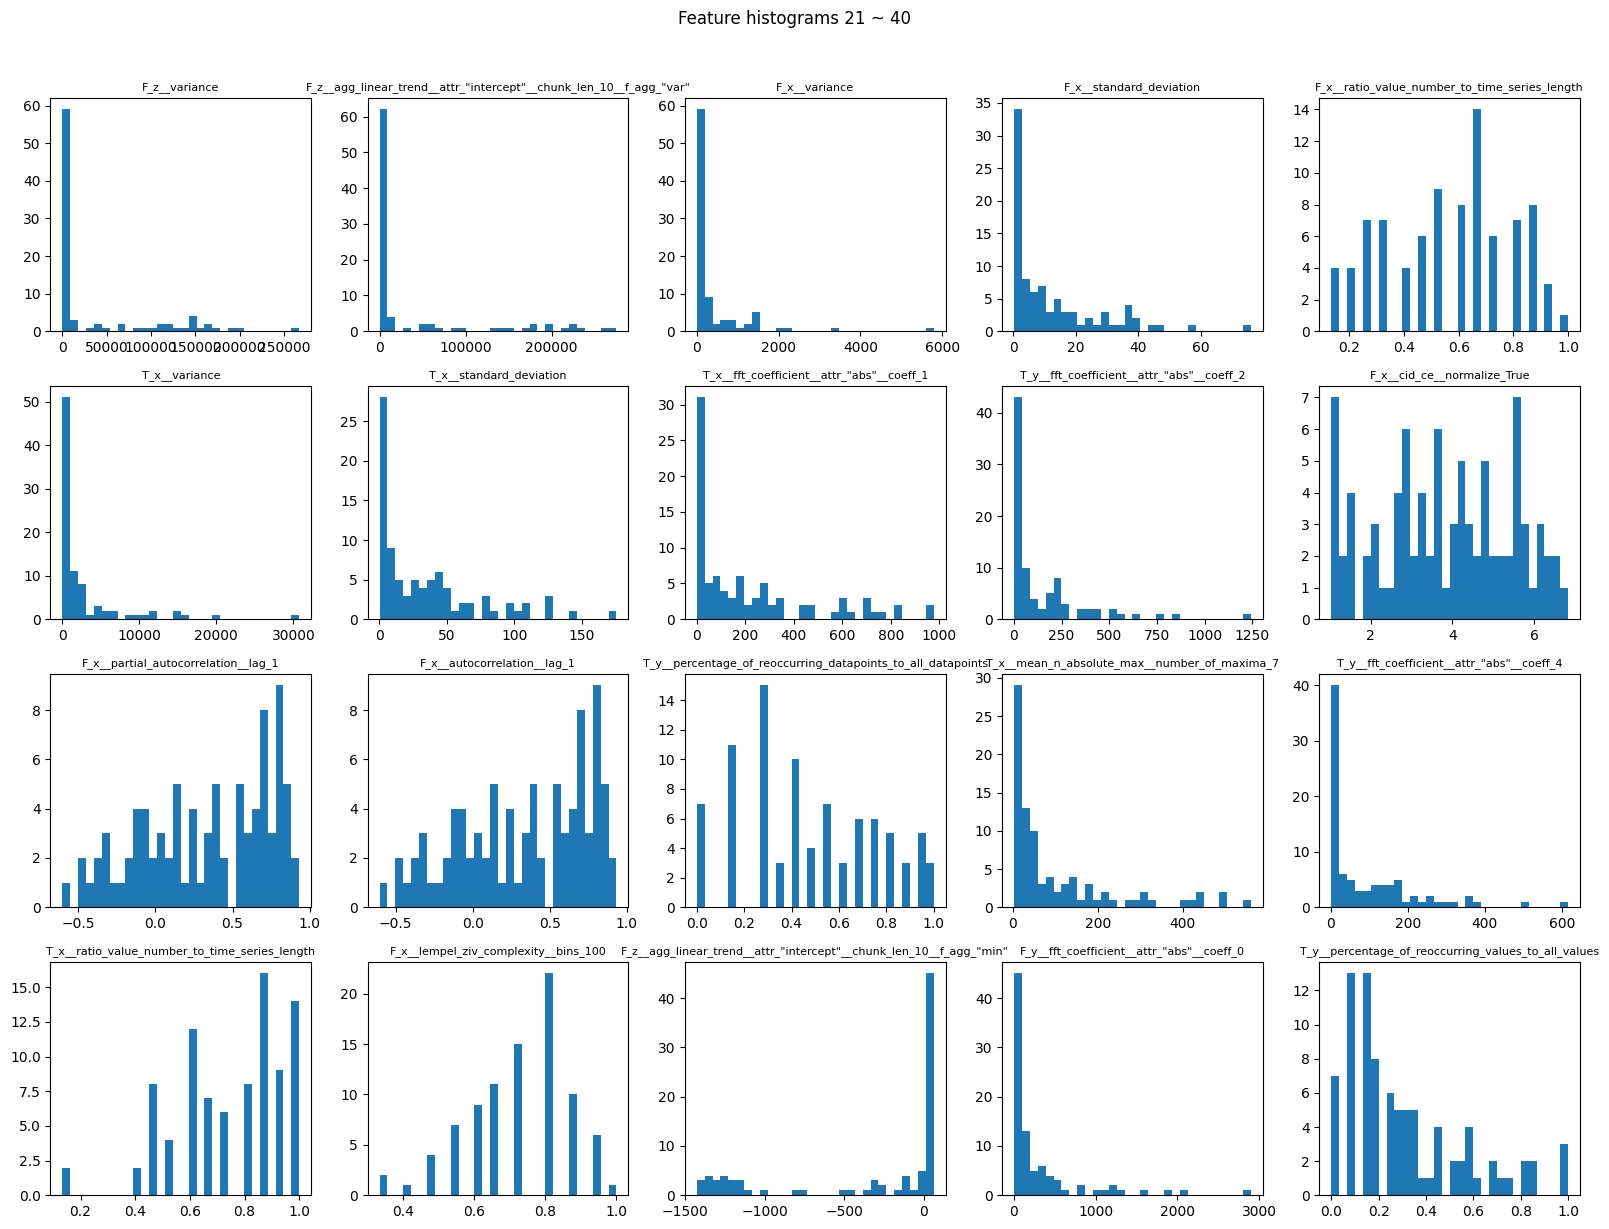

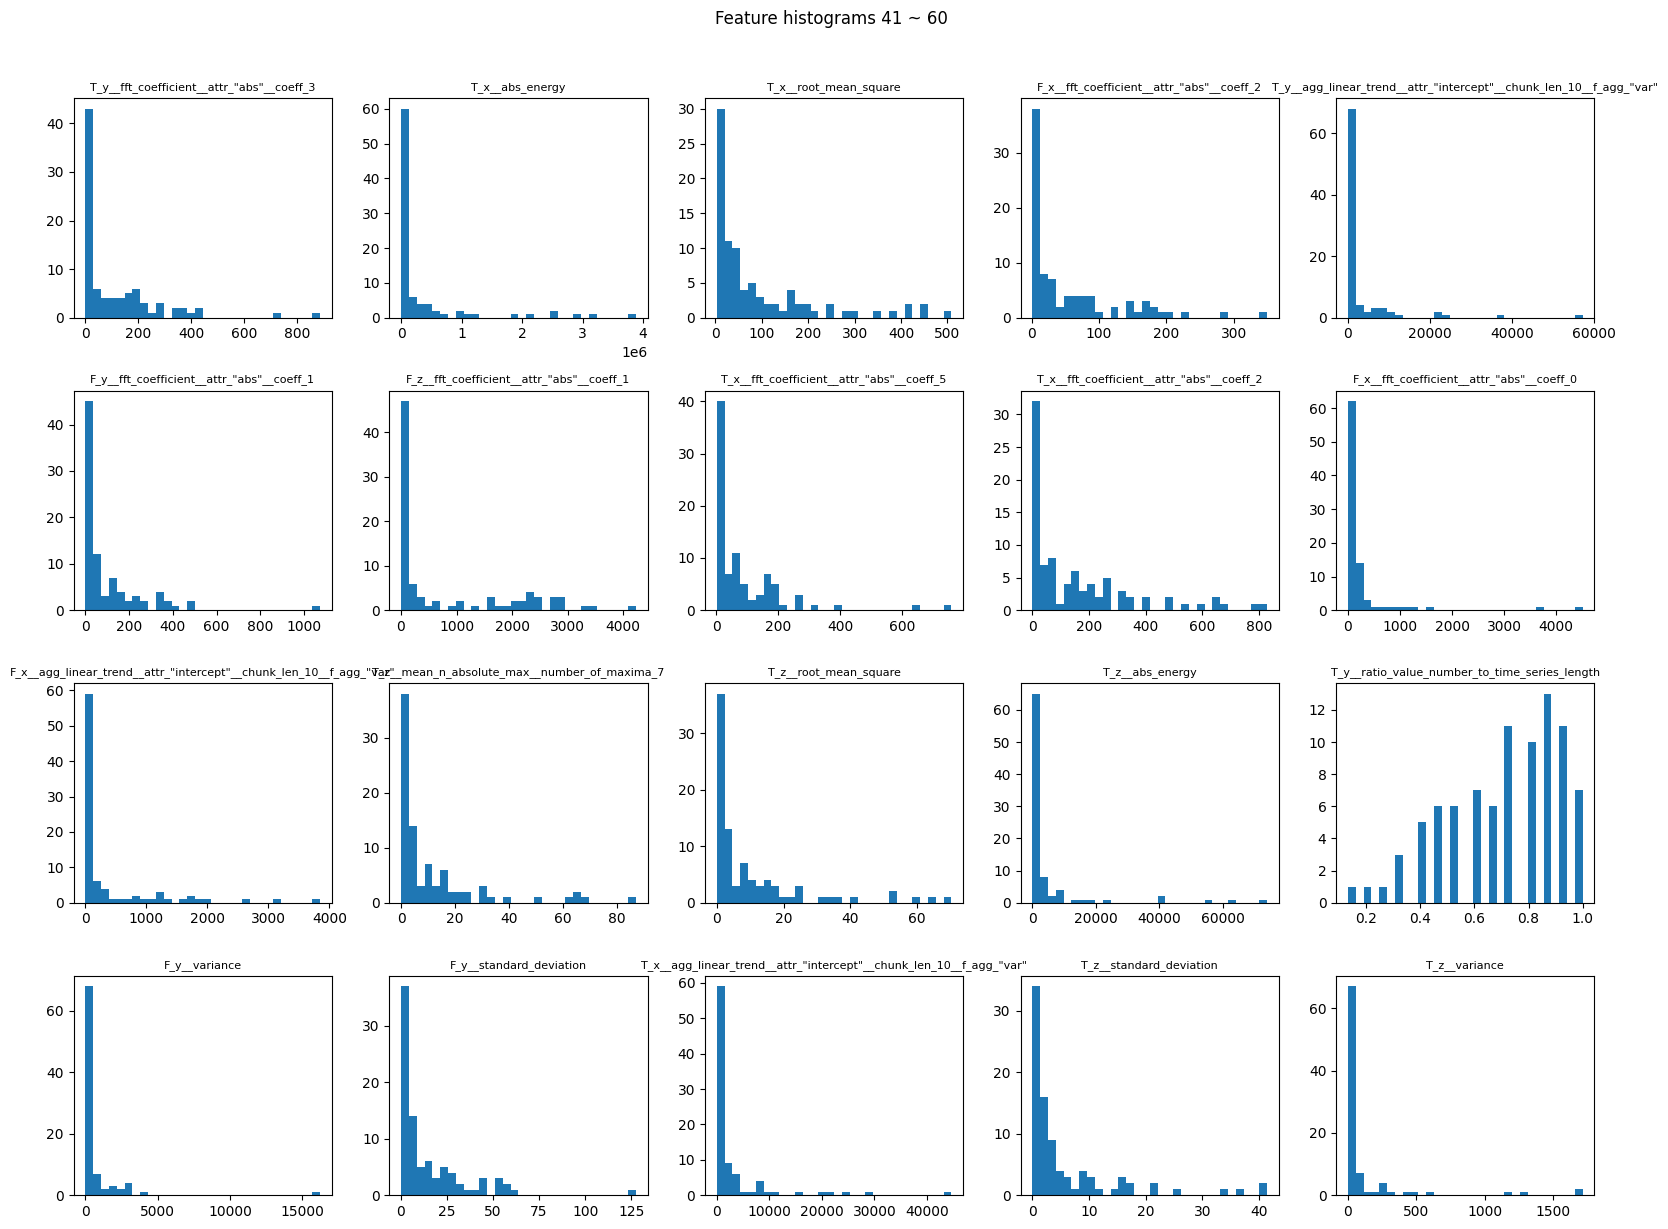

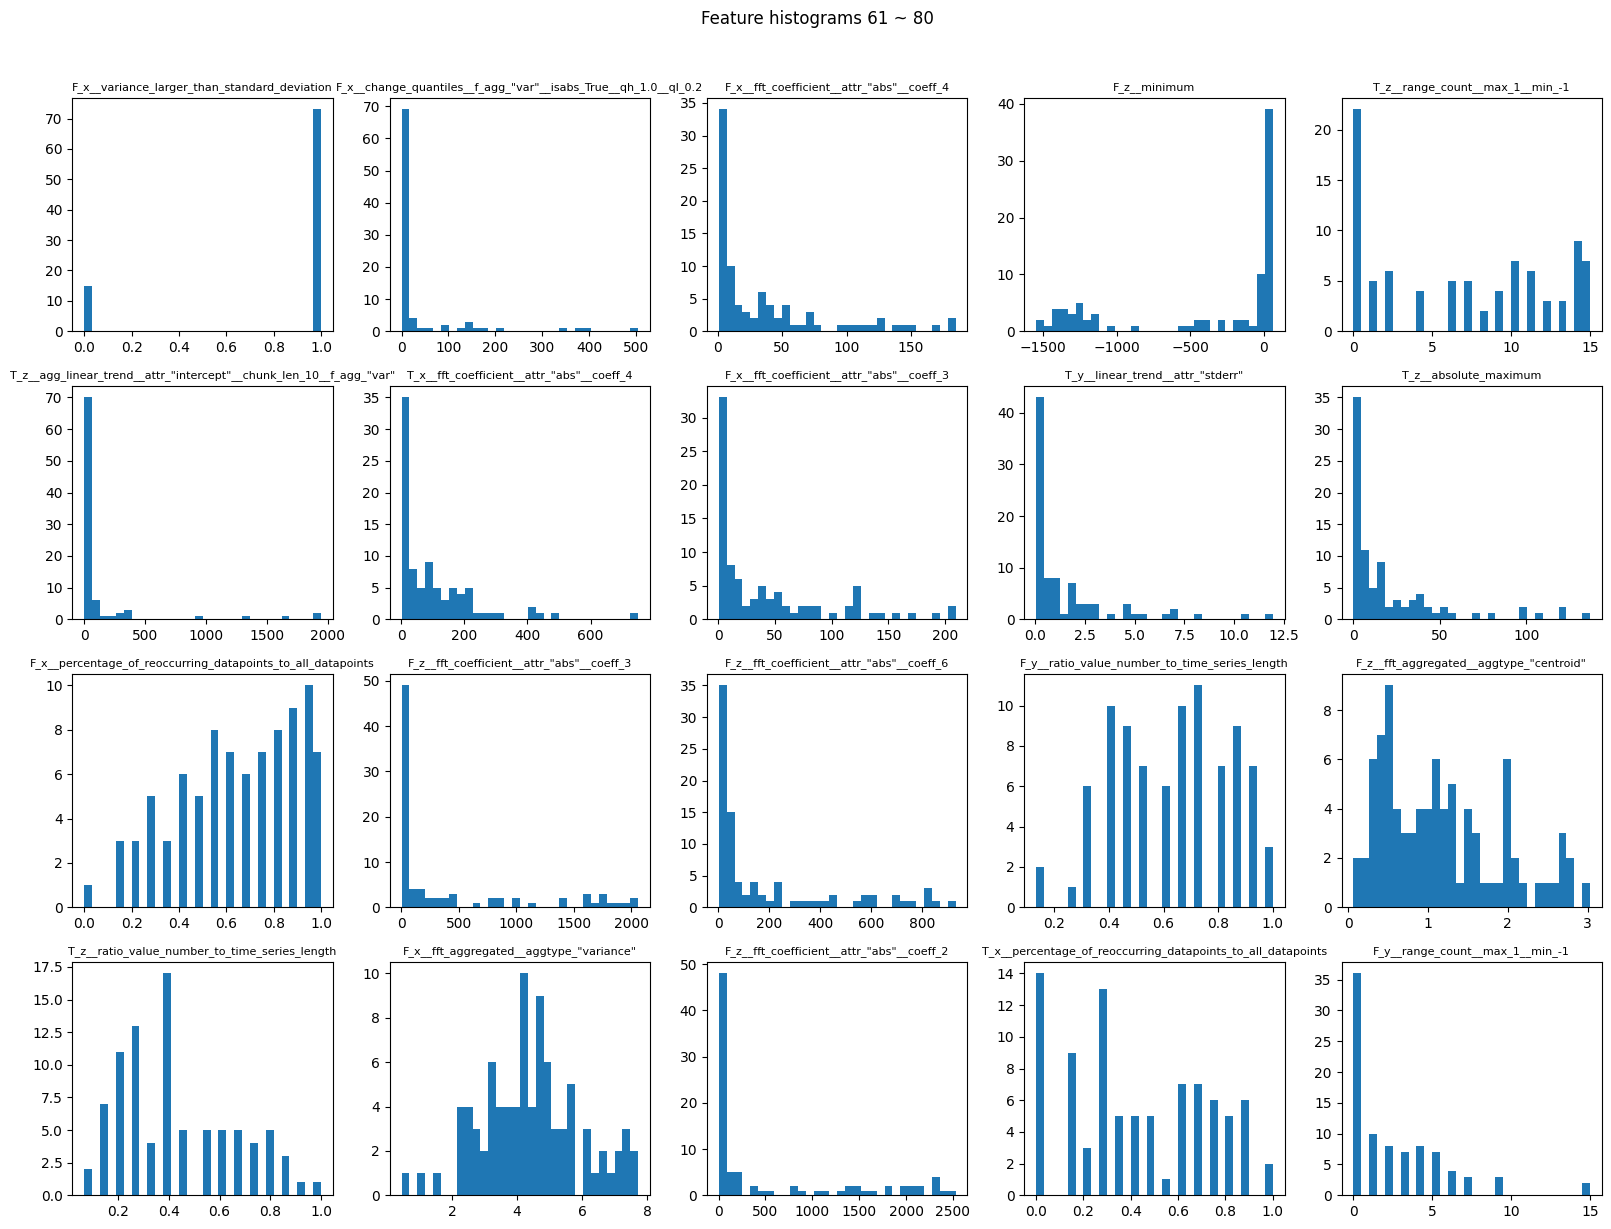

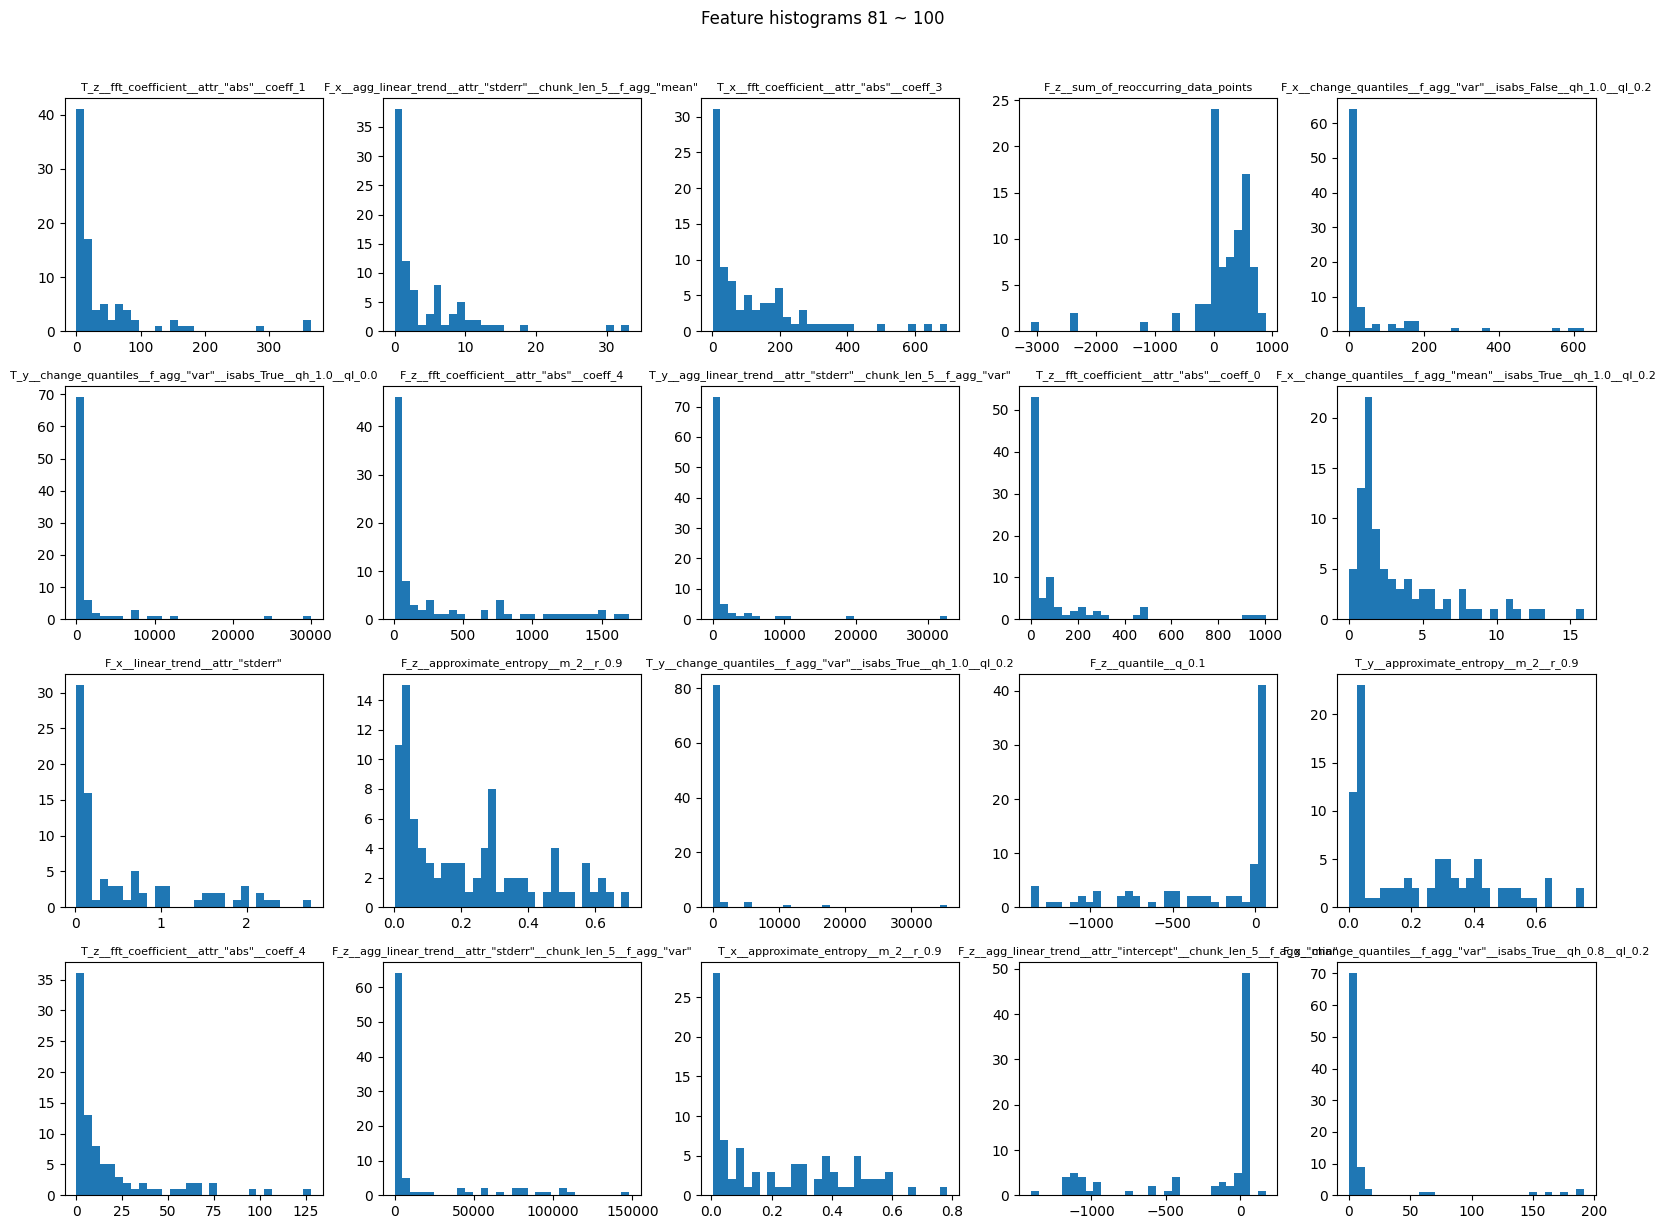

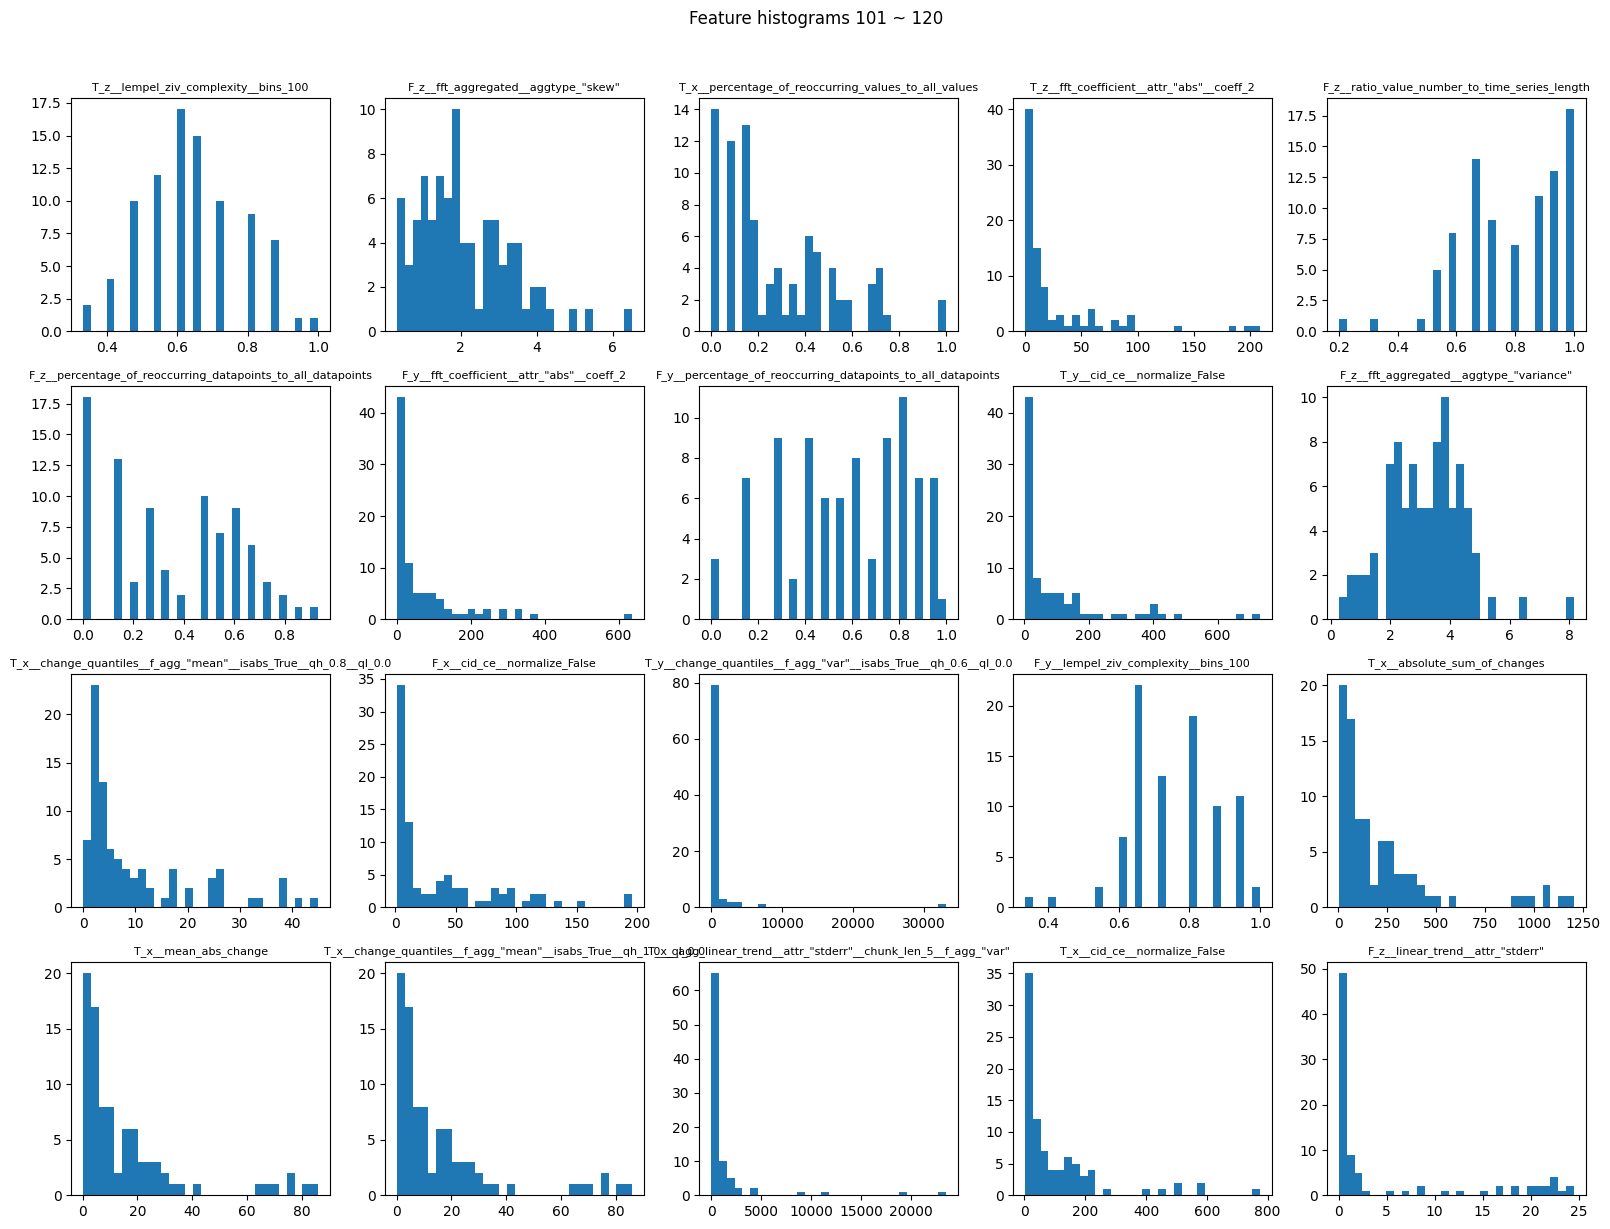

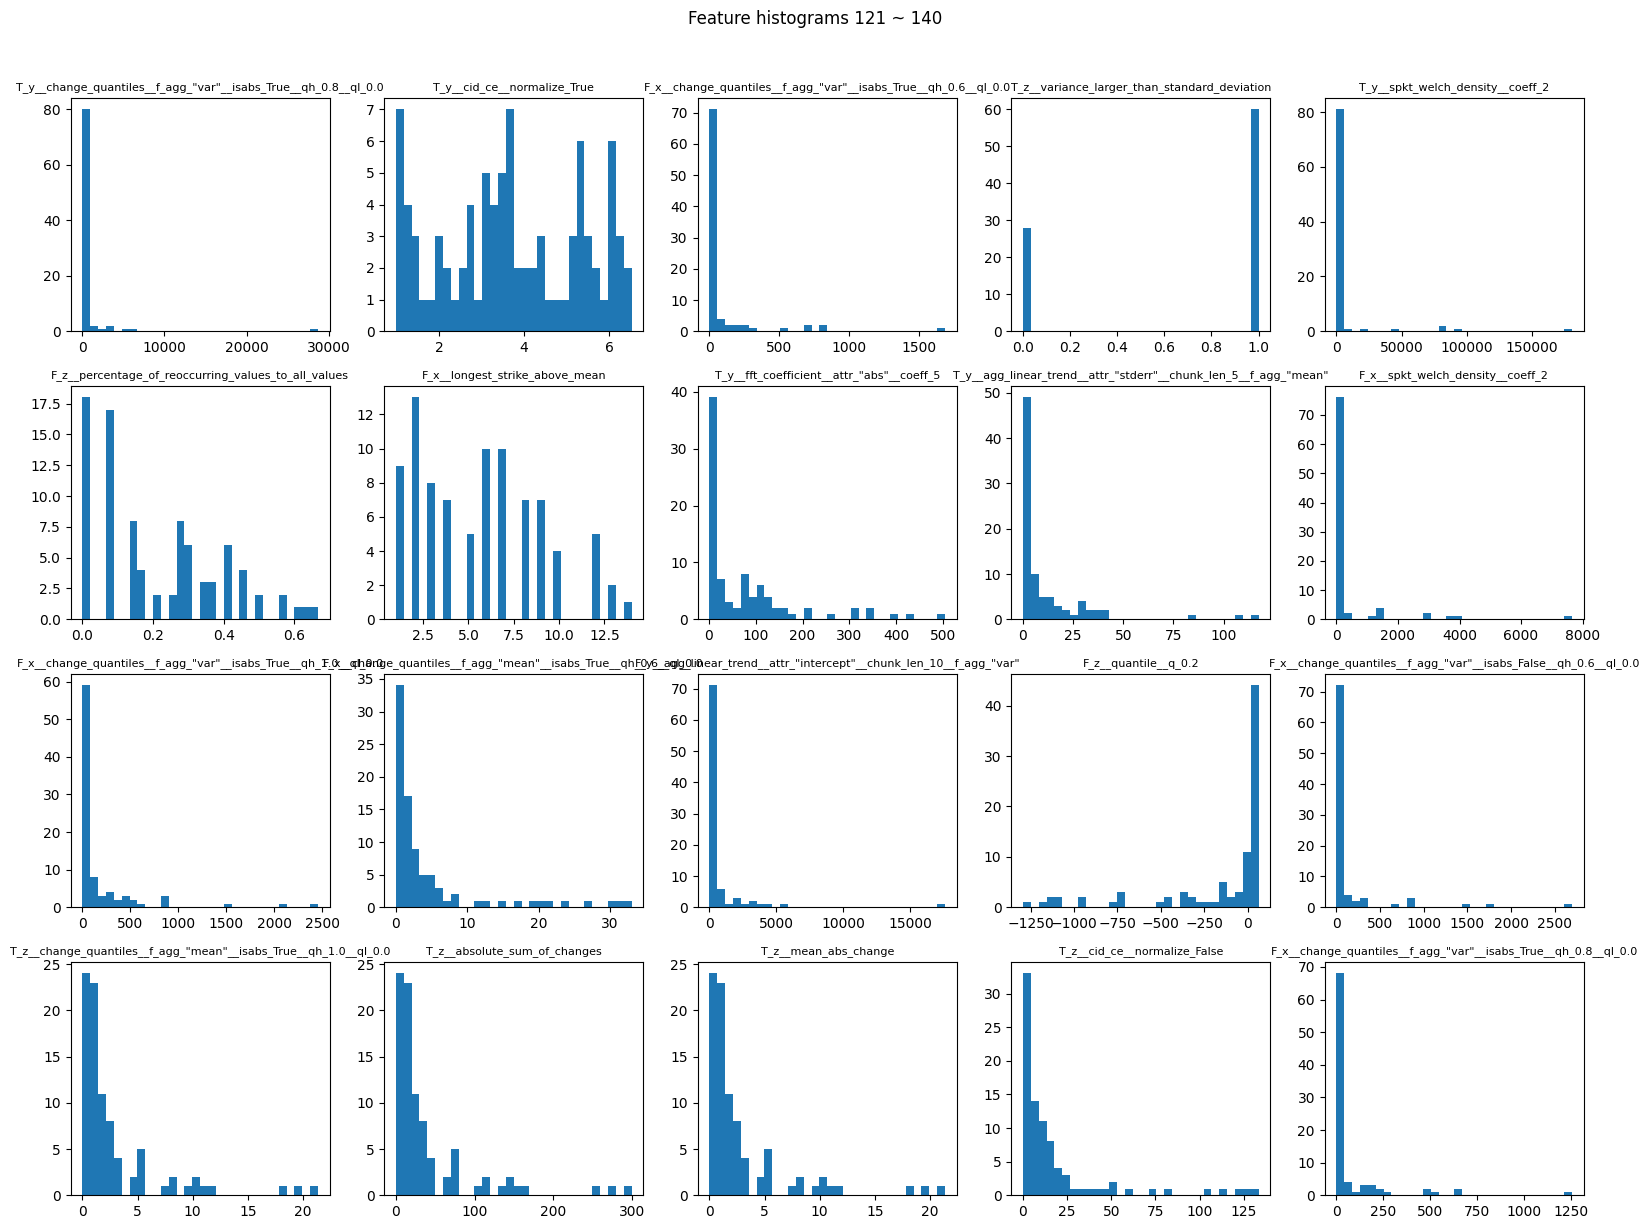

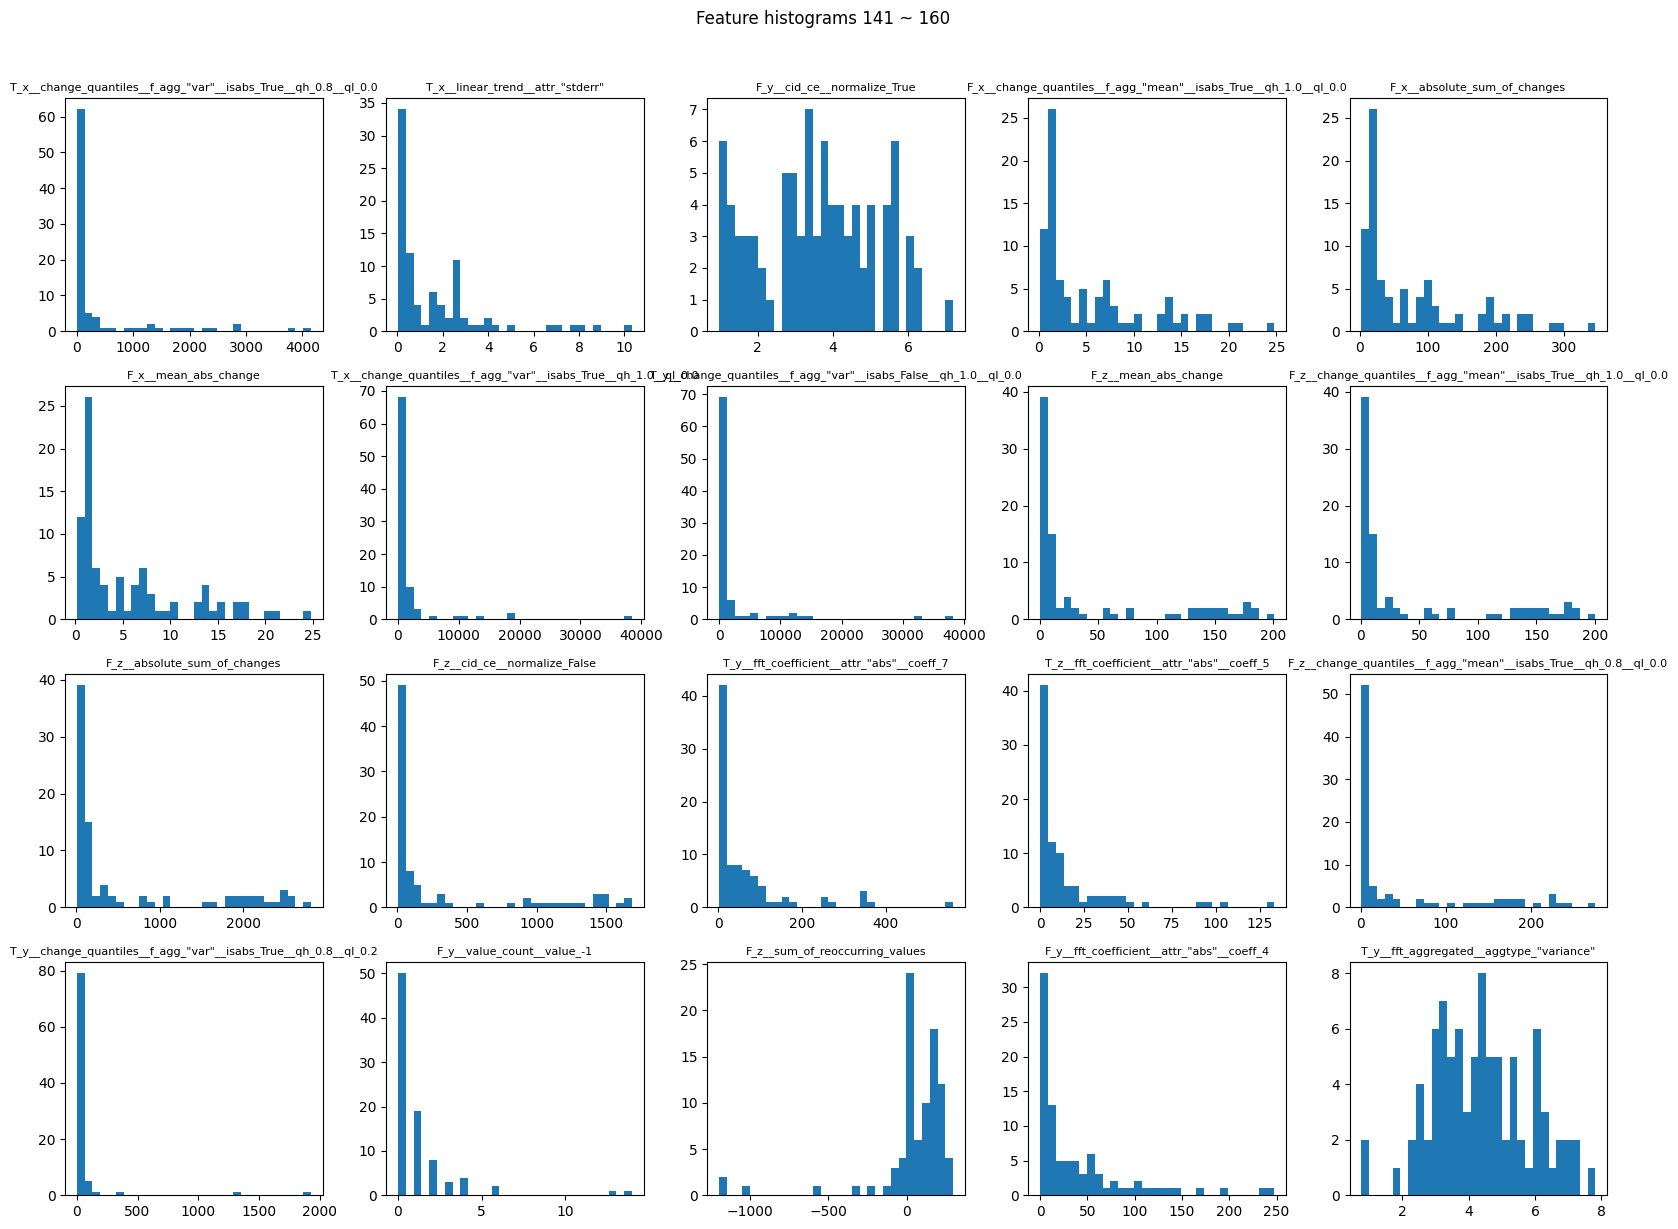

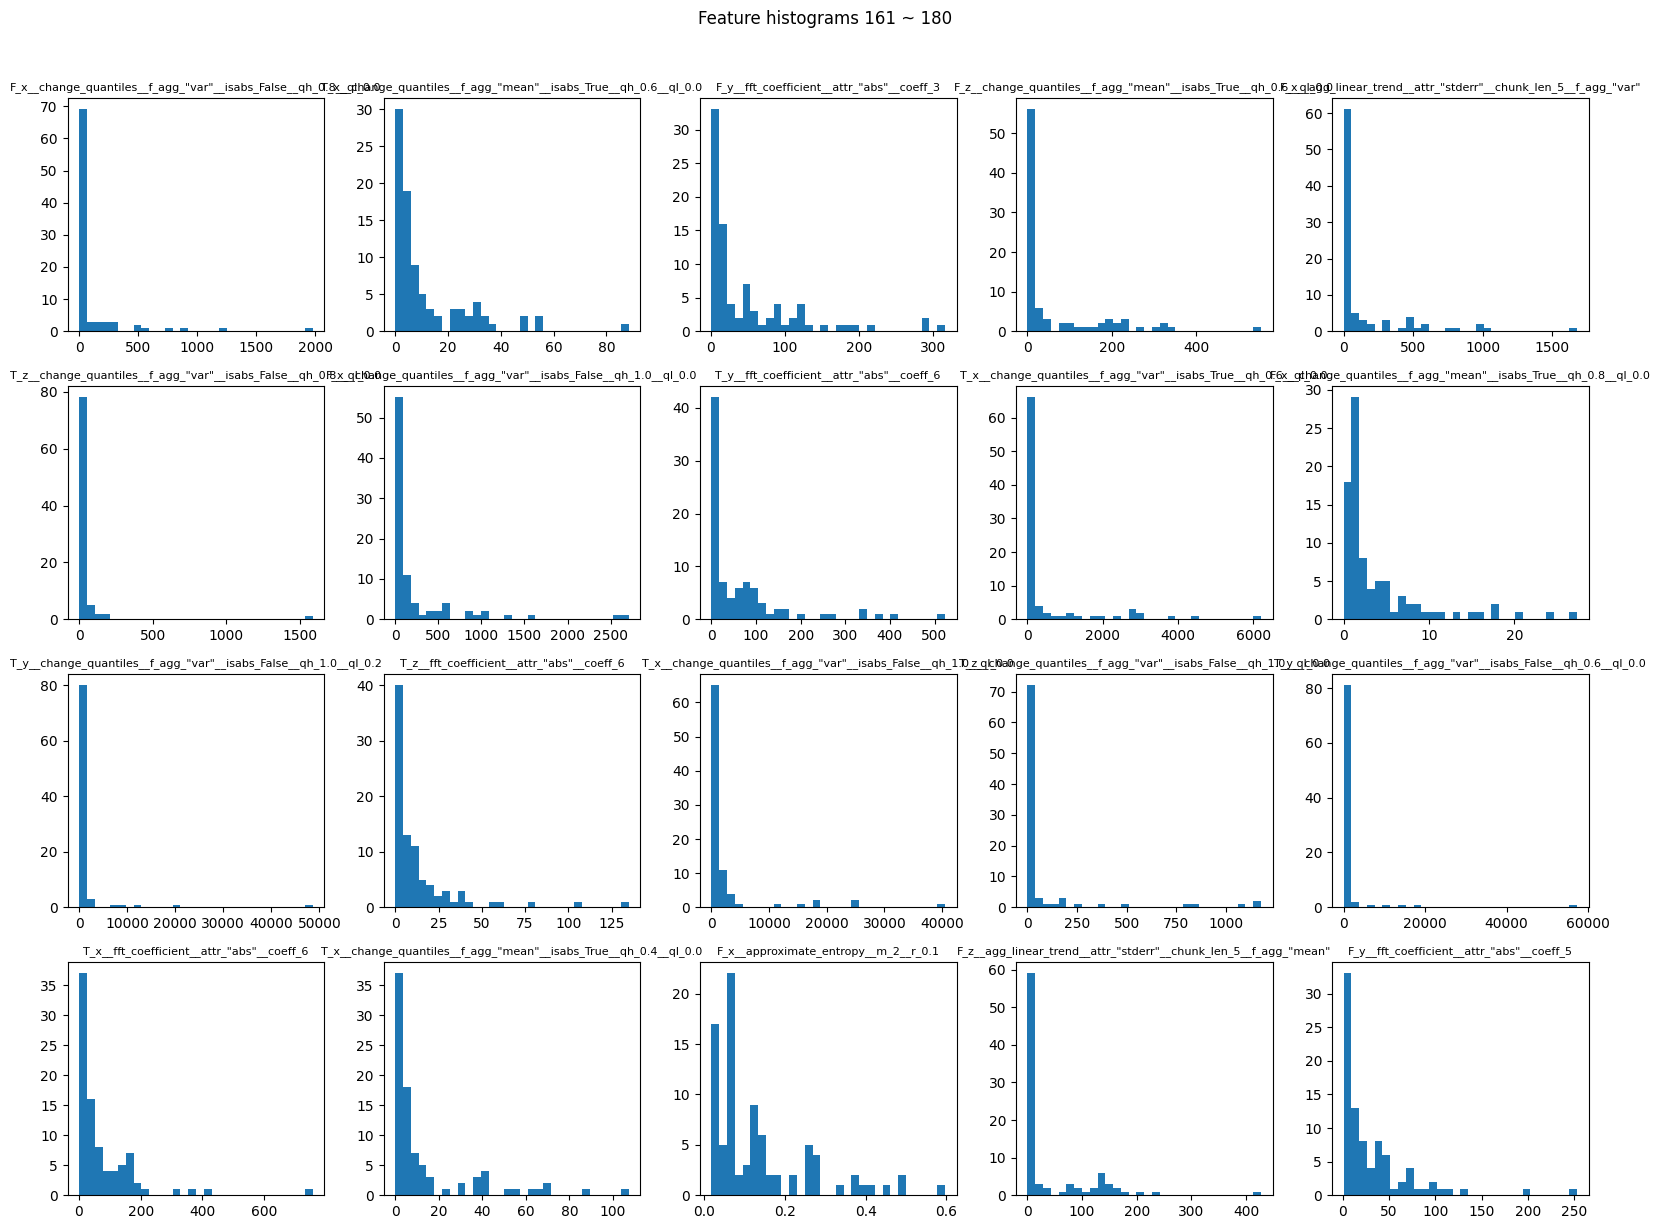

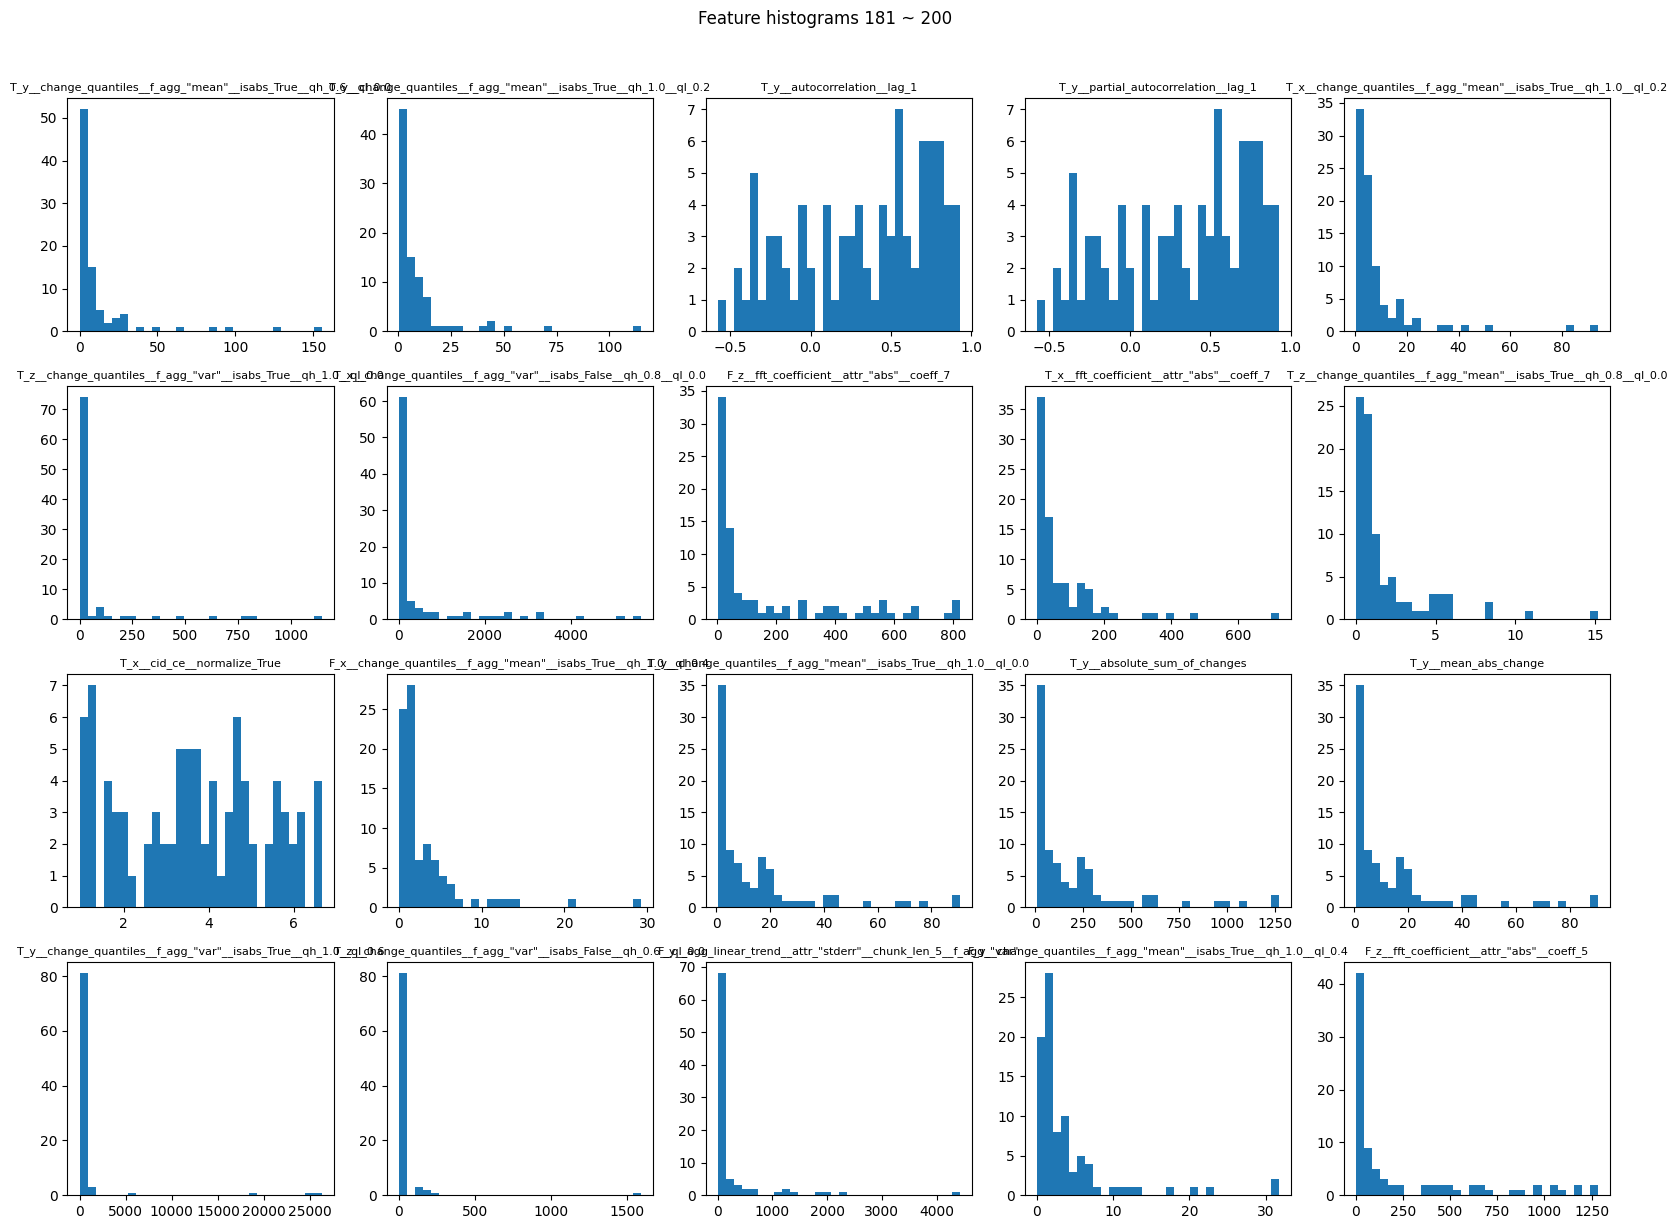

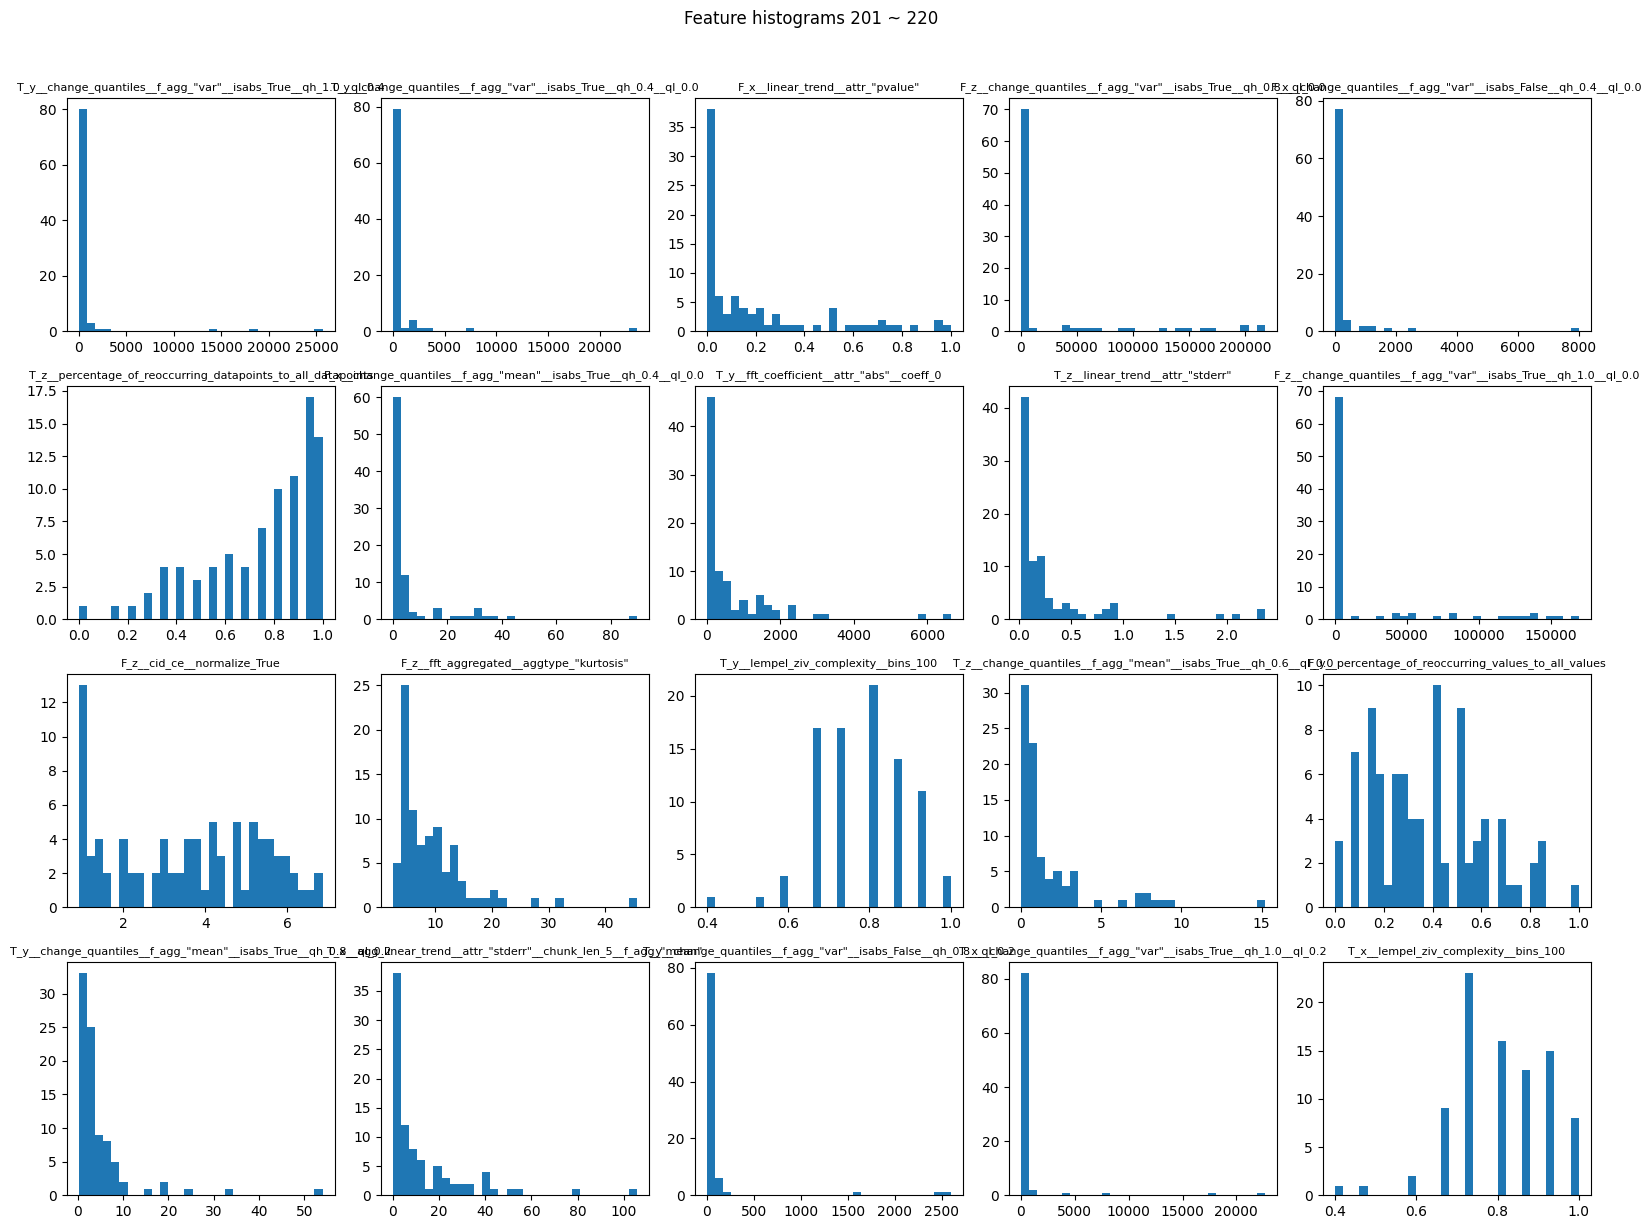

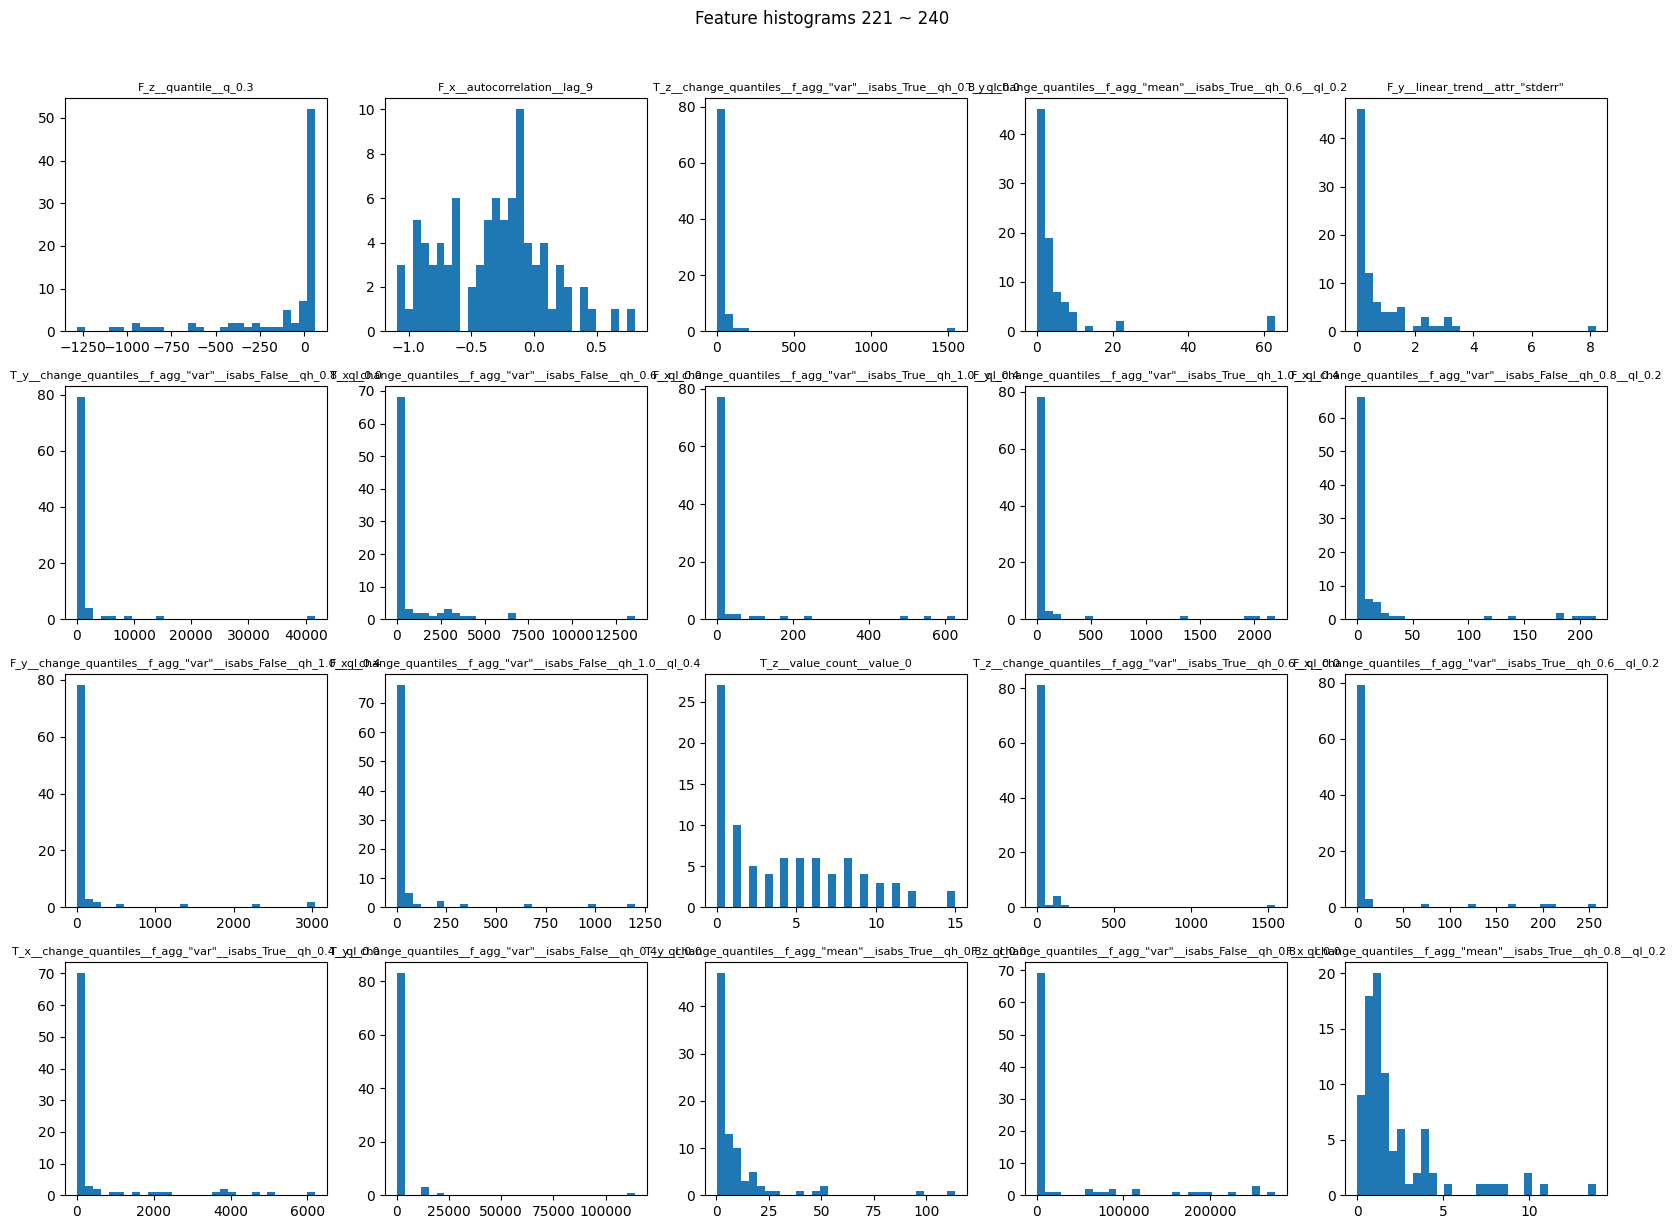

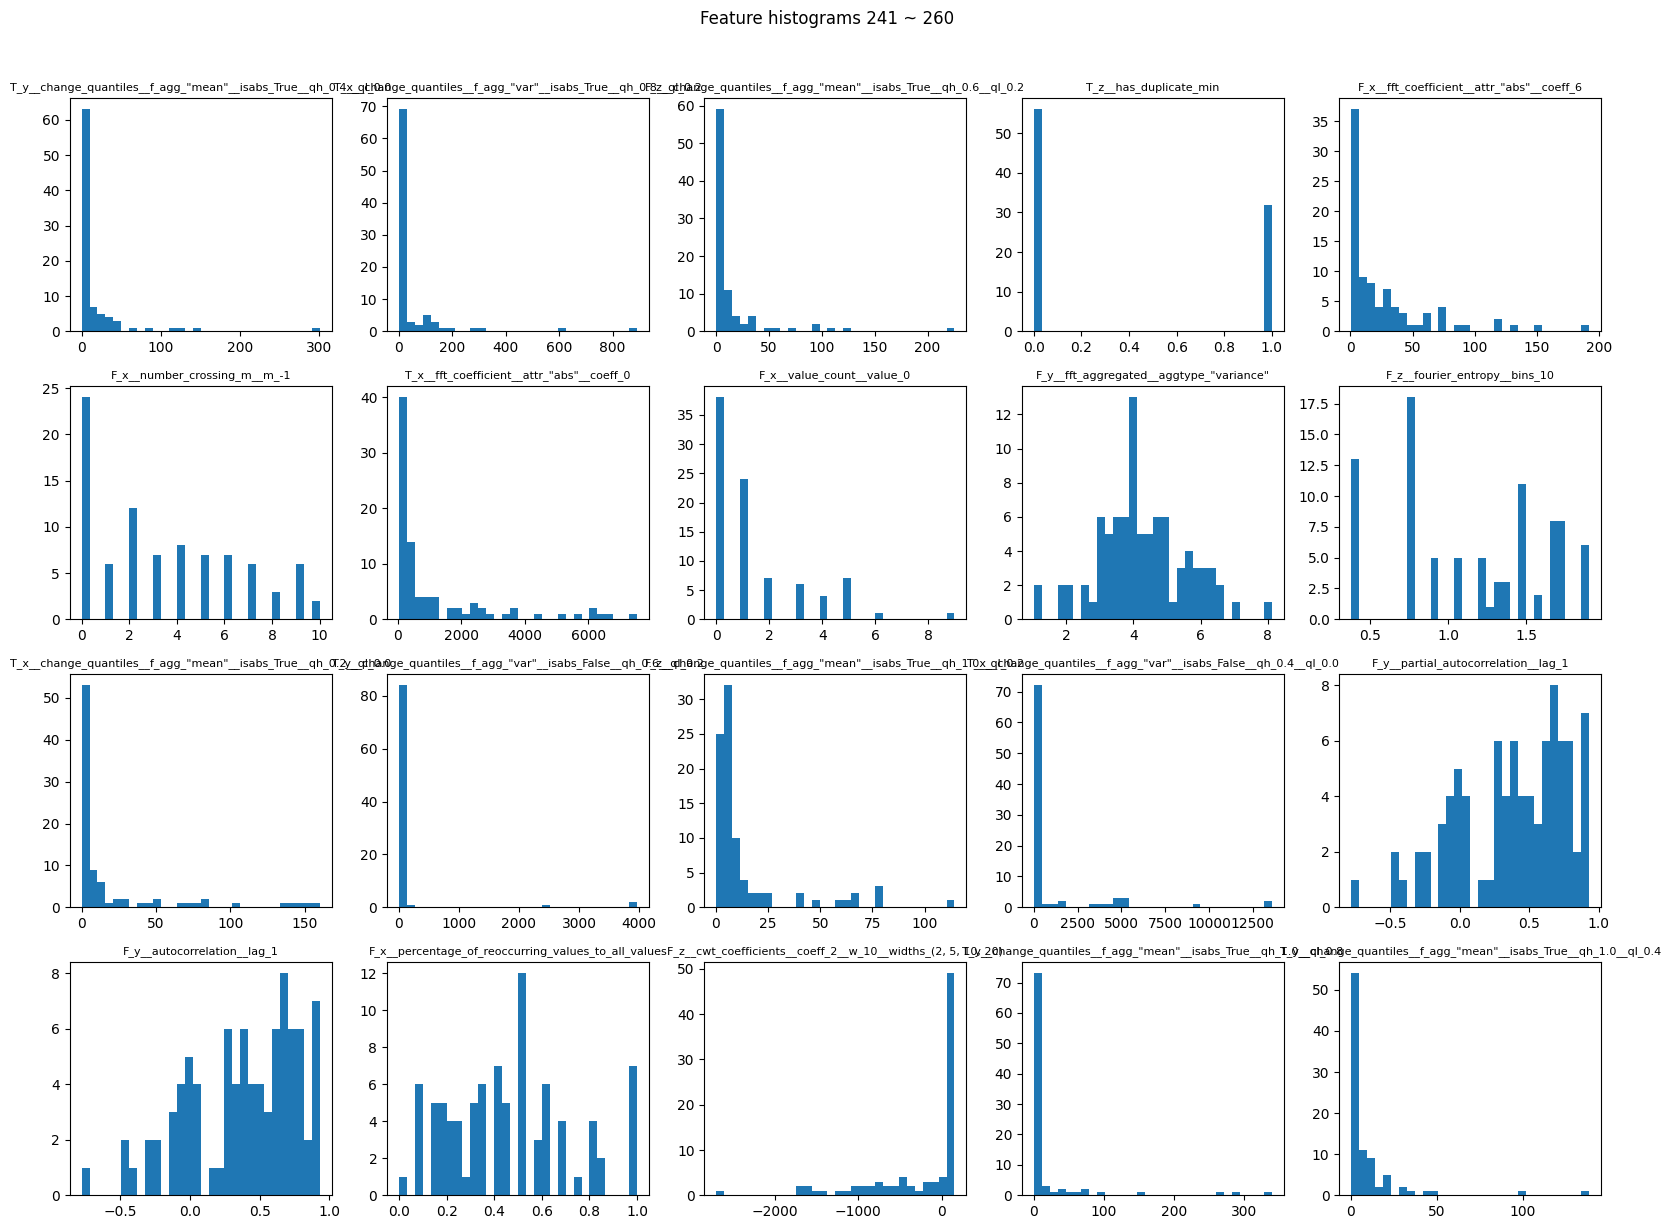

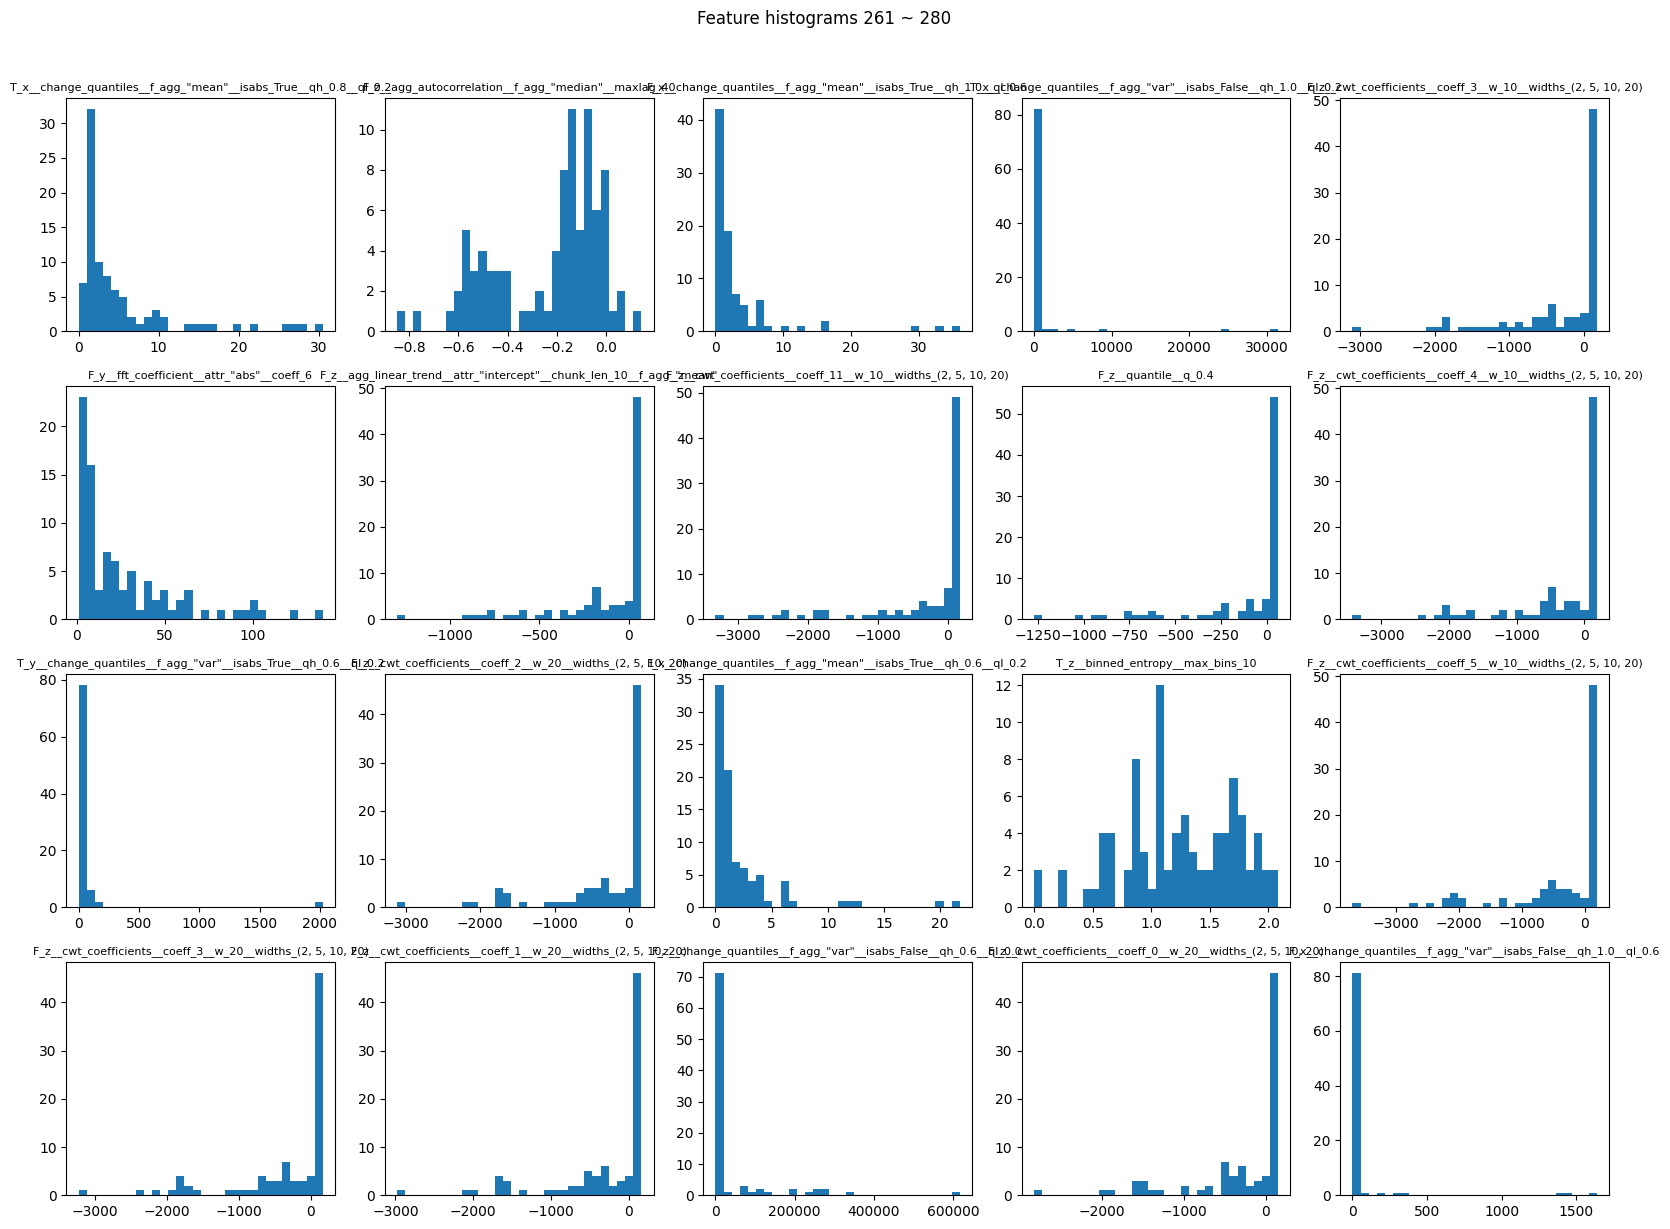

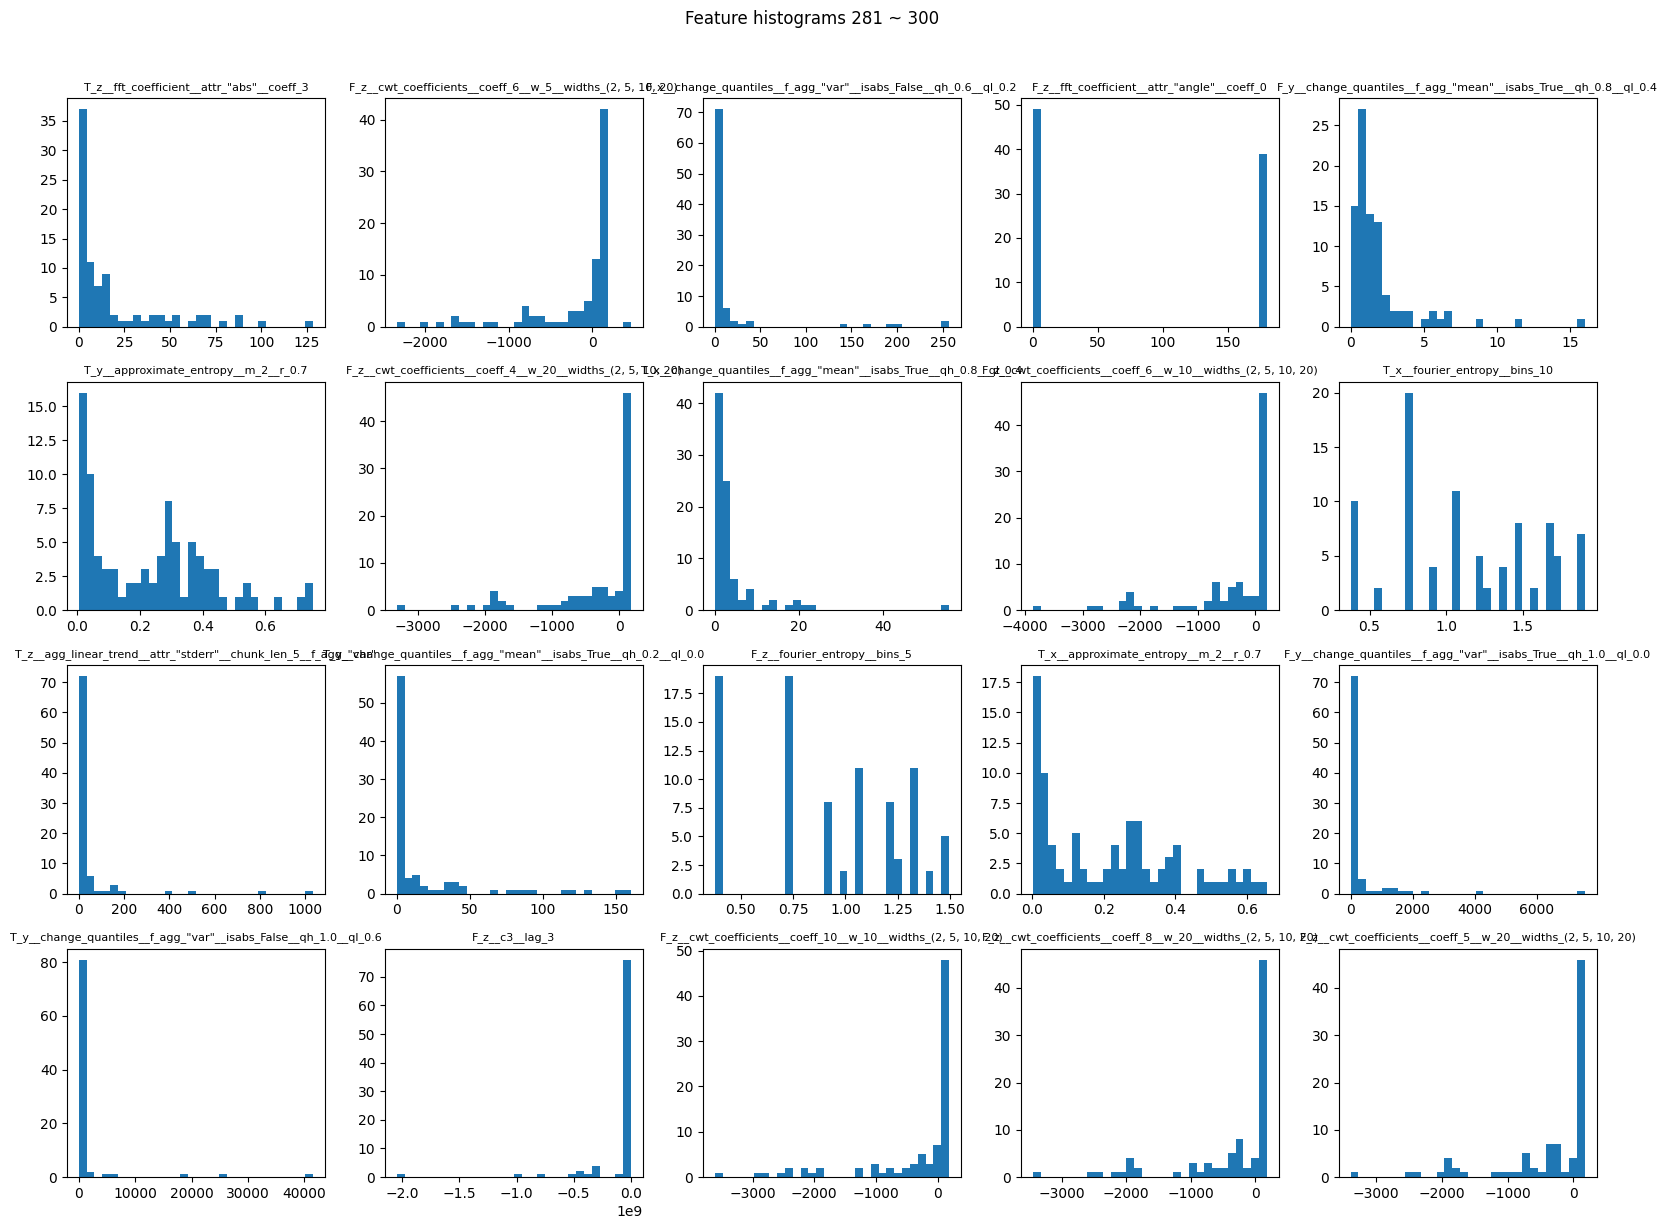

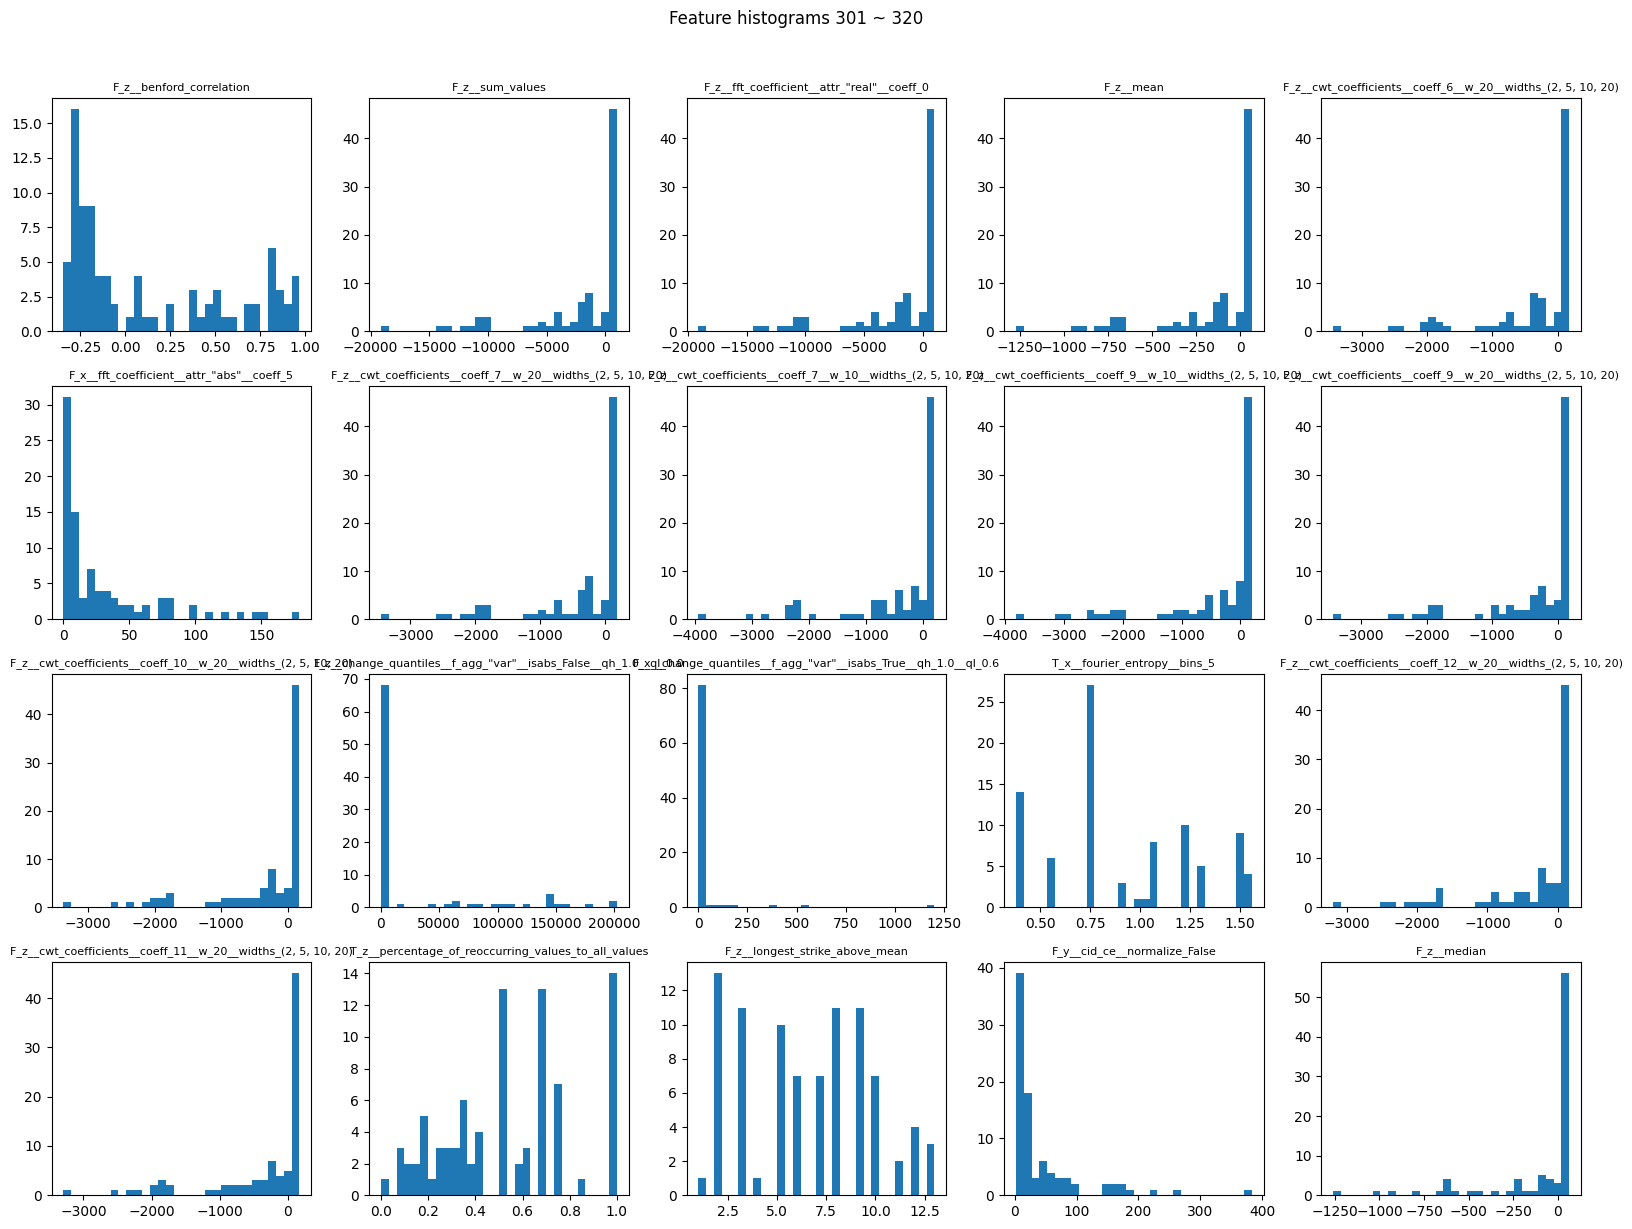

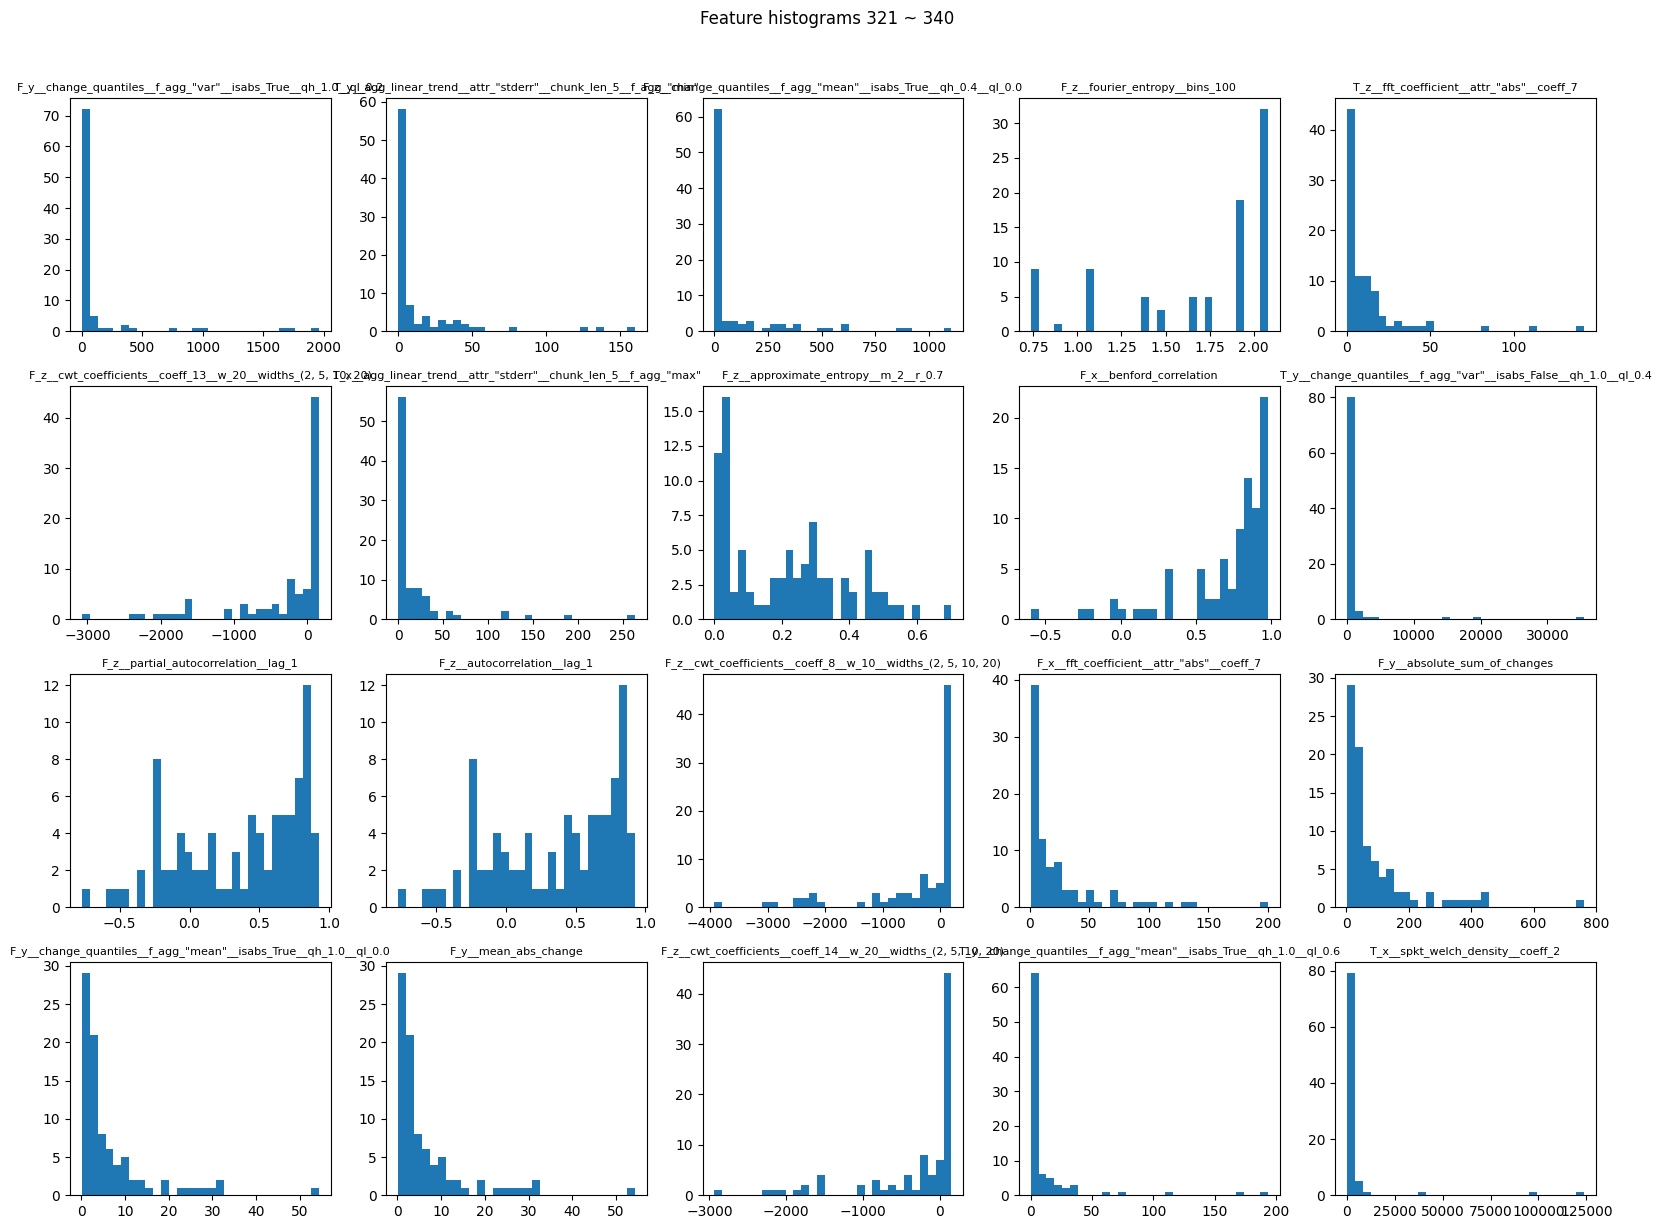

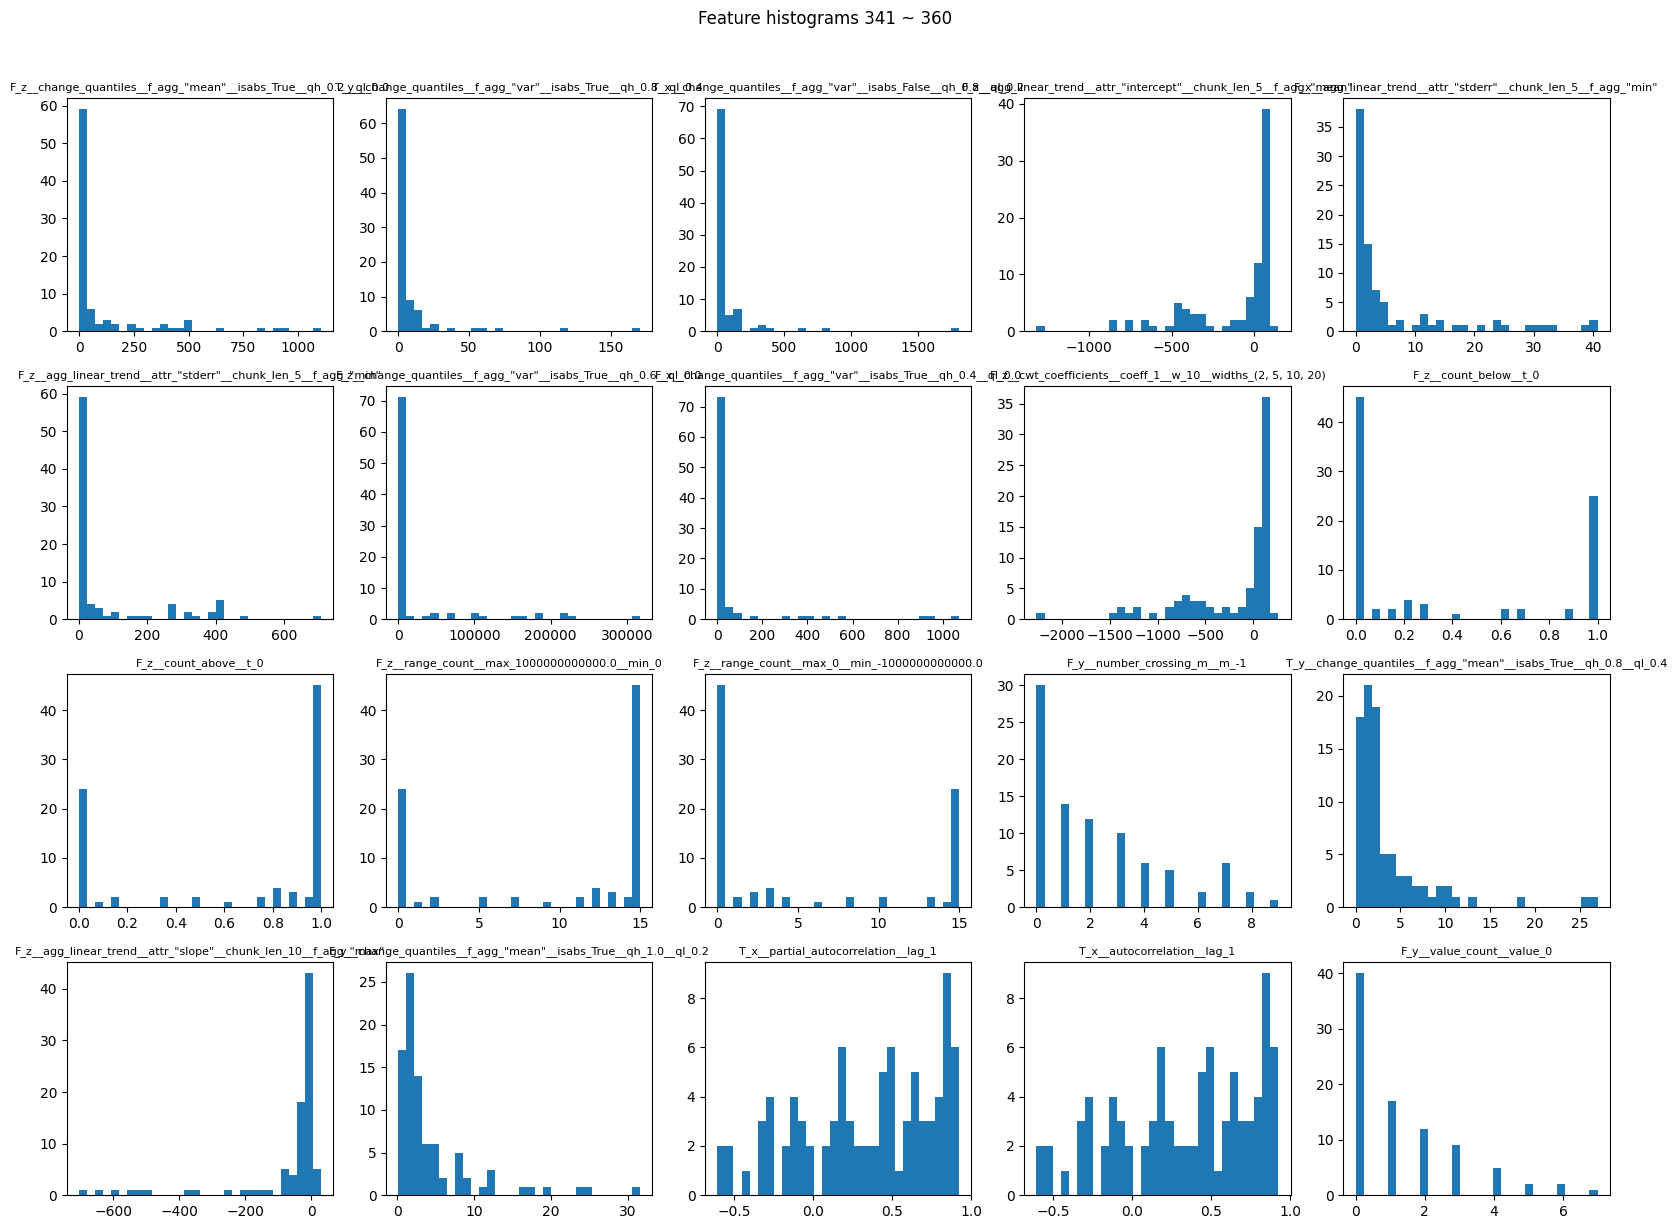

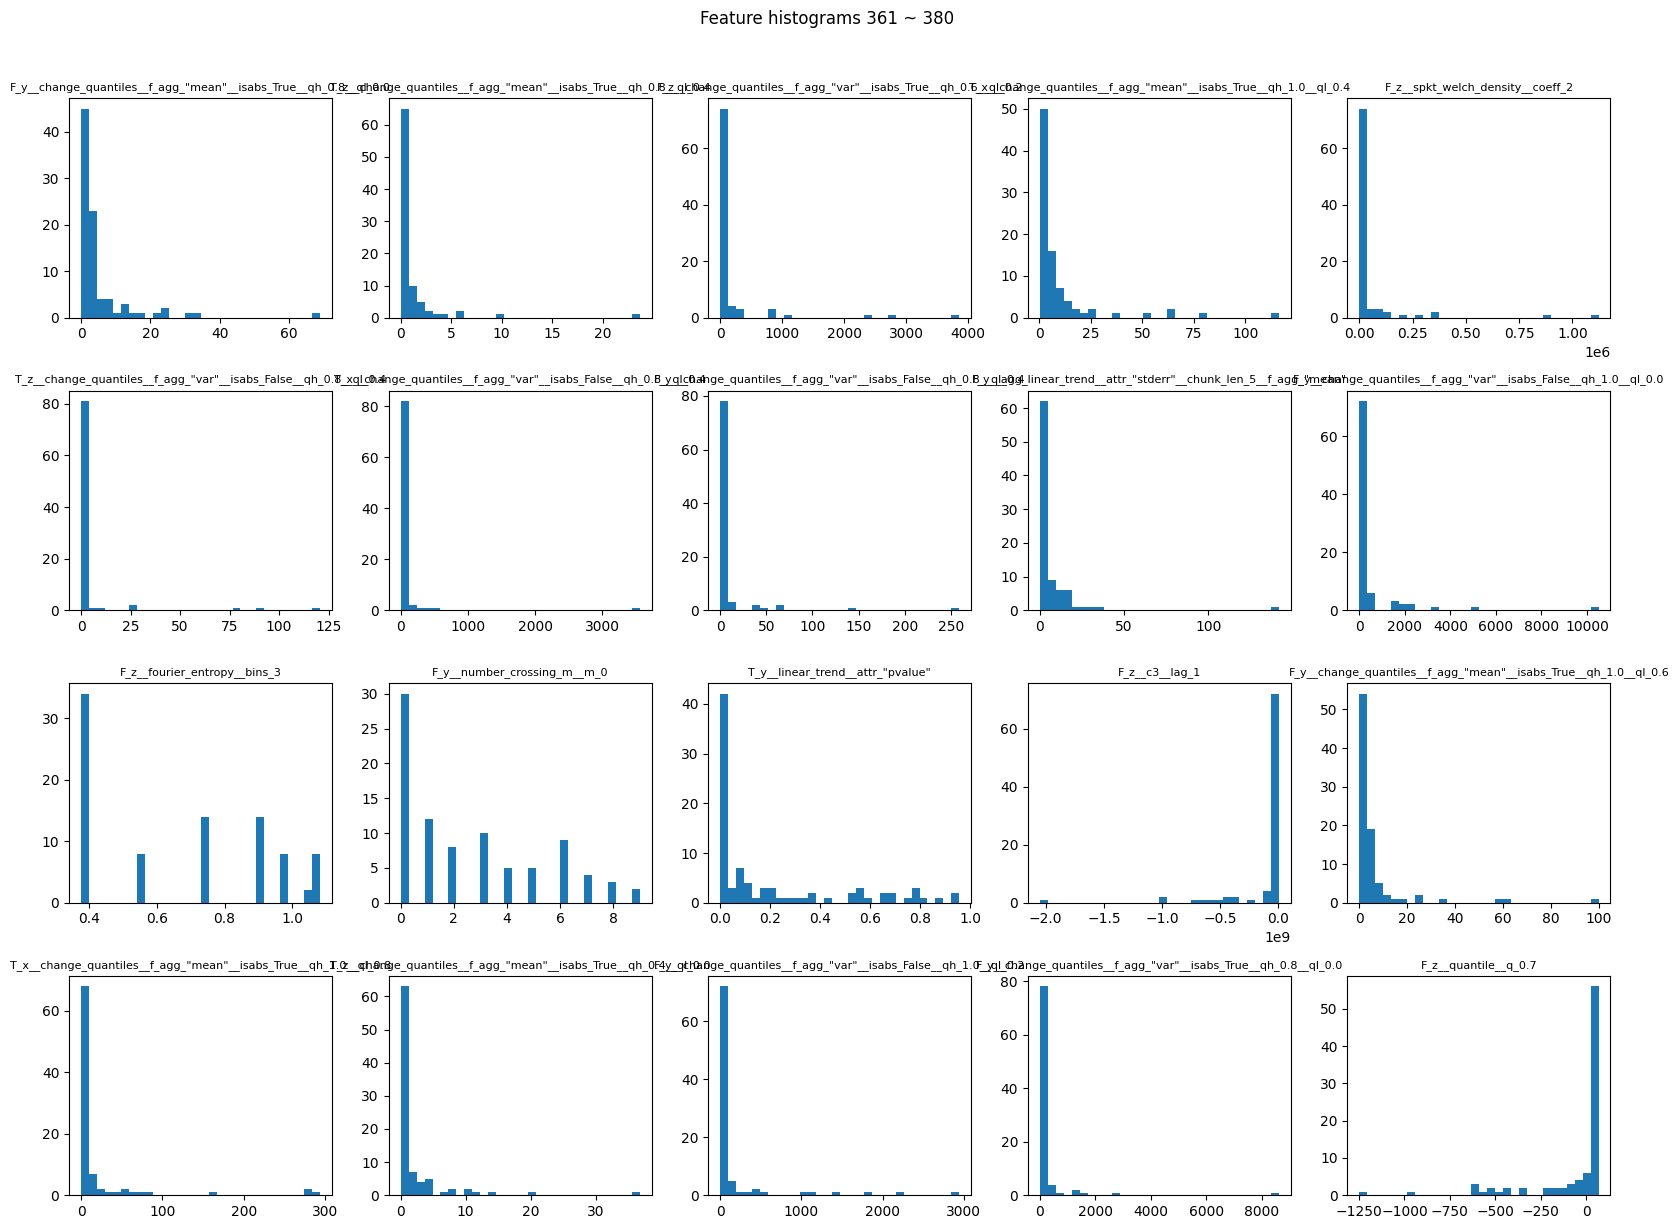

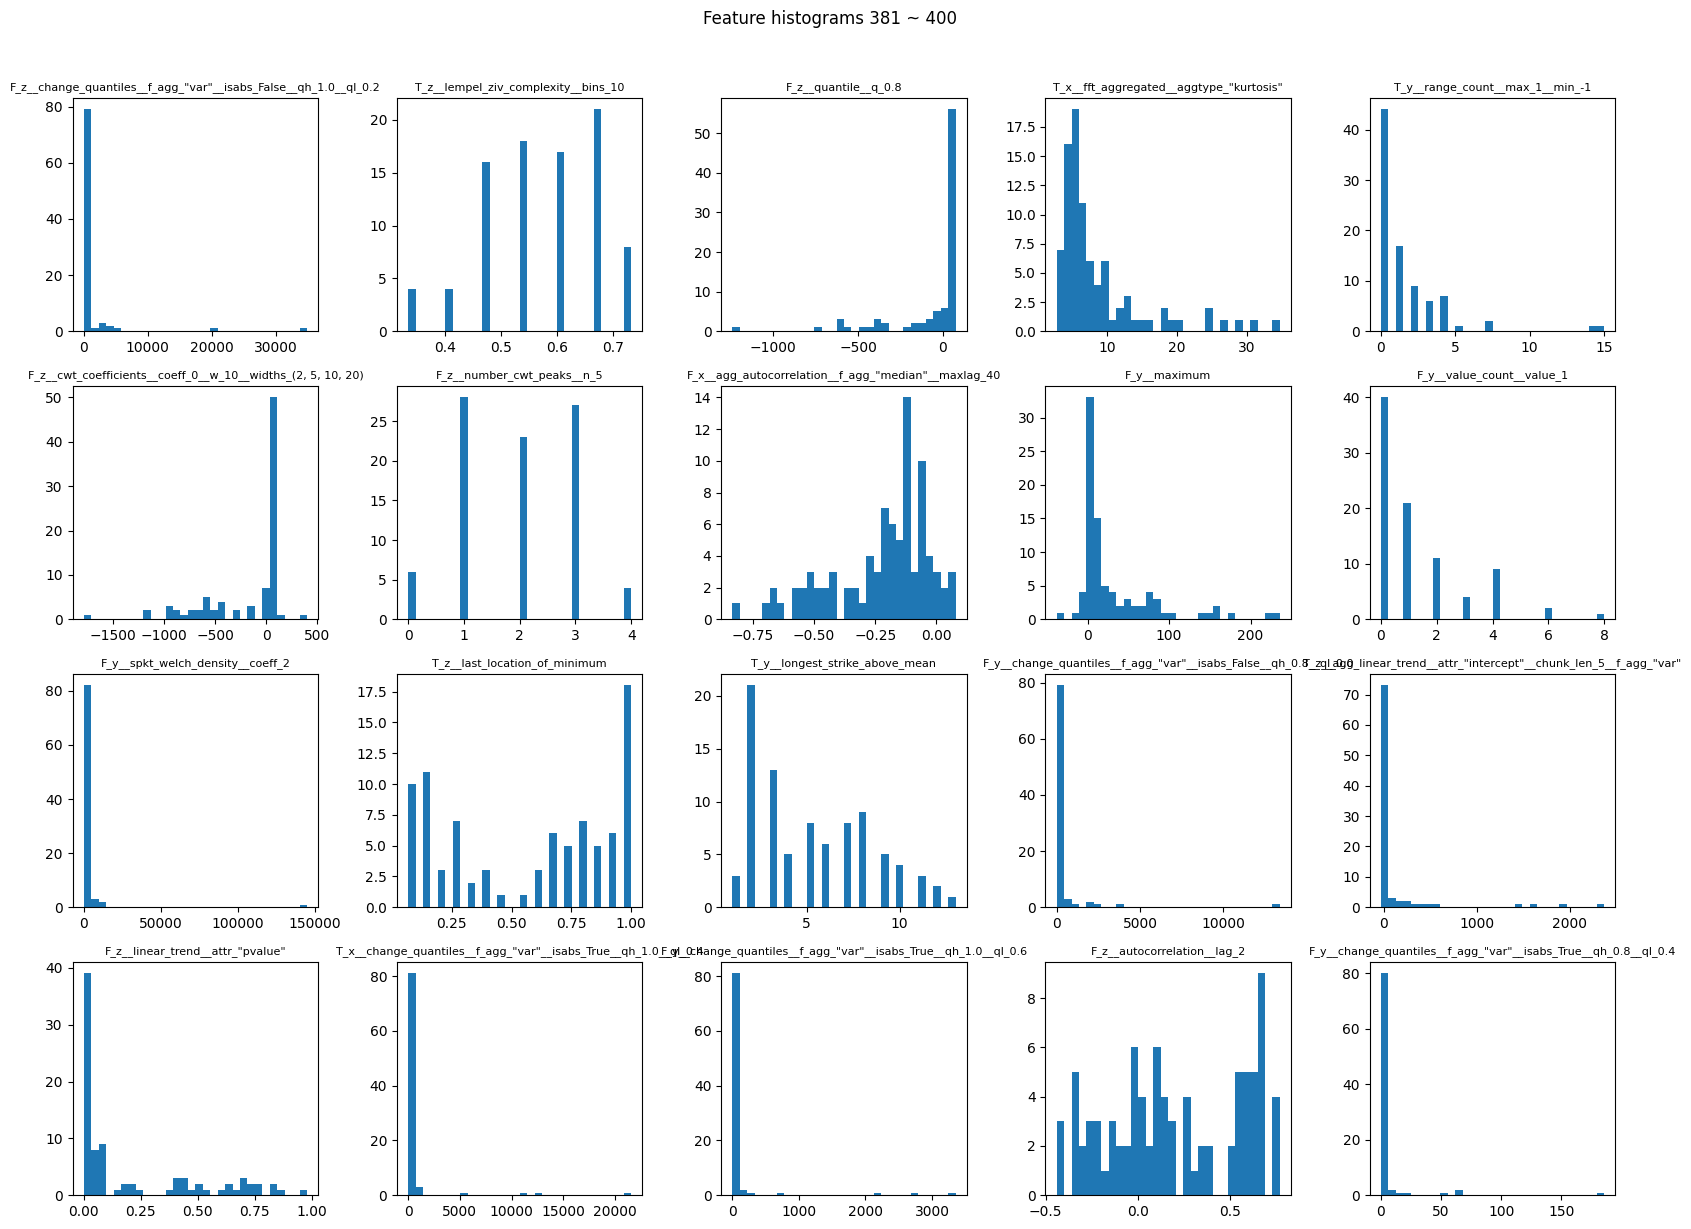

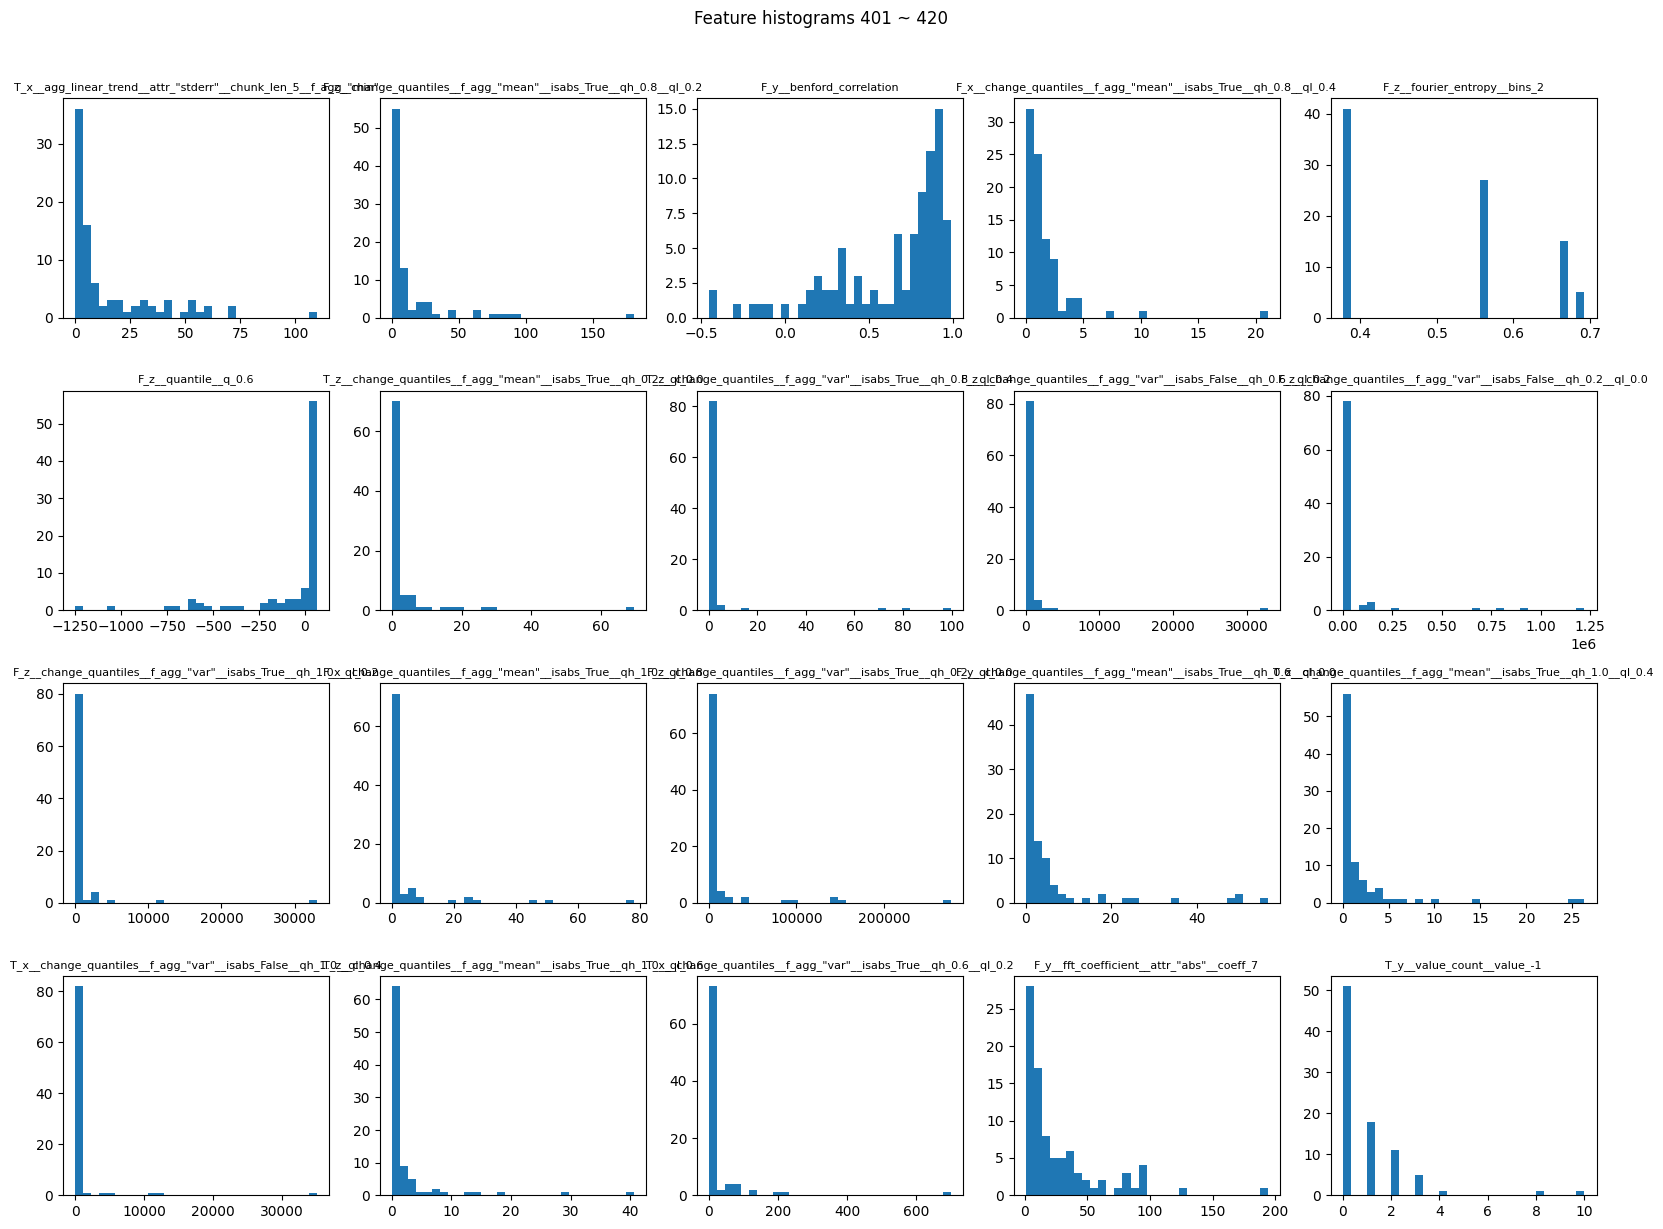

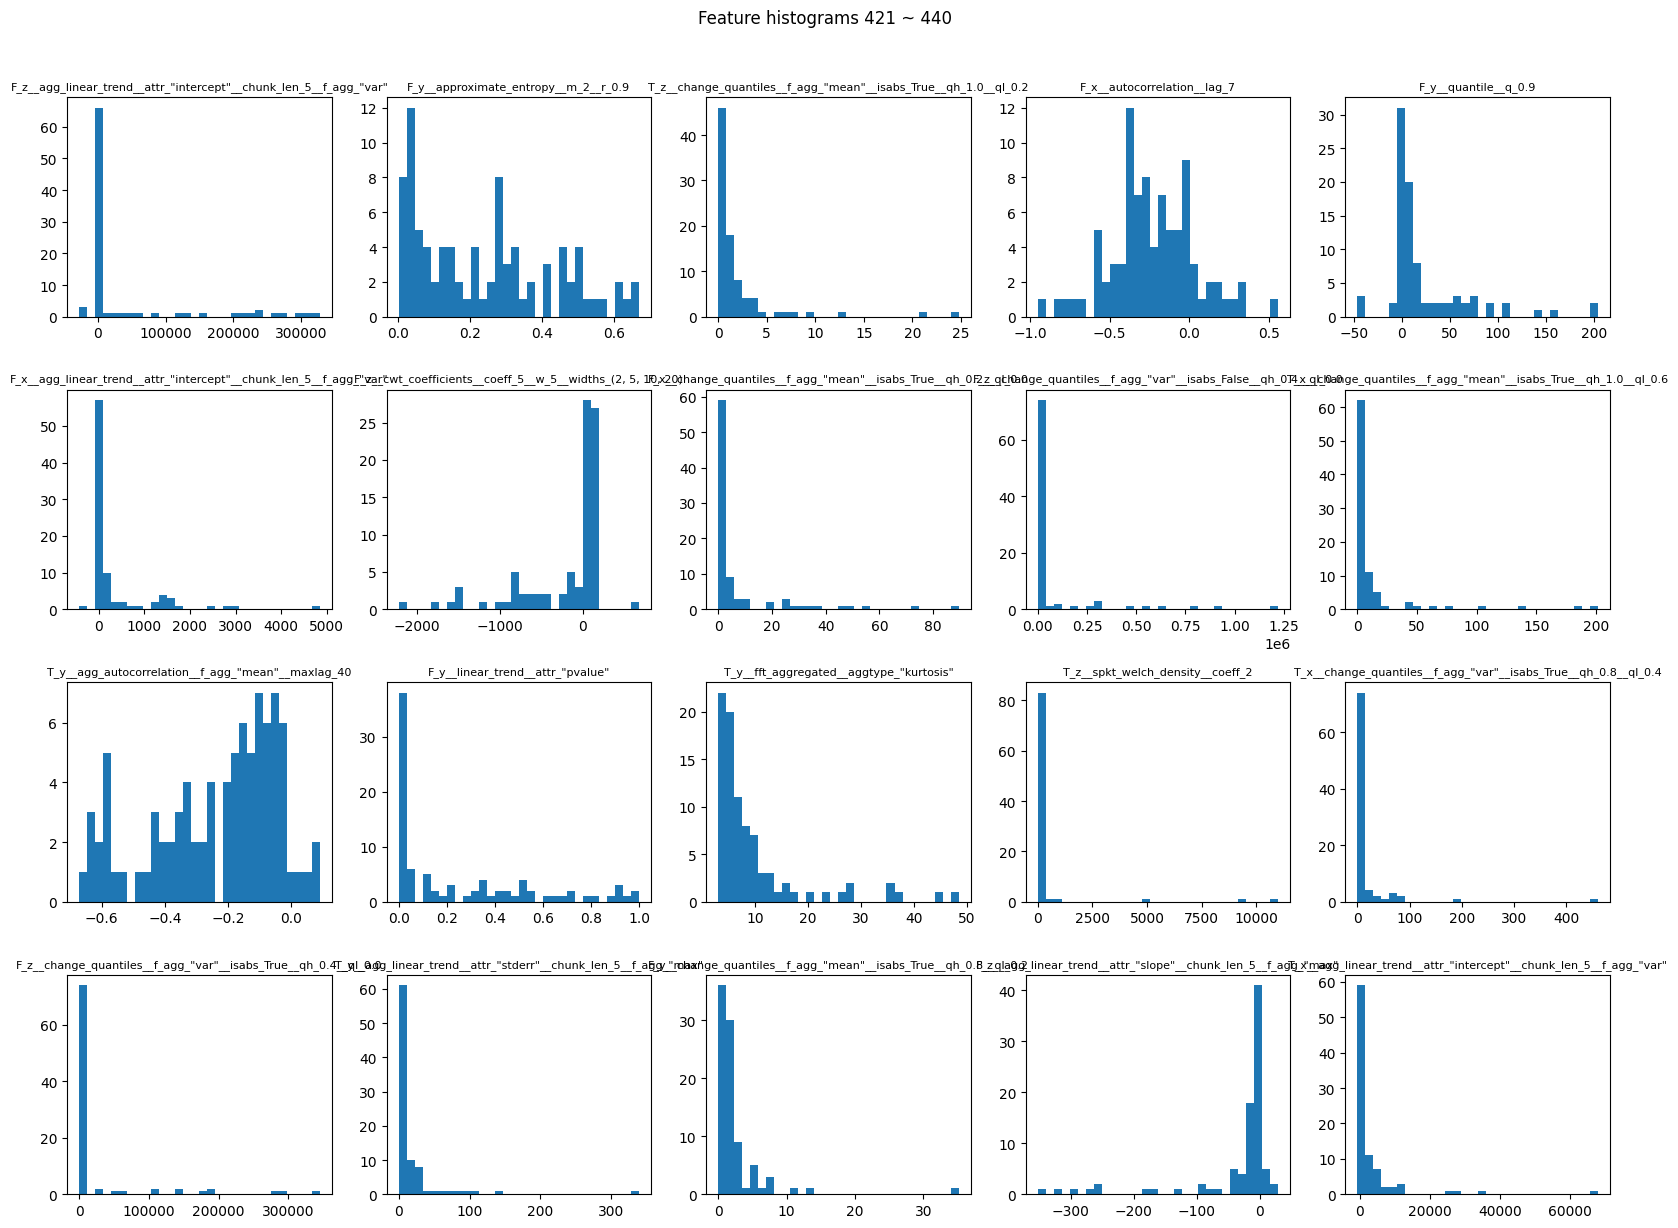

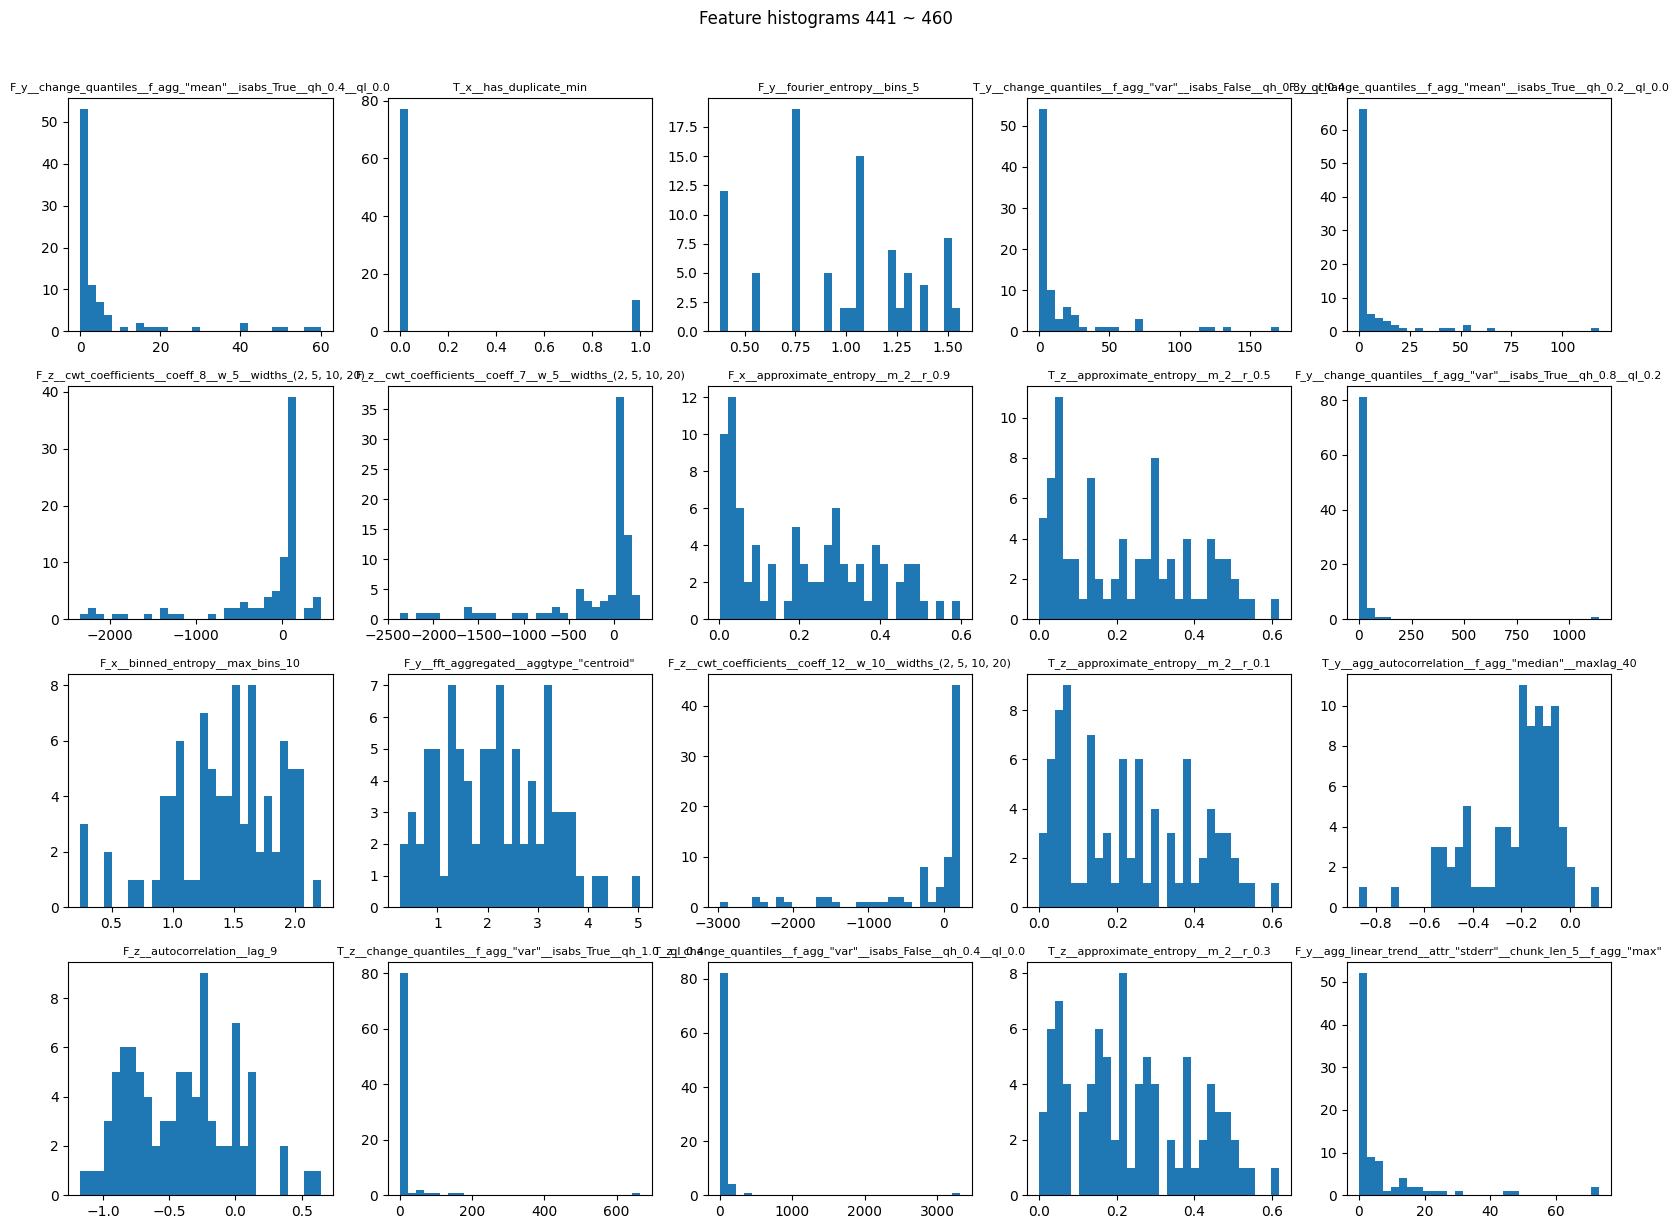

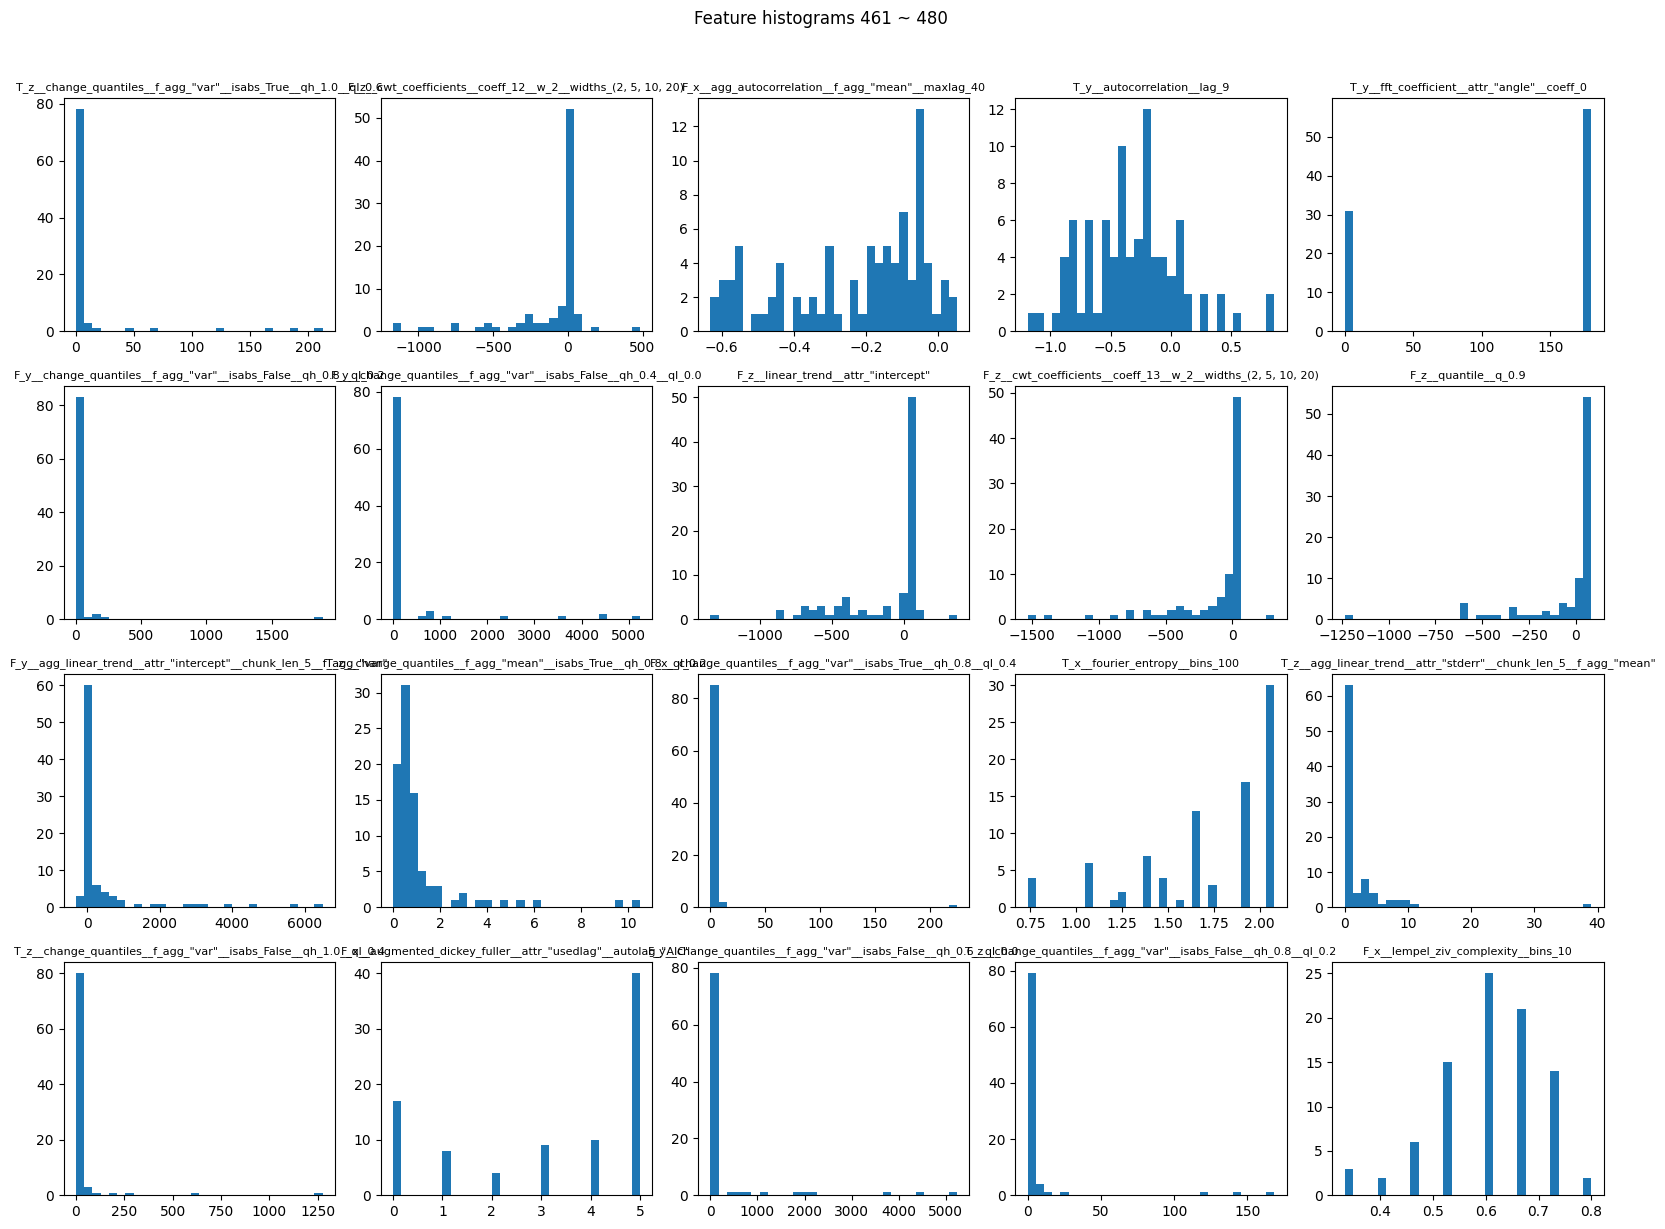

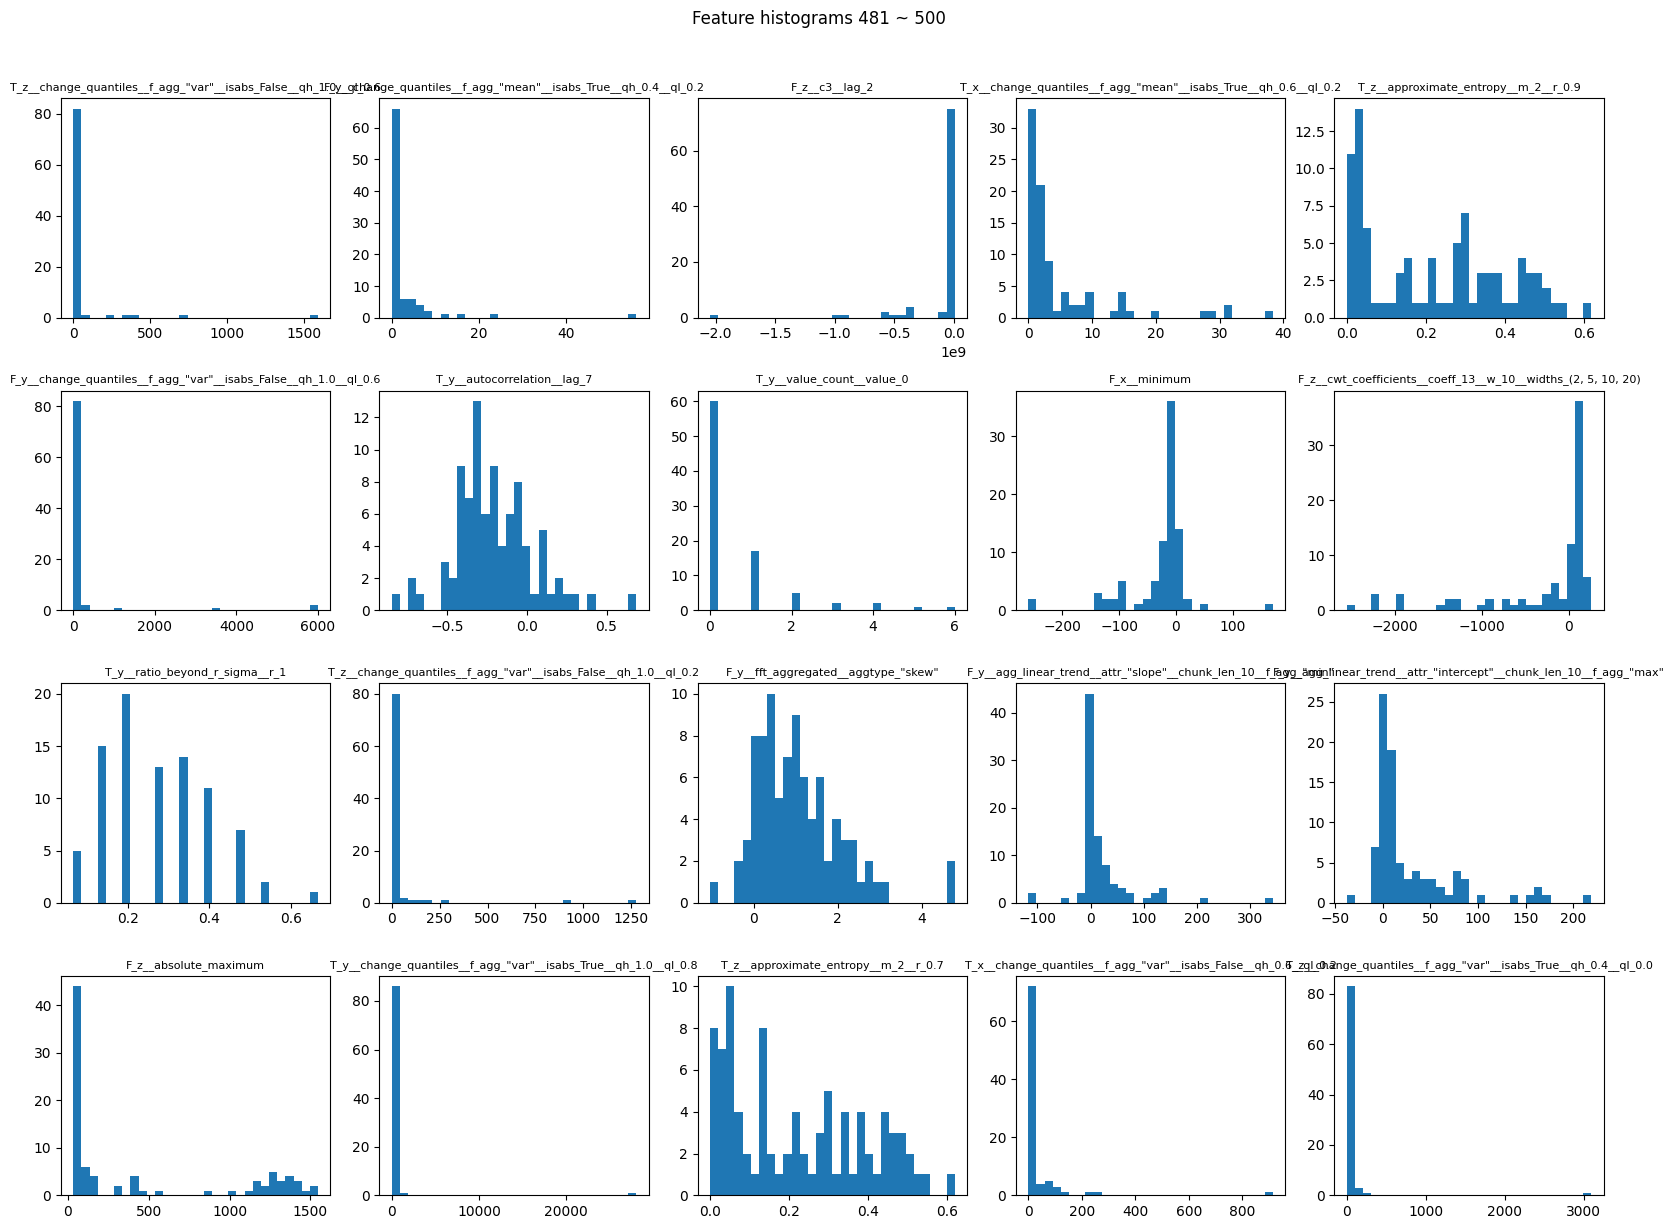

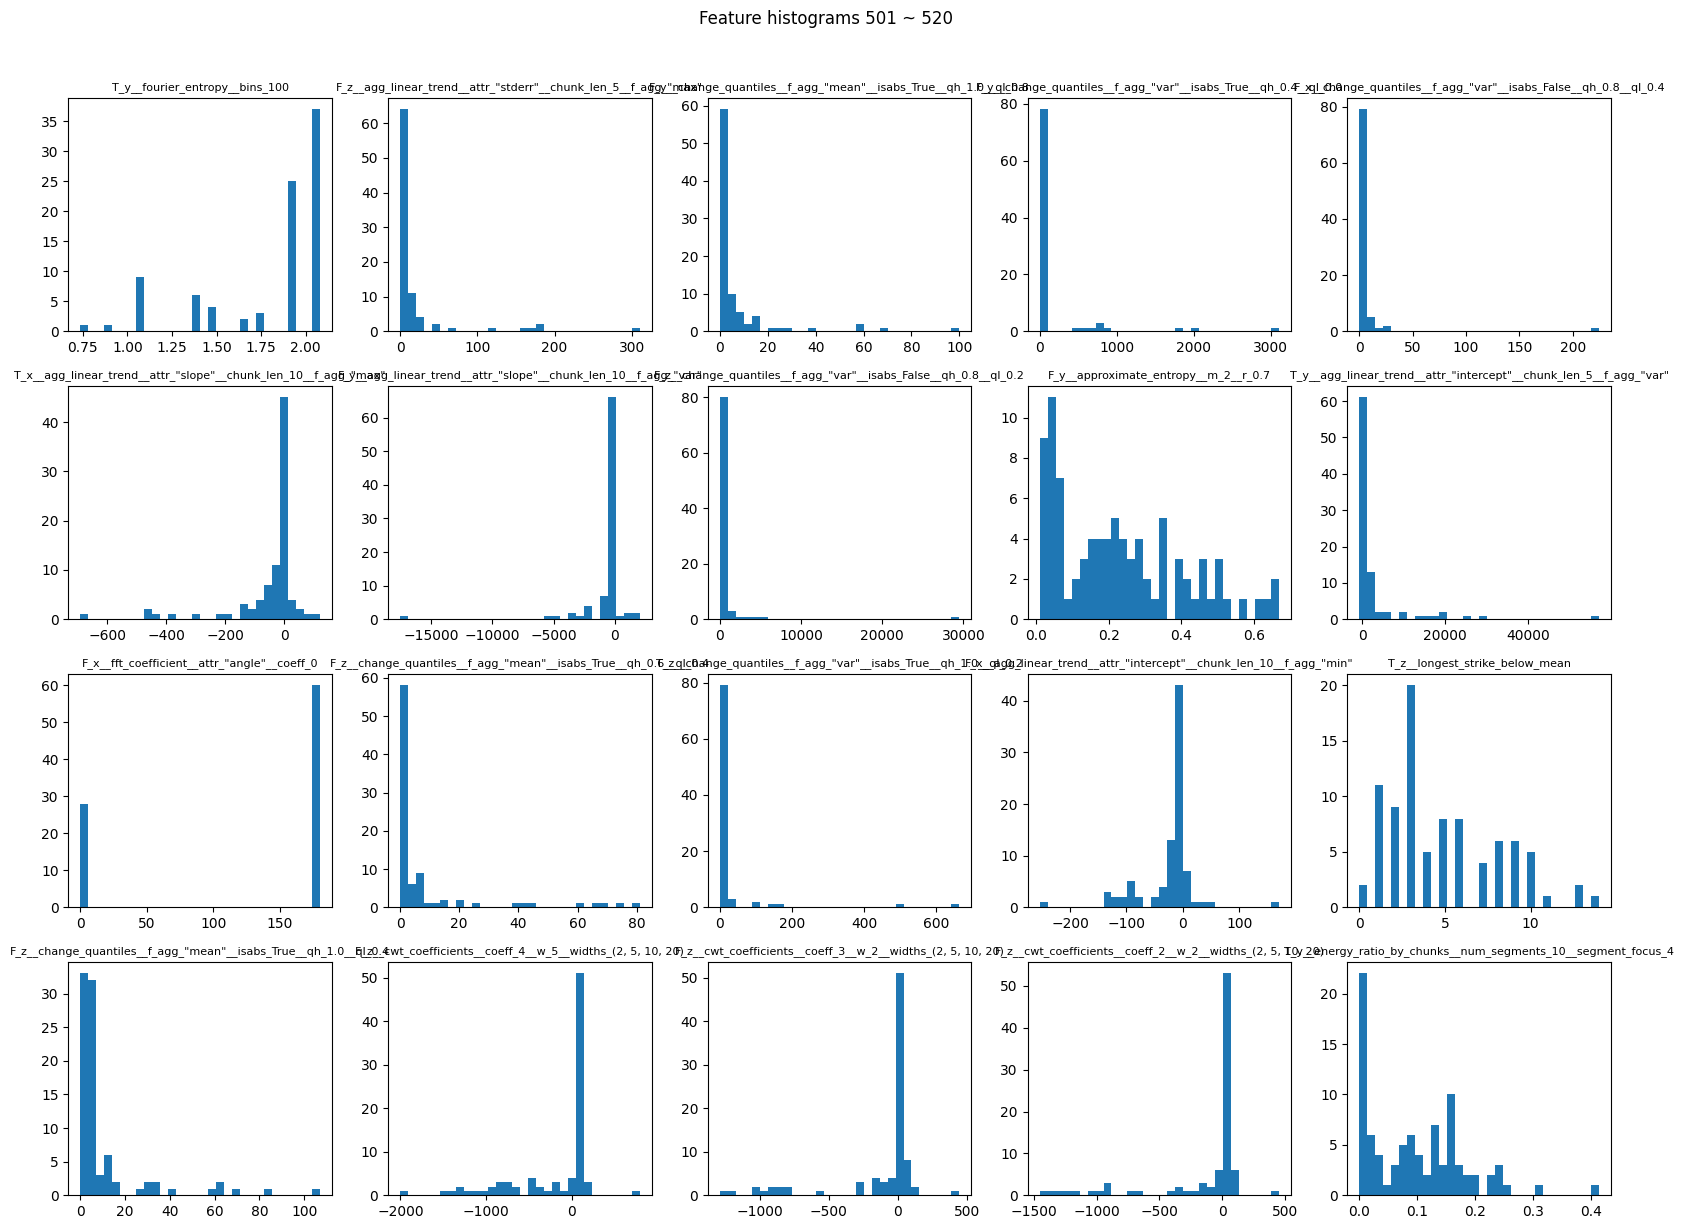

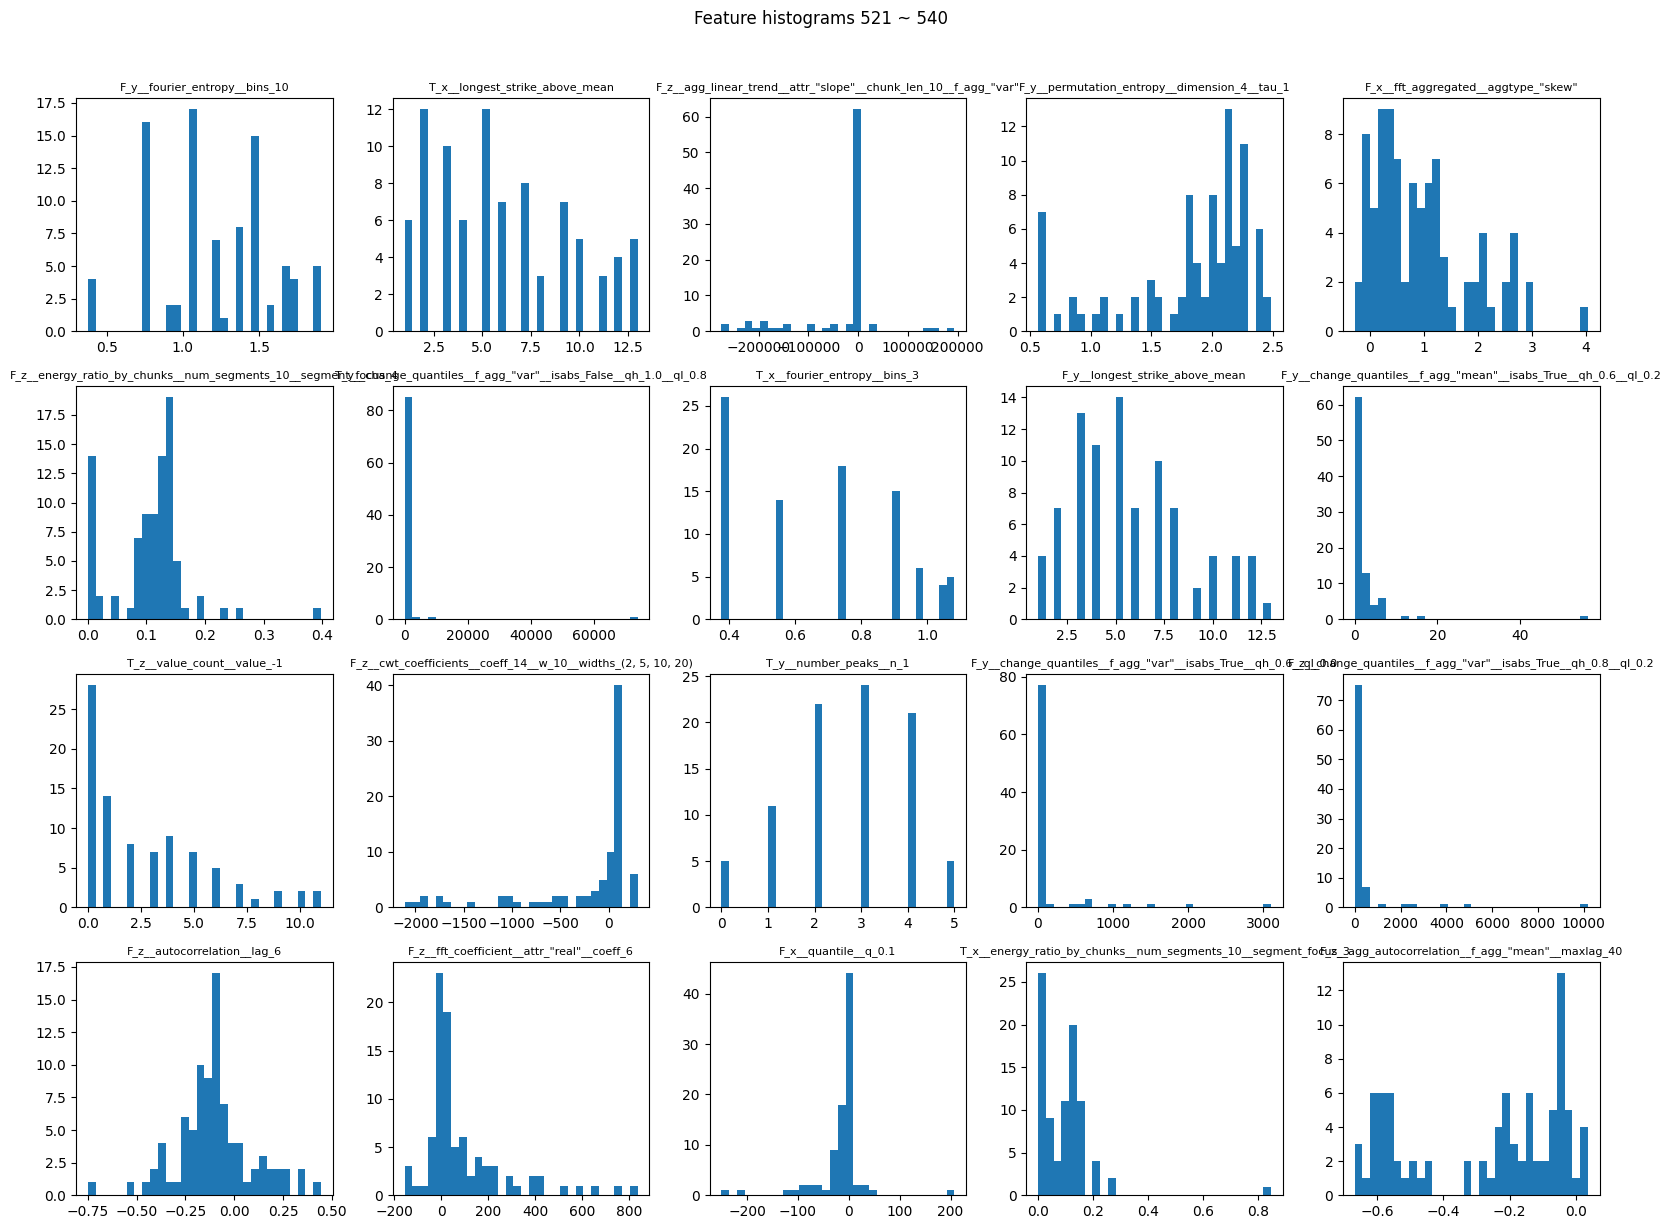

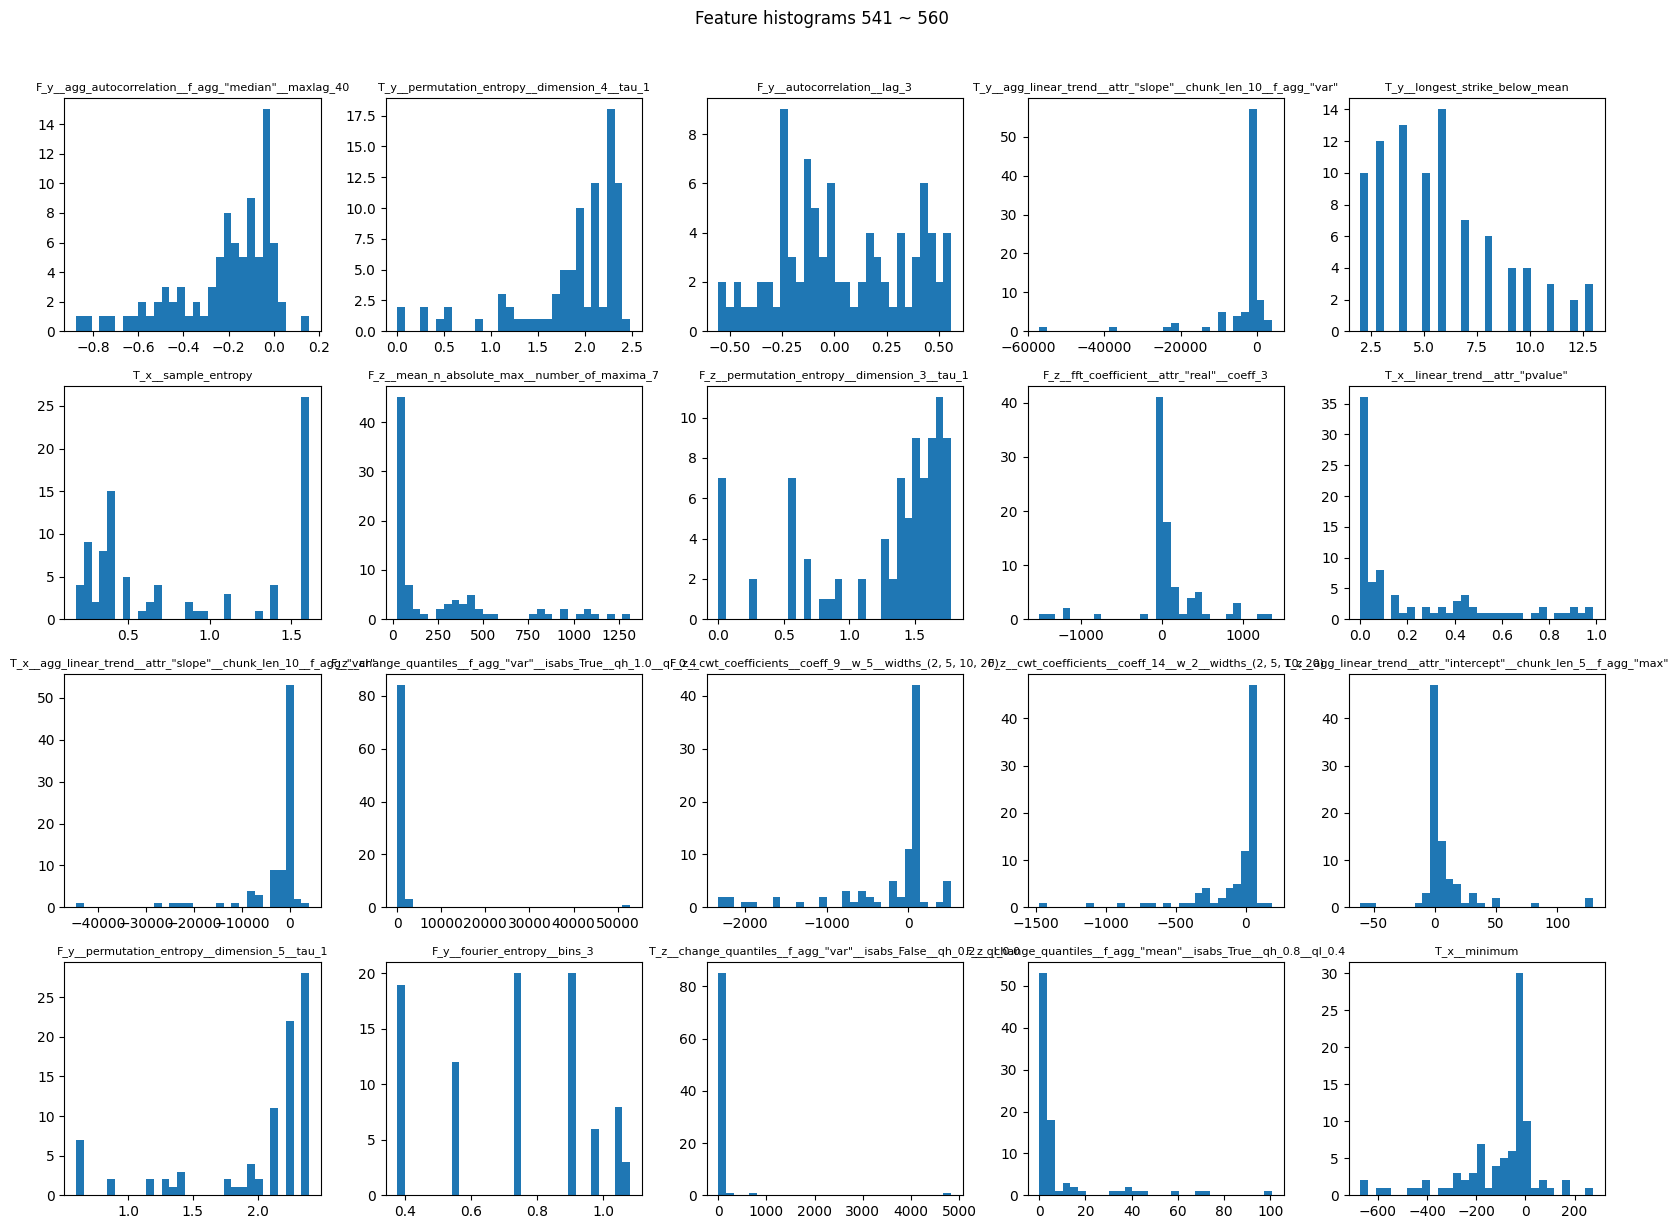

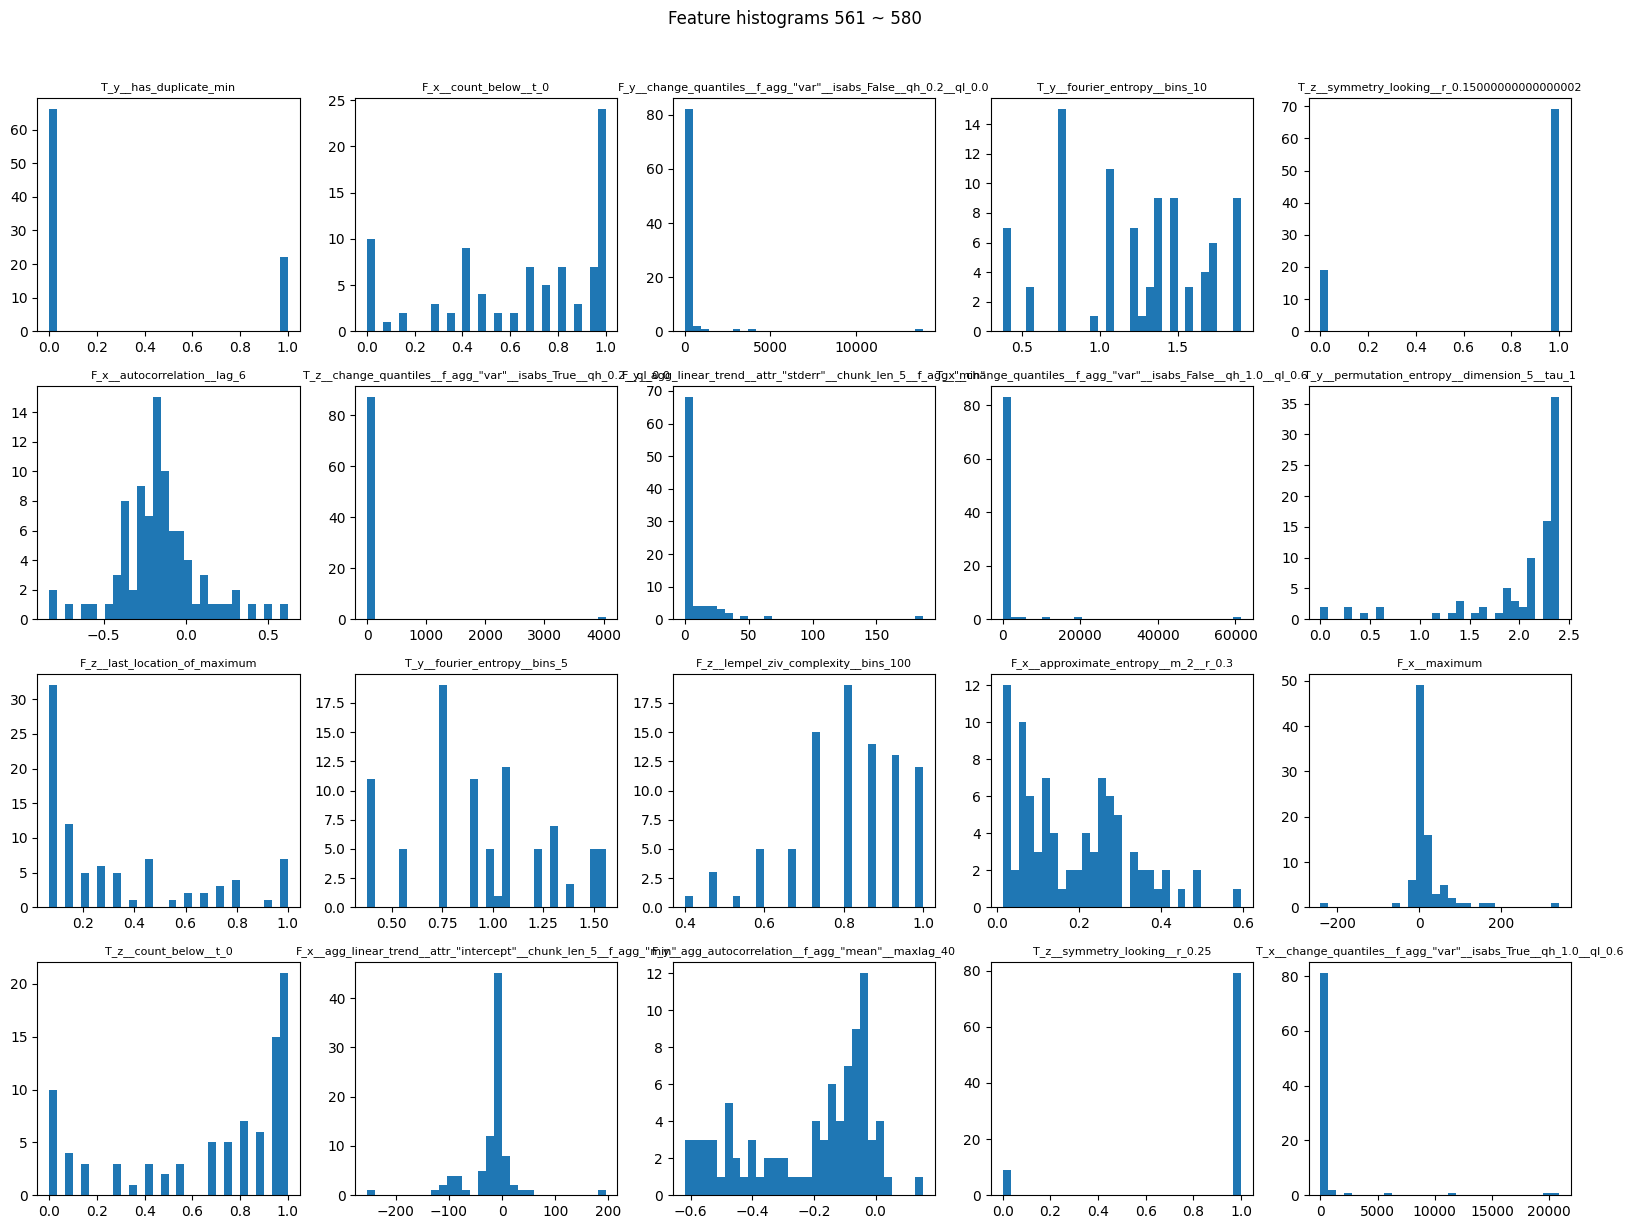

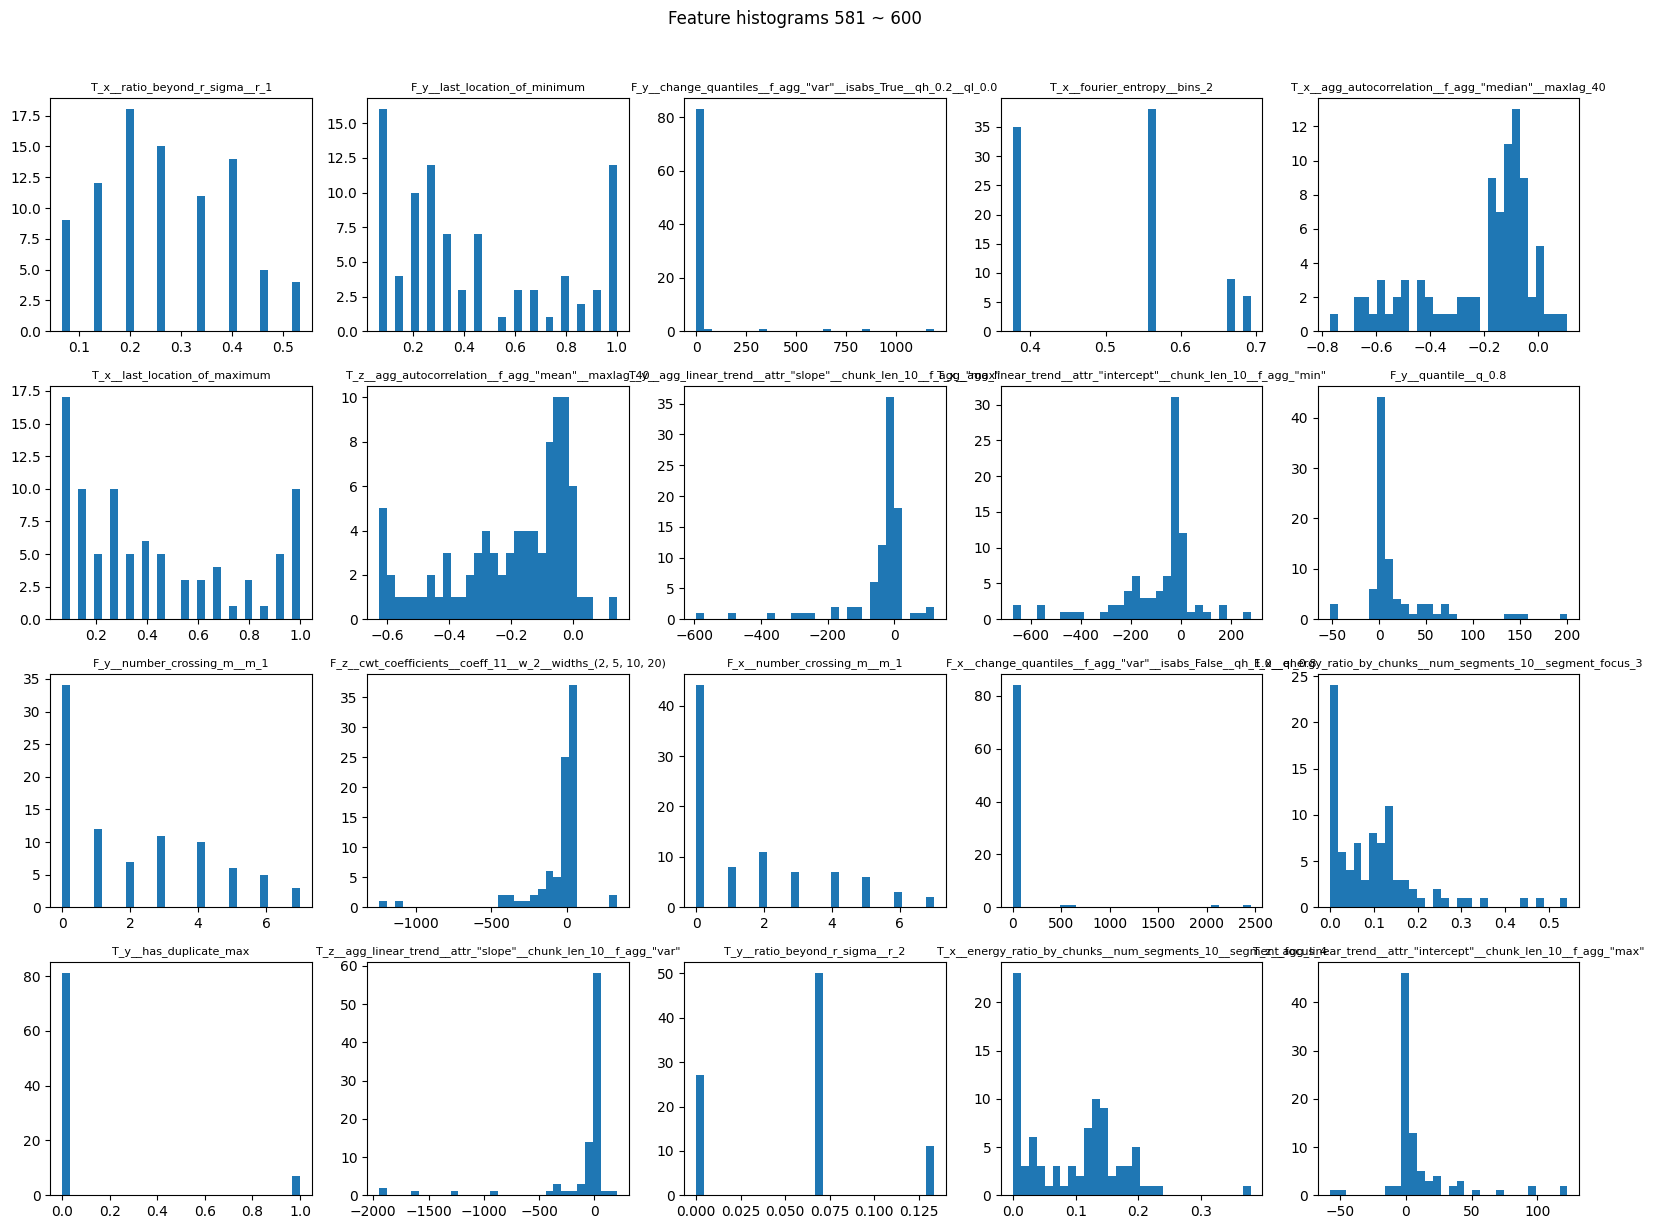

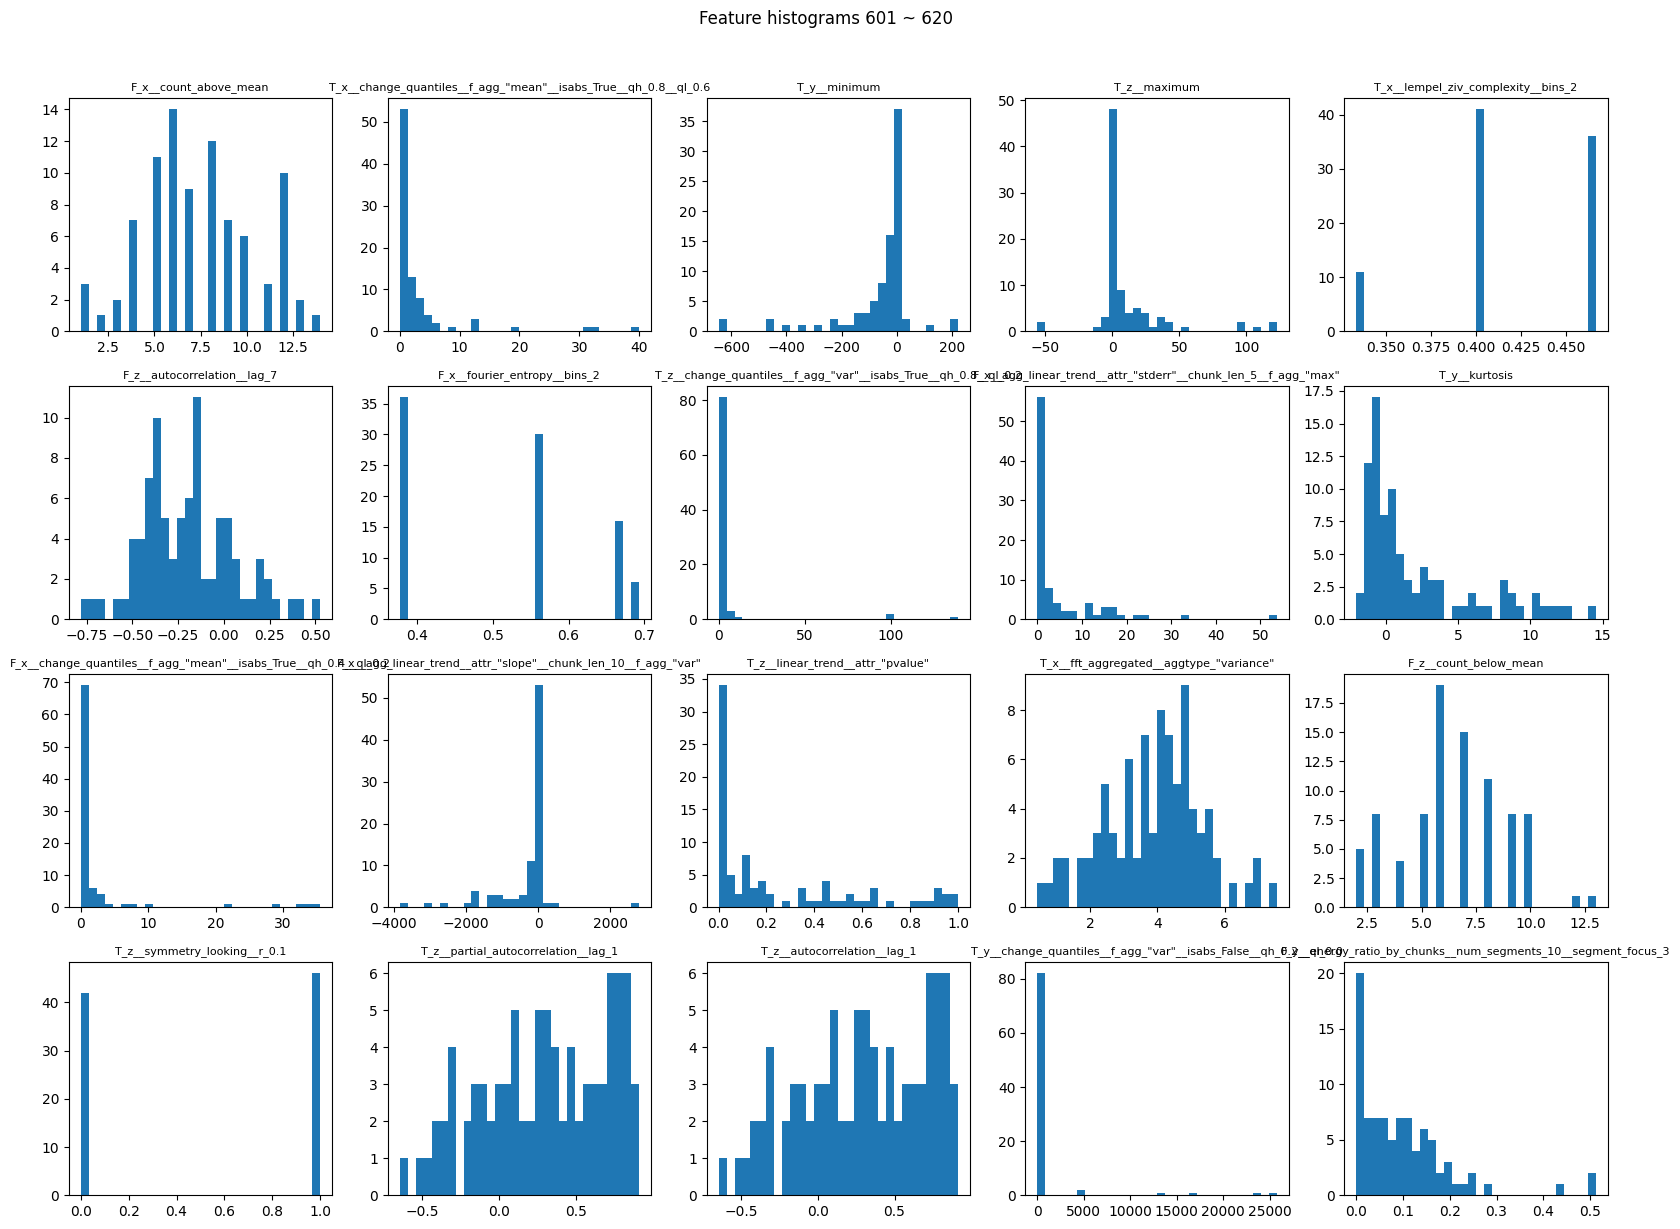

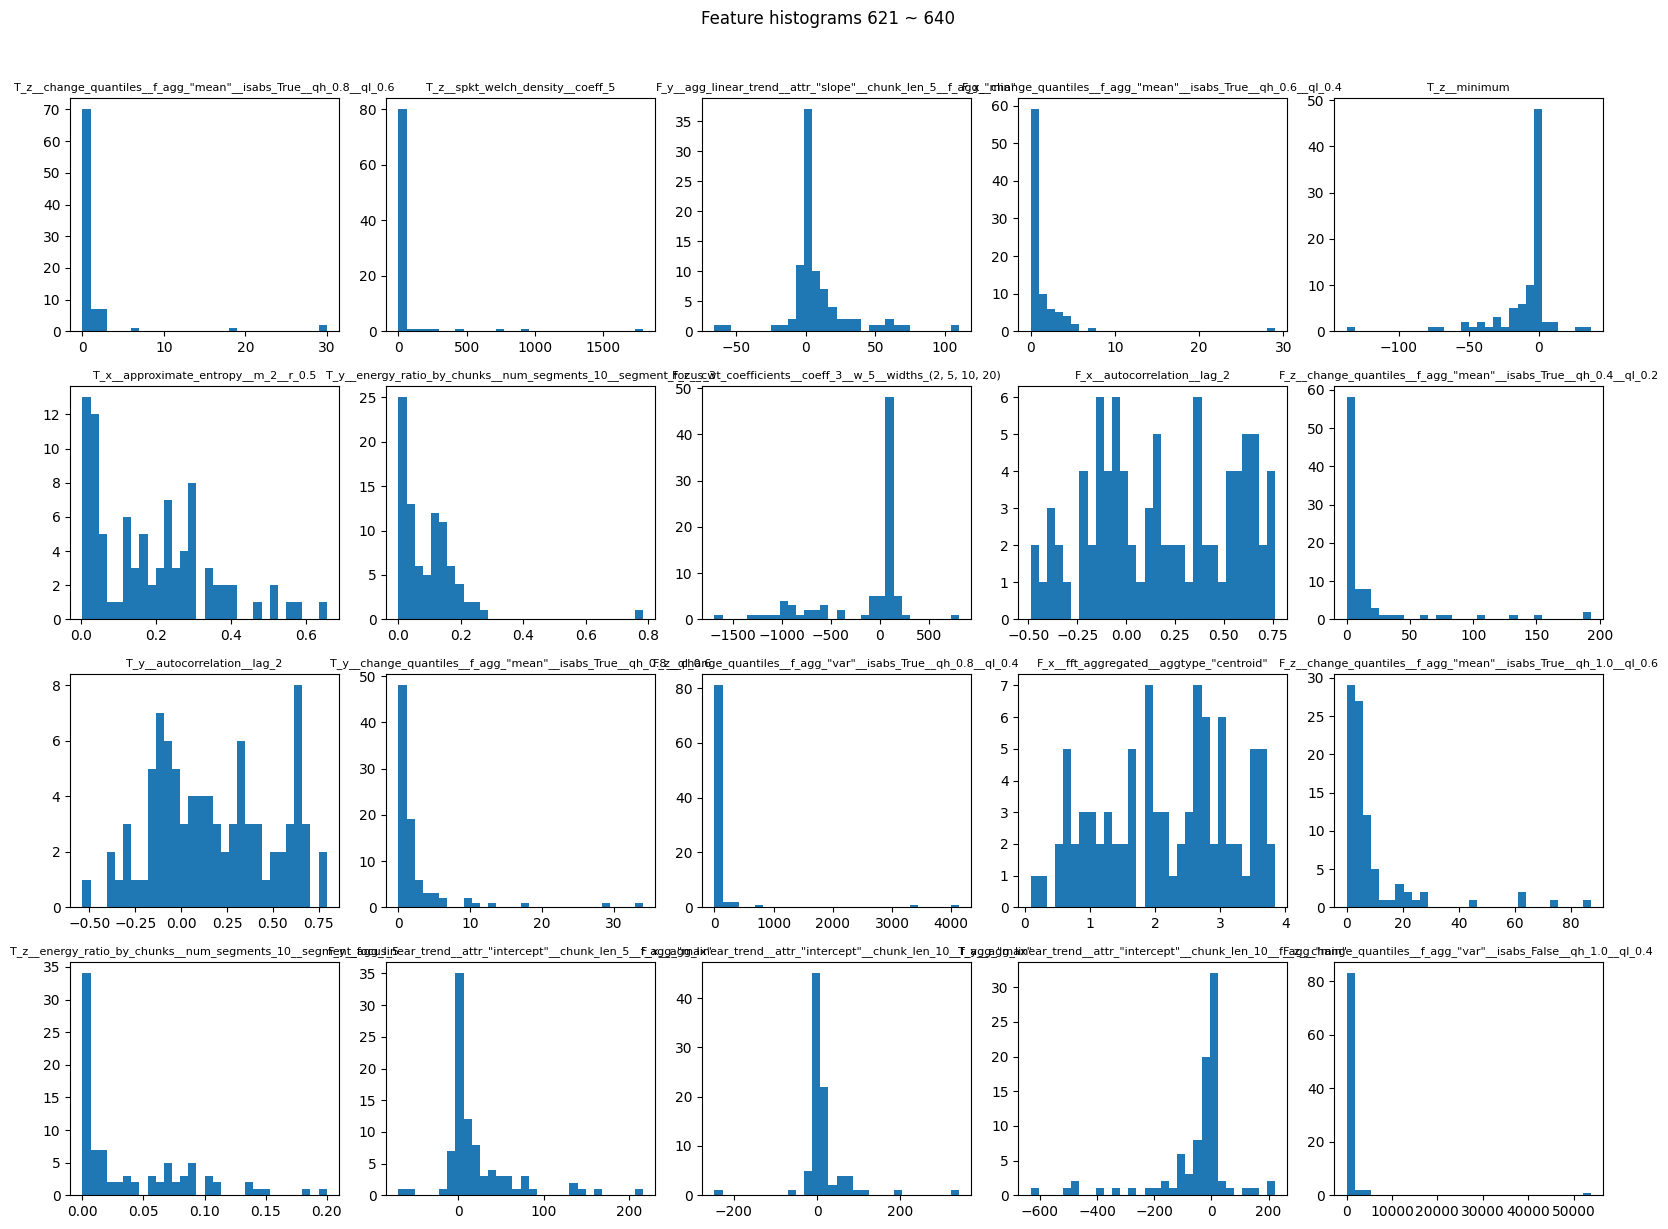

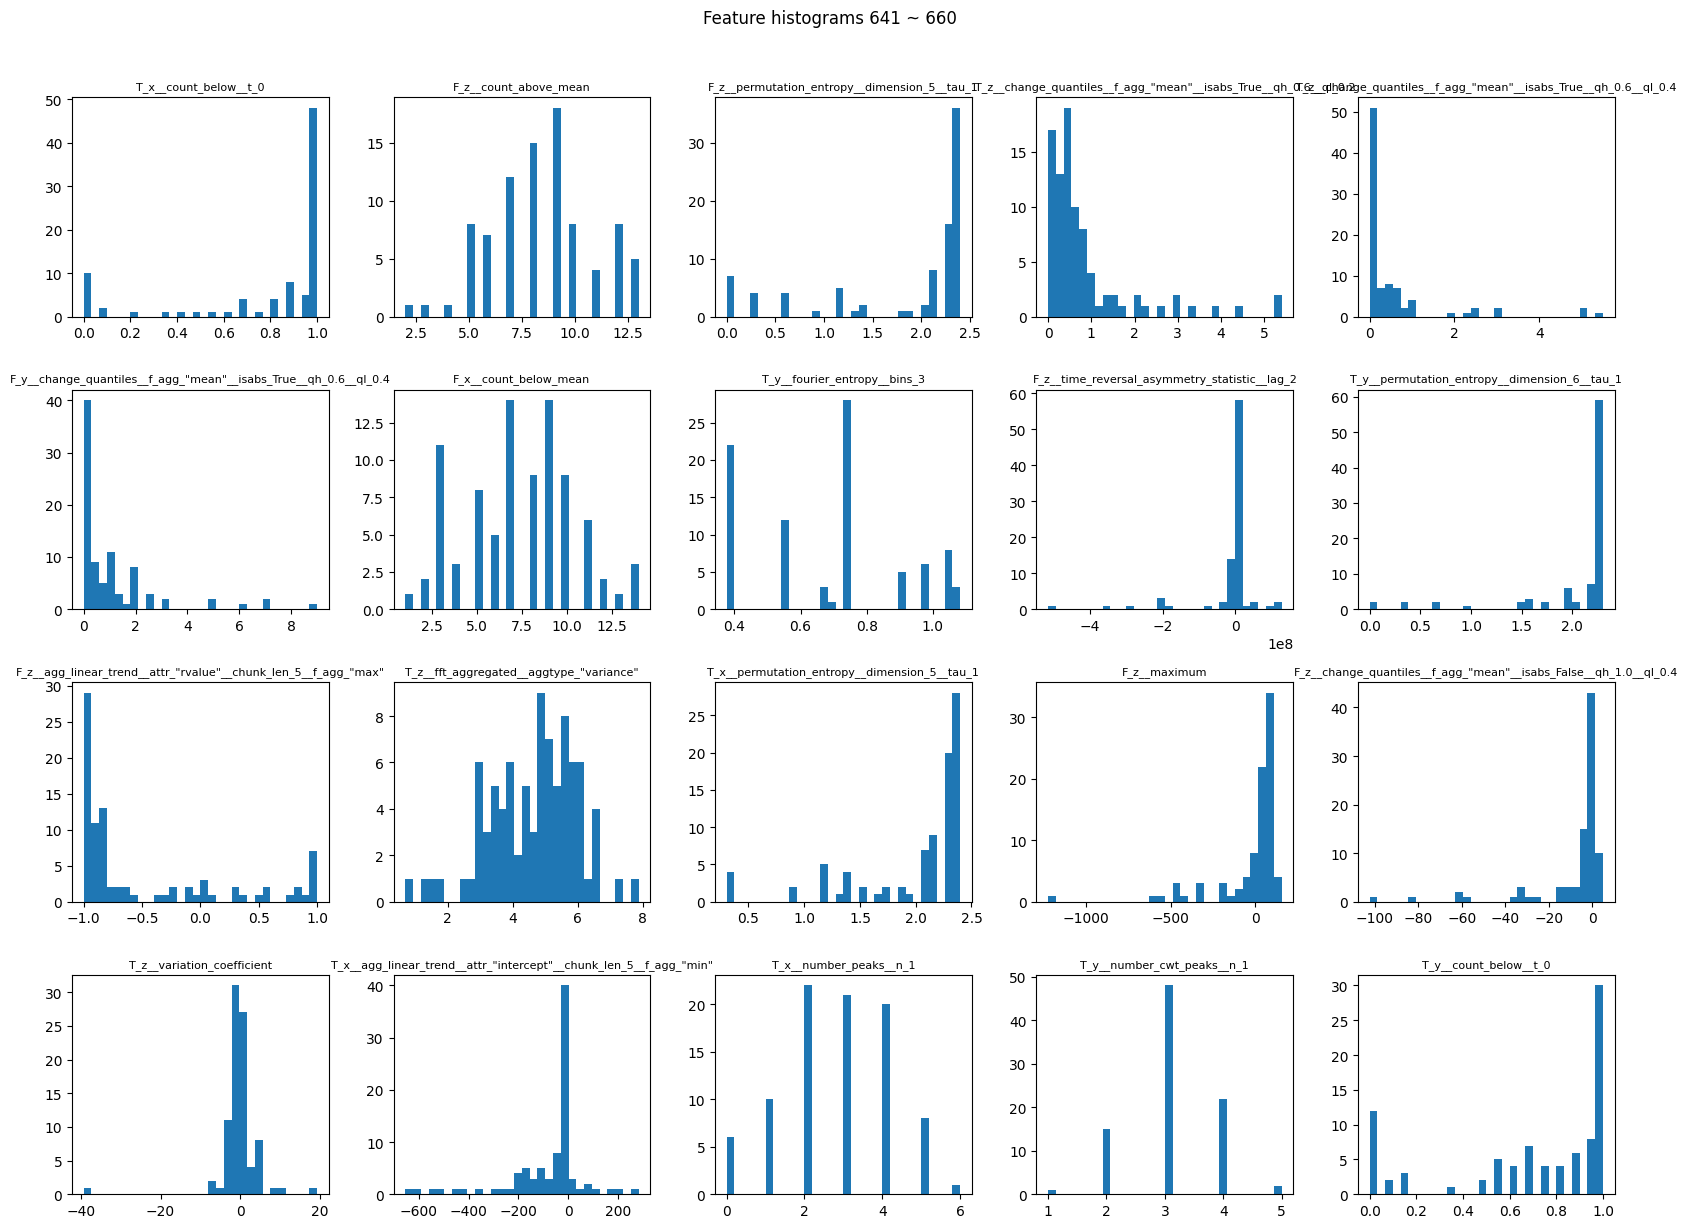

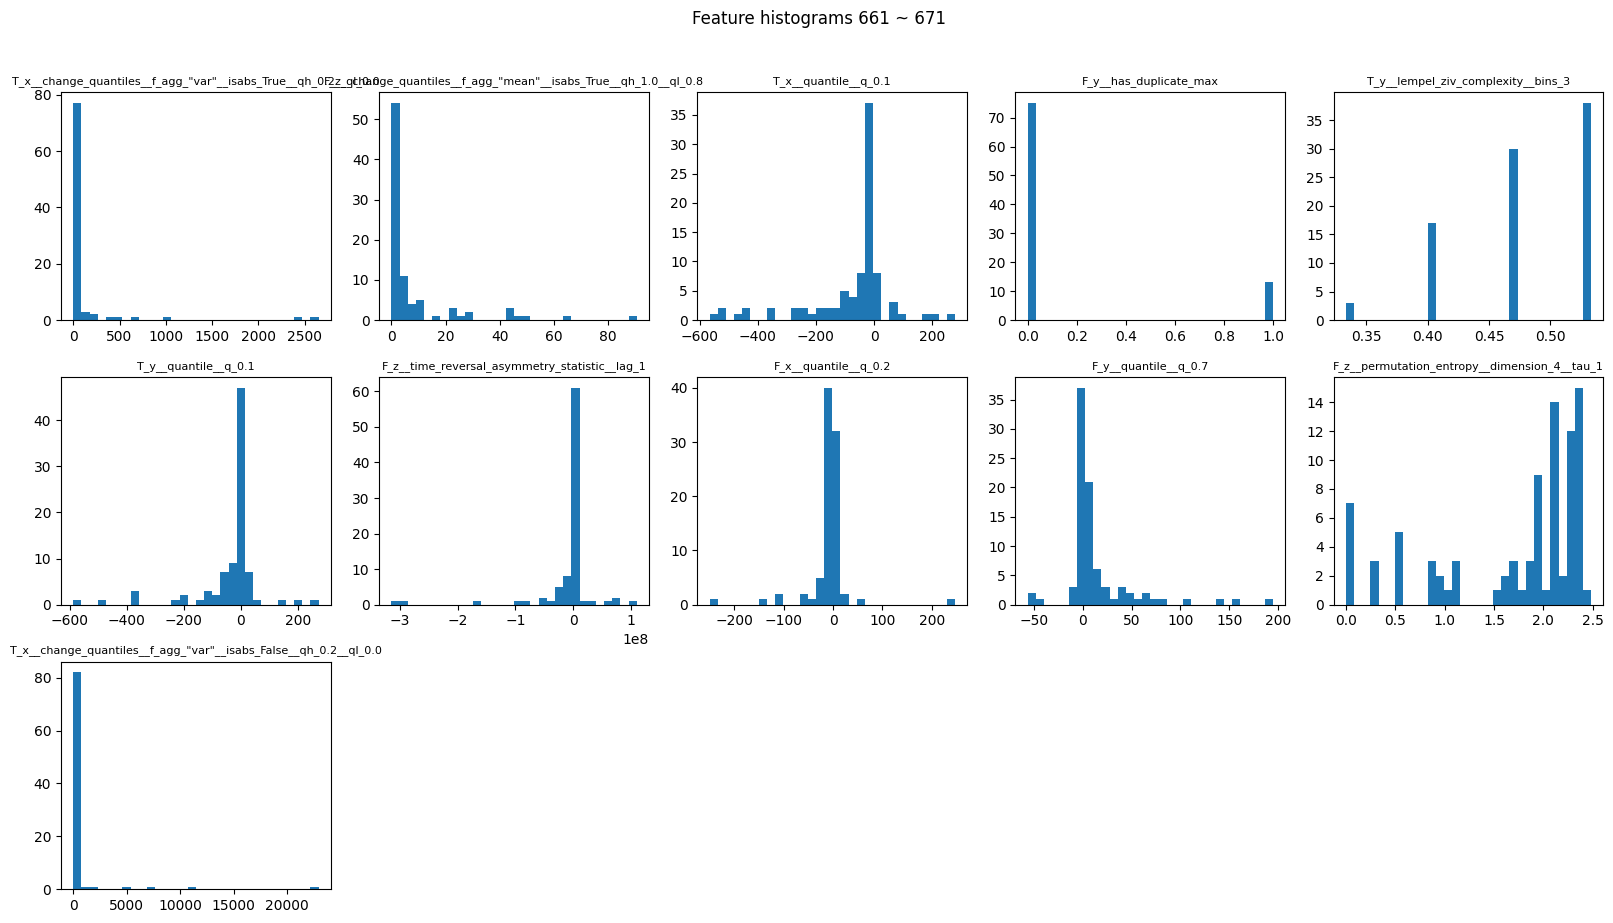

In [16]:
# 3. “전체 분포”를 페이지 나눠서 히스토그램으로 보기

# 정말 각 feature의 분포도 보고 싶다

import matplotlib.pyplot as plt
import math

cols = X.columns
per_page = 20  # 한 페이지에 20개씩

for start in range(0, len(cols), per_page):
    subset = cols[start:start+per_page]
    n = len(subset)
    n_cols = 5
    n_rows = math.ceil(n / n_cols)

    plt.figure(figsize=(16, 3*n_rows))

    for i, col in enumerate(subset, 1):
        plt.subplot(n_rows, n_cols, i)
        plt.hist(X[col], bins=30)
        plt.title(col, fontsize=8)
        plt.tight_layout()

    plt.suptitle(f"Feature histograms {start+1} ~ {start+n}", y=1.02)
    plt.tight_layout()
    plt.show()


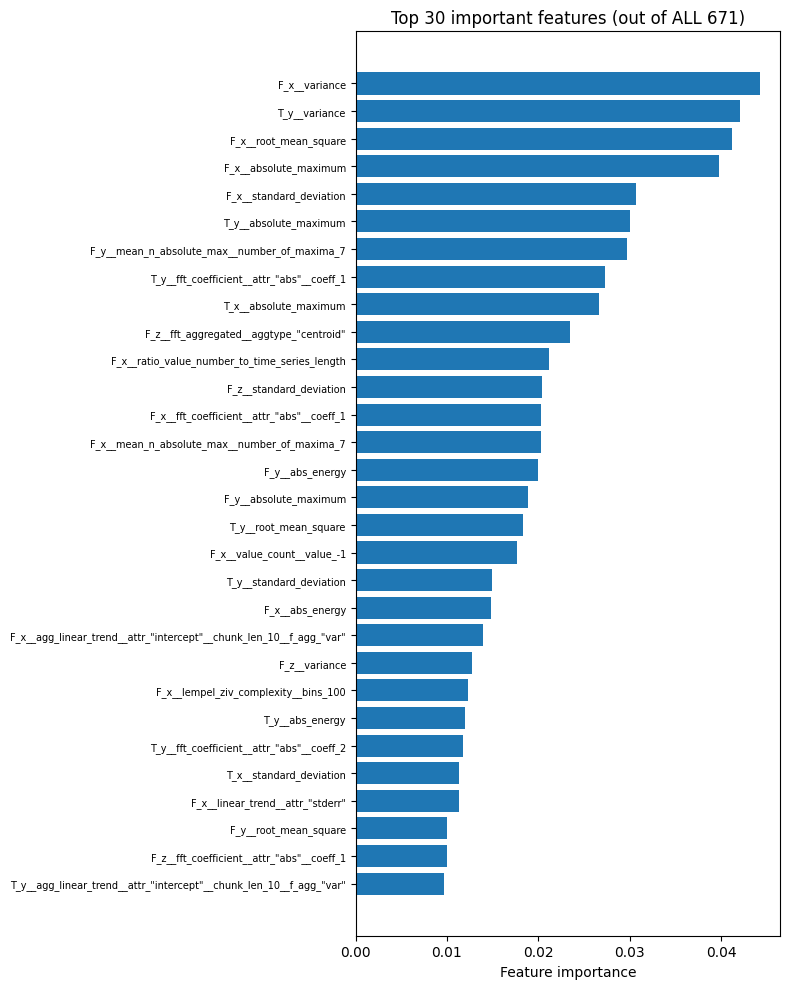

In [17]:
# 전체 feature 중요도 요약
# 671개 중 어떤 애들이 특히 중요한지, 모델링 전에

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y_aligned, test_size=0.2, random_state=42, stratify=y_aligned
)

clf = RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1
)
clf.fit(X_train, y_train)

# 중요도 상위 30개만 시각화
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1][:30]

top_features = X.columns[indices]
top_importances = importances[indices]

plt.figure(figsize=(8, 10))
plt.barh(range(len(top_features)), top_importances[::-1])
plt.yticks(range(len(top_features)), top_features[::-1], fontsize=7)
plt.xlabel("Feature importance")
plt.title("Top 30 important features (out of ALL 671)")
plt.tight_layout()
plt.show()


정리하면

    - “전체 구조” → PCA 설명력 그래프 + PCA 2D scatter
    - “전체 관계” → 671×671 상관 heatmap
    - “전체 분포” → 히스토그램을 페이지 나눠서 자동 생성
    - “전체 중 중요한 것” → 랜덤포레스트 feature importance

features_filtered 전체가 어떤 모양

“몇 개를 쓰면 좋을까?”
-  1. 시각화(2D/3D)
          - PC 2개만 써도 30% 이상은 설명 → 구조를 “대충” 보는 데는 충분
          - 이미 그걸로 정상/고장 군집이 어느 정도 분리되는지 볼 수 있음

- 2. 차원 축소 + 분류 모델 학습
        - 보통 90~95% 설명 분산 기준으로
        -  → 30~40개 PC 정도가 적당한 선택
        - 671차원 → 40차원으로 줄이면

과적합 줄이기 / 학습 속도 개선 / feature 중요도 고려

“tsfresh로 추출한 671개의 시계열 feature에 PCA를 적용한 결과,
첫 번째 주성분만으로 전체 분산의 약 26%를 설명하고,
상위 20개 주성분으로 약 85%, 40개 주성분으로 약 95% 이상의 분산을 설명하였다.
이는 다수의 tsfresh feature가 서로 강하게 상관되어 있어,
수십 개 수준의 저차원 공간으로도 원래 정보 대부분을 보존할 수 있음을 의미한다.

시계열 데이터 분류

In [19]:
# ③ robot_execution_failures 데이터셋 다운로드 및 불러오기
from tsfresh.examples.robot_execution_failures import download_robot_execution_failures, load_robot_execution_failures

download_robot_execution_failures()
timeseries, y = load_robot_execution_failures()

In [20]:
# ④ 추가로 필요한 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [21]:
# ⑤ 데이터셋 가공
def custom_classification_split(x, y, test_size=0.3):
    num_true = int(y.sum()*test_size)           # int(21 * 0.3) = 6
    num_false = int((len(y)-y.sum())*test_size) # int((88 - 21)*0.3) = 20

    id_list = y[y==False].head(num_false).index.to_list() + y[y==True].head(num_true).index.to_list()
    # y==False인것과 y==True인것의 인덱스값을 리스트로 변환하여 더해줍니다.
    # y[y==False].head(num_false).index.to_list()는 19~38까지의 값이 리스트로
    # y[y==True].head(num_true).index.to_list()는 1~6까지의 값이 리스트로
    # id_list는 19~38 + 1~6이 더해진 리스트입니다.

    y_train = y.drop(id_list)                            # y에서 id_list를 drop합니다.
    y_test = y.iloc[id_list].sort_index()                # 19~38, 1~6이 합쳐진 리스트를 정렬합니다.
    X_train = x[~x['id'].isin(id_list)] # 대괄호 안에 있는 timeseries의 id와 id_list가 일치하는 것만 사용하고 물결표시는 안에 조건이 포함되어 있지 않는것만 사용하는 것입니다.
    X_test = x[x['id'].isin(id_list)]   # timeseries의 id와 id_list가 일치하는 것만 사용해서 timeseries에 적용

    return X_train, y_train, X_test, y_test

In [22]:
# 커스텀한 함수를 적용한 데이터셋이 어떤 차이가 있는지 확인해봅시다.
X_train, y_train, X_test, y_test = custom_classification_split(timeseries, y)
print(X_train)
print('-'*50)
print(y_train)
print('-'*50)
print(X_test)
print('-'*50)
print(y_test)

      id  time  F_x  F_y  F_z  T_x  T_y  T_z
90     7     0   -3    1   53  -10   -4    0
91     7     1    0   -2   65   -4   -1    0
92     7     2   -1   -1   56   -7   -3    0
93     7     3    0   -2   60   -6    0    0
94     7     4   -1   -1   57   -7   -4    0
...   ..   ...  ...  ...  ...  ...  ...  ...
1315  88    10  -10    2   39  -21  -24    5
1316  88    11  -11    2   38  -24  -22    6
1317  88    12  -12    3   23  -24  -24    5
1318  88    13  -13    4   26  -29  -27    5
1319  88    14  -13    2   15  -25  -25    6

[930 rows x 8 columns]
--------------------------------------------------
7      True
8      True
9      True
10     True
11     True
      ...  
84    False
85    False
86    False
87    False
88    False
Length: 62, dtype: bool
--------------------------------------------------
     id  time  F_x  F_y  F_z  T_x  T_y  T_z
0     1     0   -1   -1   63   -3   -1    0
1     1     1    0    0   62   -3   -1    0
2     1     2   -1   -1   61   -3    0    0
3 

- 해석해보자
-----   custom_classification_split(timeseries, y) 의 목적은

id 단위로

train/test를 7:3 정도로 나누고

True/False(고장/정상) 비율도 비슷하게 맞추는 것
!~~(Velog 예제에서 가져온 함수 그대로

In [31]:
"""
 Velog 의거하여 살펴보면
"""

"""
def custom_classification_split(x, y, test_size=0.3):
    num_true  = int(y.sum() * test_size)                # test로 보낼 True 개수
    num_false = int((len(y) - y.sum()) * test_size)     # test로 보낼 False 개수

    # y에서 False 몇 개 + True 몇 개 골라서 test용 id 리스트 만들기
    id_list = (
        y[y == False].head(num_false).index.to_list() +
        y[y == True ].head(num_true ).index.to_list()
    )

    # id_list에 있는 id는 test, 나머지는 train
    y_train = y.drop(id_list)
    y_test  = y.iloc[id_list].sort_index()

    X_train = x[~x["id"].isin(id_list)]
    X_test  = x[ x["id"].isin(id_list)]

    return X_train, y_train, X_test, y_test
# """
# split 기준은 “행”이 아니라 id
# → 하나의 실행(run)에 해당하는 시계열이 통째로 train 또는 test 중 한쪽에만 들어감
# → 같은 run이 train·test에 섞이지 않아서 데이터 누수(leakage) 를 막음.

# test에 들어갈 True/False 개수를 따로 계산해서
# → train/test 둘 다 클래스 비율이 원래랑 비슷하게 유지되도록 함.



원본:

timeseries: 1320행 × 8열,

88개의 id × 각 id당 15개의 time step

y: 길이 88 (각 id의 레이블)

커스텀 split 후:

X_train: 62개 id에 해당하는 time step 전부 (62×15 = 930행)

y_train: 그 62개 id의 라벨 (길이 62)

X_test: 나머지 26개 id의 time step 전부 (26×15 = 390행)

y_test: 그 26개 id의 라벨 (길이 26)

→ 차이점/효과는:

id 단위로 나눔:
하나의 실행(run)이 train과 test에 동시에 들어가지 않음 → 시계열 분류에서 필수.

클래스 비율 유지:
test 쪽에 들어가는 True/False 개수를 따로 맞춰서
train/test 둘 다 고장/정상 비율이 비슷함.

In [32]:
print("원본 라벨 분포:")
print(y.value_counts(normalize=True))

print("\ntrain 라벨 분포:")
print(y_train.value_counts(normalize=True))

print("\ntest 라벨 분포:")
print(y_test.value_counts(normalize=True))

print("\ntrain/test id 겹침 여부:",
      set(X_train["id"]).isdisjoint(set(X_test["id"])))


원본 라벨 분포:
False    0.761364
True     0.238636
Name: proportion, dtype: float64

train 라벨 분포:
False    0.758065
True     0.241935
Name: proportion, dtype: float64

test 라벨 분포:
False    0.769231
True     0.230769
Name: proportion, dtype: float64

train/test id 겹침 여부: True


이제 이 split 결과를 가지고,  

X_train / X_test 각각에 tsfresh로 feature 추출,

그걸로 모델 학습 + 평가

⑥ 특징 추출하기

  - MinimalFCParameters : feature를 최소(minimal)로 하여 계산을 수행합니다. 데이터셋 크기가 큰 경우 모든 feature를 계산하기 전에 설정을 minimal로 변경하여 빠르게 테스트하기 위해 사용합니다.
        - train과 test 데이터셋을 minimal하게 계산한 값으로 변경해줍니다.





In [25]:
# ⑥ 특징추출하기
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters

settings = MinimalFCParameters() # 계산 효율을 위해 minimal 셋팅

minimal_features_train = extract_features(
                                X_train,
                                column_id="id",
                                column_sort="time",
                                default_fc_parameters=settings # minimal 적용
                           )

minimal_features_test = extract_features(
                                X_test,
                                column_id="id",
                                column_sort="time",
                                default_fc_parameters=settings # minimal 적용
                           )

Feature Extraction: 100%|██████████| 156/156 [00:00<00:00, 2022.34it/s]


In [26]:
 # 추출된 특징 확인
 # ⑦ 추출된 특징 확인
minimal_features_train

,F_x__sum_values,F_x__median,F_x__mean,F_x__length,F_x__standard_deviation,F_x__variance,F_x__root_mean_square,F_x__maximum,F_x__absolute_maximum,F_x__minimum,...,T_z__sum_values,T_z__median,T_z__mean,T_z__length,T_z__standard_deviation,T_z__variance,T_z__root_mean_square,T_z__maximum,T_z__absolute_maximum,T_z__minimum
7,-13.0,-1.0,-0.866667,15.0,0.805536,0.648889,1.183216,0.0,3.0,-3.0,...,-1.0,0.0,-0.066667,15.0,0.442217,0.195556,0.447214,1.0,1.0,-1.0
8,-10.0,-1.0,-0.666667,15.0,1.135292,1.288889,1.316561,2.0,2.0,-2.0,...,0.0,0.0,0.000000,15.0,1.032796,1.066667,1.032796,3.0,3.0,-1.0
9,-10.0,-1.0,-0.666667,15.0,1.074968,1.155556,1.264911,2.0,3.0,-3.0,...,3.0,0.0,0.200000,15.0,1.045626,1.093333,1.064581,3.0,3.0,-1.0
10,-14.0,-1.0,-0.933333,15.0,0.249444,0.062222,0.966092,0.0,1.0,-1.0,...,0.0,0.0,0.000000,15.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
11,-13.0,-1.0,-0.866667,15.0,0.956847,0.915556,1.290994,1.0,3.0,-3.0,...,-3.0,0.0,-0.200000,15.0,0.400000,0.160000,0.447214,0.0,1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,-1073.0,-98.0,-71.533333,15.0,36.585729,1338.515556,80.346334,-25.0,110.0,-110.0,...,-232.0,-21.0,-15.466667,15.0,9.659998,93.315556,18.235497,0.0,28.0,-28.0
85,143.0,8.0,9.533333,15.0,4.616877,21.315556,10.592450,19.0,19.0,4.0,...,-52.0,-2.0,-3.466667,15.0,2.156128,4.648889,4.082483,0.0,7.0,-7.0
86,961.0,52.0,64.066667,15.0,38.235179,1461.928889,74.608757,148.0,148.0,21.0,...,-81.0,-8.0,-5.400000,15.0,5.462600,29.840000,7.681146,8.0,10.0,-10.0
87,4509.0,338.0,300.600000,15.0,57.753268,3335.440000,306.097697,342.0,342.0,171.0,...,475.0,35.0,31.666667,15.0,9.903983,98.088889,33.179311,44.0,44.0,13.0


In [27]:
minimal_features_train.columns

Index(['F_x__sum_values', 'F_x__median', 'F_x__mean', 'F_x__length',
       'F_x__standard_deviation', 'F_x__variance', 'F_x__root_mean_square',
       'F_x__maximum', 'F_x__absolute_maximum', 'F_x__minimum',
       'F_y__sum_values', 'F_y__median', 'F_y__mean', 'F_y__length',
       'F_y__standard_deviation', 'F_y__variance', 'F_y__root_mean_square',
       'F_y__maximum', 'F_y__absolute_maximum', 'F_y__minimum',
       'F_z__sum_values', 'F_z__median', 'F_z__mean', 'F_z__length',
       'F_z__standard_deviation', 'F_z__variance', 'F_z__root_mean_square',
       'F_z__maximum', 'F_z__absolute_maximum', 'F_z__minimum',
       'T_x__sum_values', 'T_x__median', 'T_x__mean', 'T_x__length',
       'T_x__standard_deviation', 'T_x__variance', 'T_x__root_mean_square',
       'T_x__maximum', 'T_x__absolute_maximum', 'T_x__minimum',
       'T_y__sum_values', 'T_y__median', 'T_y__mean', 'T_y__length',
       'T_y__standard_deviation', 'T_y__variance', 'T_y__root_mean_square',
       'T_y__maximu

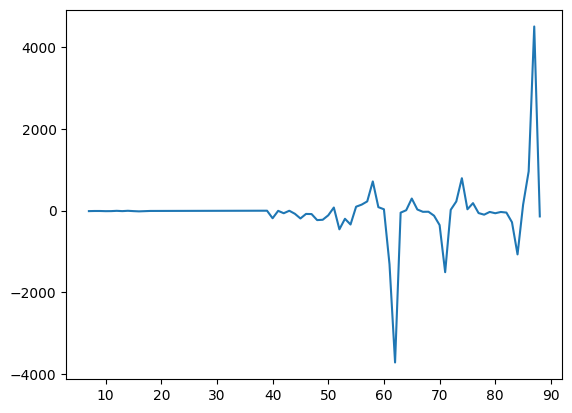

In [29]:
# ⑧ 추출된 특징 시각화하기
plt.plot(minimal_features_train['F_x__sum_values'])
plt.show()

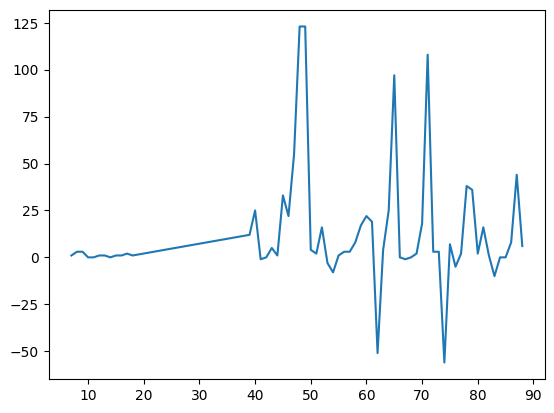

In [33]:
plt.plot(minimal_features_train['T_z__maximum'])
plt.show()

⑨ Logistic Regression 사용하기

회귀분석이라는 명칭과는 다르게 분류(Classification)를 할 때도 사용할 수 있습니다.
현재 사용중인 robot_execution_failures 데이터셋에서 y가 True와 False로 이루어져 있습니다. 이것은 이진 분류(binary classification) 문제이며 Logistic Regression을 사용할 수 있습니다.
Logistic Regression은 어떤 범주에 속할 확률을 0(False)에서 1(True) 사이의 값으로 예측할 수 있습니다.
x가 0.5보다 높거나 같은 경우 1, x가 0.5보다 낮은 경우는 0으로 분류합니다. (여기서 x는 독립변수인 feature라고 생각하시면 됩니다.)

In [34]:
# ⑨ Logistic Regression 사용하기
logistic = LogisticRegression()
logistic.fit(minimal_features_train, y_train)

LogisticRegression()

Logistic Regression score 확인하기

100% = 1.0이며 69% = 0.69...의 결과를 확인할 수 있습니다.

In [35]:
# ⑩ Logistic Regression score 확인하기
logistic.score(minimal_features_test, y_test)

0.8461538461538461

⑪ 분류 성능 평가 지표 확인하기

 - Classification report는 scikit-learn에서 제공되는 기능입니다. 모델 혹은 알고리즘은 score로만 결과를 신뢰할 수 없습니다. (여기서 말하는 모델 혹은 알고리즘은 Logistic Regression입니다) 모델을 거쳐 나온 결과값(output)을 분석하여 이유가 있고 설명 가능한 상태가 되어야 합니다.

 - Classification의 대표적인 검증 지표로 Precision, Recall, F1-score를 사용합니다.
 - 아래의 지표를 해석해보면 이진 분류이므로 True와 False 각각 정밀도(Precision), 재현율(Recall), 조화평균(F1-score)의 값을 보여줍니다.
 - 정확도(accuracy)는 score와 같습니다.
 - 매크로 평균(macro avg)은 평균의 평균이라고 합니다.(각 클래스별 평균 / 클래스  - 매크로 평균) 여기서 클래스란 minimal_feature_train의 feature들을 말합니다.  - 특징 추출 후 나온 feature의 개수는 60개 입니다.
 - 가중 산술 평균(weighted avg)은 자료의 평균을 구할 때 자료 값의 중요도나 영향 정도에 해당하는 가중치를 반영하여 구한 평균값입니다.

In [36]:
# ⑪ 분류 성능 평가 지표 확인하기
# y는 True, False는 Target으로도 표현할 수 있습니다.
classification_report(y_test, logistic.predict(minimal_features_test), target_names=['true', 'false'], output_dict=True) # y_test 내부에 있는 true, false와 일치하는 이름을 표시합니다.

{'true': {'precision': 1.0,
  'recall': 0.8,
  'f1-score': 0.8888888888888888,
  'support': 20.0},
 'false': {'precision': 0.6, 'recall': 1.0, 'f1-score': 0.75, 'support': 6.0},
 'accuracy': 0.8461538461538461,
 'macro avg': {'precision': 0.8,
  'recall': 0.9,
  'f1-score': 0.8194444444444444,
  'support': 26.0},
 'weighted avg': {'precision': 0.9076923076923078,
  'recall': 0.8461538461538461,
  'f1-score': 0.8568376068376069,
  'support': 26.0}}

Mini PJT : Airpassengers

In [1]:
!pip install tsfresh

In [2]:
# 라이브러리를 불러옵니다.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute

In [3]:
# air passengers 데이터를 불러옵니다.
ap = pd.read_csv("/content/drive/MyDrive/SQL_modu/1119_tsd/AirPassengers.csv")

print("원본 데이터:")
print(ap.head())
print(f"\n데이터 형태: {ap.shape}")


원본 데이터:
     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121

데이터 형태: (144, 2)


In [4]:
# 'Month' column을 삭제합니다.
ap_numeric = ap.drop('Month', axis=1)

In [5]:
ap

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [6]:
# np.log를 통해서 log transformation
log_transformed = np.log(ap_numeric)

print("\nLog 변환 후 데이터:")
print(log_transformed.head())



Log 변환 후 데이터:
   #Passengers
0     4.718499
1     4.770685
2     4.882802
3     4.859812
4     4.795791


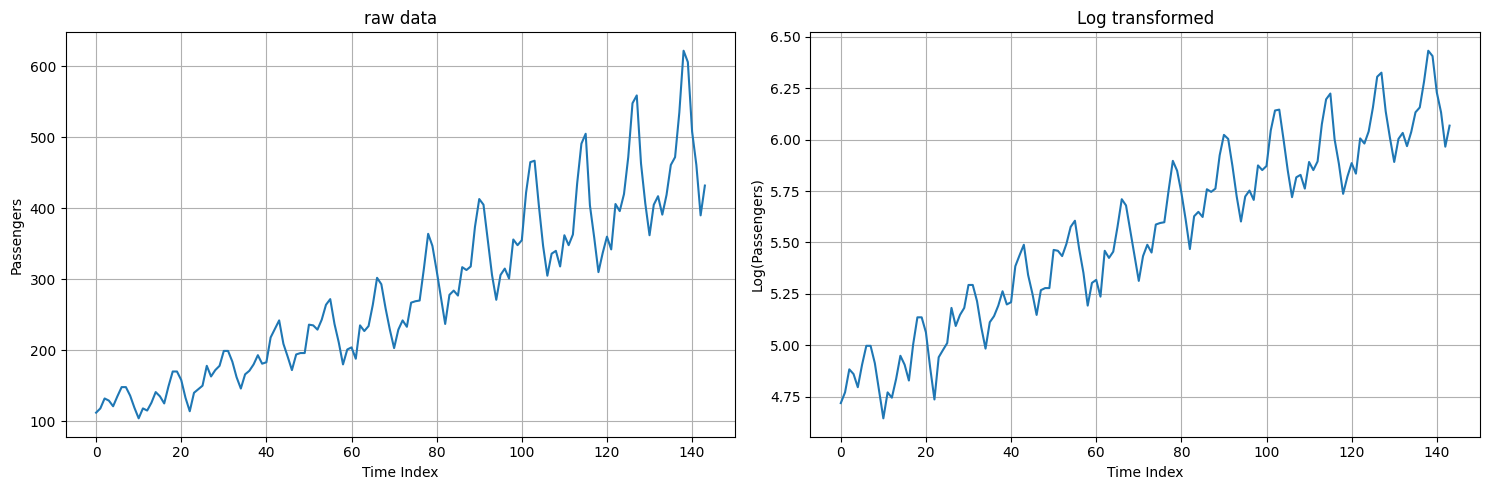

In [7]:
# 분산이 일정해진 것을 눈으로 확인할 수 있습니다.
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(ap.index, ap_numeric['#Passengers'])
plt.title('raw data')
plt.xlabel('Time Index')
plt.ylabel('Passengers')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(ap.index, log_transformed['#Passengers'])
plt.title('Log transformed')
plt.xlabel('Time Index')
plt.ylabel('Log(Passengers)')
plt.grid(True)

plt.tight_layout()
plt.show()

차분 수행

In [8]:
diffed = log_transformed.diff().dropna()
diffed

,#Passengers
1,0.052186
2,0.112117
3,-0.022990
4,-0.064022
5,0.109484
...,...
139,-0.026060
140,-0.176399
141,-0.097083
142,-0.167251


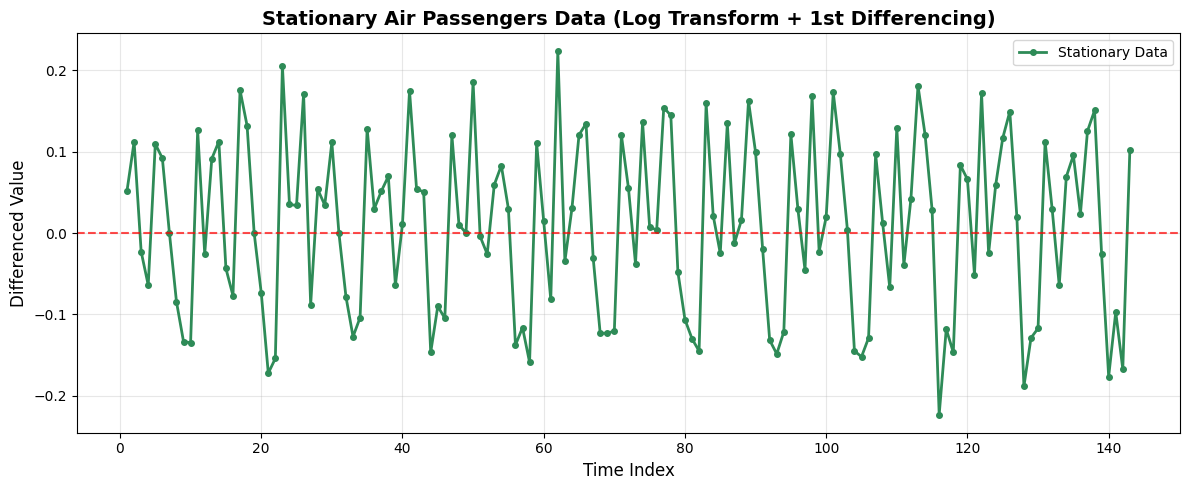

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(diffed.index, diffed['#Passengers'], marker='o', linestyle='-',
         linewidth=2, color='seagreen', markersize=4, label='Stationary Data')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Stationary Air Passengers Data (Log Transform + 1st Differencing)', fontsize=14, fontweight='bold')
plt.xlabel('Time Index', fontsize=12)
plt.ylabel('Differenced Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# 커지는 분산과 증가하는 추세를 제거한 air passengers 데이터를 얻을 수 있습니다.

# Plotly 버전
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=list(range(len(diffed))),
        y=diffed['#Passengers'],
        mode='lines+markers',
        name='정상화된 데이터',
        line=dict(color='seagreen', width=2),
        marker=dict(size=5)
    )
)

fig.add_hline(y=0, line_dash="dash", line_color="red")

fig.update_layout(
    title="정상화된 항공 승객 데이터 (Log 변환 + 1차 차분)",
    xaxis_title="Time Index",
    yaxis_title="차분 값",
    height=500,
    hovermode='x unified'
)

fig.show()

④ (추가) 계절 차분을 통해 계절성 제거하기
AirPassengers 데이터는 12개월을 주기로 하는 계절성이 포함되어 있습니다. 이런 경우엔 계절 차분을 통해서 계절성을 데이터에서 제거할 수 있습니다.

In [11]:
# diff에 12라는 값을 넣어주면 주기를 12로 하는 계절 차분을 수행할 수 있습니다.
seasonally_diffed = diffed.diff(12)
# 차분을 하면 데이터가 짧아지기 때문에 빈칸을 제거해야 합니다.
seasonally_diffed.dropna(inplace = True)
# 형태를 확인해봅시다.
seasonally_diffed

,#Passengers
13,0.039164
14,0.000361
15,-0.020496
16,-0.012939
17,0.066148
...,...
139,-0.045934
140,0.012024
141,0.031830
142,-0.050082


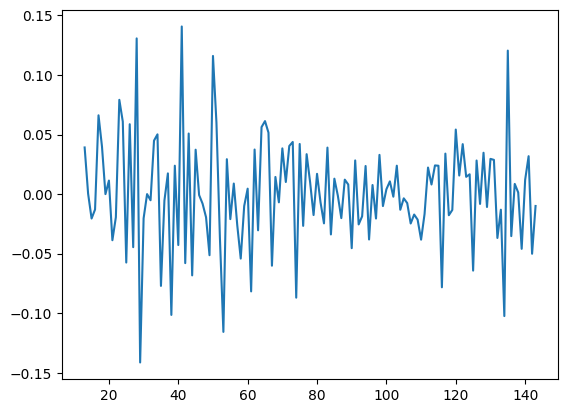

In [12]:
# 아래와 같은 데이터를 얻을 수 있습니다.
plt.figure()
plt.plot(seasonally_diffed)
plt.show()

 검정을 통해 정상성 확인하기
- adfuller : Python에서 statsmodels을 통해 ADF(Augmented Dickey-Fuller) Test를 할 수 있습니다.
- 앞서 Classification report를 통해 Logistic Regression 모델을 검증한 것과 마찬가지로 시계열 데이터를 통계 분석하고 검증할 때 사용합니다.
-  adfuller를 사용하면 대표적으로 다음과 같은 값을 얻을 수 있습니다.

        adf(단위근 검정, Augmented Dickey Fuller) : 정상성을 확인하기 위한 단위근 검정방법
        p-value(유의 검정) : 관찰된 데이터가 귀무가설이 맞다면 통계값 1이 실제로 관측된 값 이상일 확률
        usedlag : 사용된 시차의 수
        nobs : ADF 회귀 및 임계값 계산에 사용된 관측치의 수
        critical values(임계값) : 1%, 5% 및 10% 수준에서 테스트 통계에 대한 임계값
        icbest : 0, 1, …, maxlag 값 중 lag 길이를 자동으로 결정할 때 autolag를 사용하며 이때 autolag를 none으로 지정할 수 있는데 none으로 지정하지 않는 경우 최대화된 정보 기준

In [13]:
from statsmodels.tsa.stattools import adfuller

def adf_test(x): # adf검정을 위한 함수 정의
    stat, p_value, lags, nobs, crit, icb = adfuller(x) # adfuller 함수를 이용하면 6가지 output이 나옵니다.
    print('ADF statistics')
    print(stat) # ADF 검정 통계량입니다.
    print('P-value')
    print(p_value) # P-value입니다.

In [14]:
# 계절차분까지 수행한 데이터로 adf 테스트를 수행합니다.

from statsmodels.tsa.stattools import adfuller

def adf_test(x): # adf검정을 위한 함수 정의
    stat, p_value, lags, nobs, crit, icb = adfuller(x) # adfuller 함수를 이용하면 6가지 output이 나옵니다.
    print('ADF statistics')
    print(stat) # ADF 검정 통계량입니다.
    print('P-value')
    print(p_value) # P-value입니다.
    print('Critical Values')
    print(crit) # 임계값입니다.
    print('-' * 50)

    # 결과 해석
    if p_value < 0.05:
        print(' Result: Stationary (p-value < 0.05)')
        print('The time series is stationary.')
    else:
        print(' Result: Non-Stationary (p-value >= 0.05)')
        print('The time series is NOT stationary.')

# 원본 데이터로 adf 테스트
print("=== Original Data ===")
adf_test(ap_numeric['#Passengers'])

print("\n=== Log Transformed Data ===")
adf_test(log_transformed['#Passengers'])

print("\n=== After 1st Differencing ===")
adf_test(diffed['#Passengers'])

# 계절차분까지 수행한 데이터로 adf 테스트를 수행합니다.
seasonal_diffed = log_transformed.diff(12).dropna()
print("\n=== After Seasonal Differencing (12 months) ===")
adf_test(seasonal_diffed['#Passengers'])

# 1차 차분 + 계절 차분
double_diffed = diffed.diff(12).dropna()
print("\n=== After 1st Differencing + Seasonal Differencing ===")
adf_test(double_diffed['#Passengers'])

=== Original Data ===
ADF statistics
0.8153688792060498
P-value
0.991880243437641
Critical Values
{'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
--------------------------------------------------
 Result: Non-Stationary (p-value >= 0.05)
The time series is NOT stationary.

=== Log Transformed Data ===
ADF statistics
-1.7170170891069683
P-value
0.4223667747703874
Critical Values
{'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
--------------------------------------------------
 Result: Non-Stationary (p-value >= 0.05)
The time series is NOT stationary.

=== After 1st Differencing ===
ADF statistics
-2.717130598388114
P-value
0.07112054815086184
Critical Values
{'1%': np.float64(-3.4825006939887997), '5%': np.float64(-2.884397984161377), '10%': np.float64(-2.578960197753906)}
--------------------------------------------------
 Result: Non-Stationary 

⑥ 시계열 분류
강의 때 Logistic Regression을 이용한 시계열 분류가 낮은 score를 보였습니다. 앙상블 모델과 더 많은 특징을 활용해서 분류 성능을 높여봅시다!

In [15]:
# ⑥-1 : 데이터 다운로드 및 불러오기
from tsfresh.examples.robot_execution_failures import download_robot_execution_failures, load_robot_execution_failures

# robot exection failures 데이터를 불러옵니다.
download_robot_execution_failures()
timeseries, y = load_robot_execution_failures()

In [16]:
# ⑥-2 : 데이터셋 확인(timeseries와 y 확인)
timeseries # id, time을 제외하고 6개 column의 X변수가 나타납니다.

,id,time,F_x,F_y,F_z,T_x,T_y,T_z
0,1,0,-1,-1,63,-3,-1,0
1,1,1,0,0,62,-3,-1,0
2,1,2,-1,-1,61,-3,0,0
3,1,3,-1,-1,63,-2,-1,0
4,1,4,-1,-1,63,-3,-1,0
...,...,...,...,...,...,...,...,...
1315,88,10,-10,2,39,-21,-24,5
1316,88,11,-11,2,38,-24,-22,6
1317,88,12,-12,3,23,-24,-24,5
1318,88,13,-13,4,26,-29,-27,5


In [17]:
y # true/false가 제시되어 있습니다.

,0
1,True
2,True
3,True
4,True
5,True
...,...
84,False
85,False
86,False
87,False


In [18]:
print("Timeseries shape:", timeseries.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTimeseries sample:")
print(timeseries.head())


def custom_classification_split(x, y, test_size=0.3): # 수업 때 보았던 custom split 함수

    num_true = int(y.sum() * test_size)
    num_false = int((len(y) - y.sum()) * test_size)

    id_list = y[y==False].head(num_false).index.to_list() + y[y==True].head(num_true).index.to_list()

    y_train = y[~y.index.isin(id_list)]
    y_test = y[y.index.isin(id_list)]
    X_train = x[~x.index.isin(id_list)]
    X_test = x[x.index.isin(id_list)]

    return X_train, y_train, X_test, y_test


# 함수 테스트
print("\n=== Testing custom_classification_split ===")
X_train, y_train, X_test, y_test = custom_classification_split(timeseries, y, test_size=0.3)

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\ny_train distribution:")
print(y_train.value_counts())
print("\ny_test distribution:")
print(y_test.value_counts())

Timeseries shape: (1320, 8)
Target shape: (88,)

Target distribution:
False    67
True     21
Name: count, dtype: int64

Timeseries sample:
   id  time  F_x  F_y  F_z  T_x  T_y  T_z
0   1     0   -1   -1   63   -3   -1    0
1   1     1    0    0   62   -3   -1    0
2   1     2   -1   -1   61   -3    0    0
3   1     3   -1   -1   63   -2   -1    0
4   1     4   -1   -1   63   -3   -1    0

=== Testing custom_classification_split ===

X_train shape: (1294, 8)
y_train shape: (62,)
X_test shape: (26, 8)
y_test shape: (26,)

y_train distribution:
False    47
True     15
Name: count, dtype: int64

y_test distribution:
False    20
True      6
Name: count, dtype: int64


In [19]:
# ⑥-4 : 데이터셋 나누기
# test set의 비율을 0.25로 지정해주세요.
X_train, y_train, X_test, y_test = custom_classification_split(timeseries, y, test_size=0.25)

print("\n=== Final Train/Test Split (test_size=0.25) ===")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\ny_train distribution:")
print(y_train.value_counts())
print("\ny_test distribution:")
print(y_test.value_counts())


=== Final Train/Test Split (test_size=0.25) ===
X_train shape: (1299, 8)
y_train shape: (67,)
X_test shape: (21, 8)
y_test shape: (21,)

y_train distribution:
False    51
True     16
Name: count, dtype: int64

y_test distribution:
False    16
True      5
Name: count, dtype: int64


EfficientParameters는 큰 계산비용이 필요한 calculator를 제외하고 가능한 모든 특징을 생성합니다.

In [20]:
from tsfresh import extract_features
from tsfresh.feature_extraction import EfficientFCParameters
from tsfresh.utilities.dataframe_functions import impute

settings = EfficientFCParameters()

In [21]:
# ⑥-5 : Feature extraction
comprehensive_features_train = extract_features(
                                    X_train,
                                    column_id="id",
                                    column_sort="time",
                                    default_fc_parameters=settings
                                          )

Feature Extraction: 100%|██████████| 528/528 [00:53<00:00,  9.92it/s]


In [32]:
comprehensive_features_test = extract_features(
                                    X_test,
                                    column_id="id",
                                    column_sort="time",
                                    default_fc_parameters=settings
                                          )

Feature Extraction: 100%|██████████| 18/18 [00:01<00:00, 12.13it/s]


impute를 통해 간단히 데이터를 전처리합니다.

In [29]:
# ⑥-6 : impute
# https://dining-developer.tistory.com/19

# impute(comprehensive_features_train)

from tsfresh.utilities.dataframe_functions import impute
comprehensive_features_train = impute(comprehensive_features_train)

In [34]:
from tsfresh.utilities.dataframe_functions import impute
comprehensive_features_test = impute(comprehensive_features_test)

첫번째로 Random Forest 모델을 활용해보겠습니다.

In [35]:
# ⑥-7 : RandomForest 사용 및 score 확인

# 인덱스 정렬 (에러 방지)
common_indices = comprehensive_features_train.index.intersection(y_train.index)
comprehensive_features_train = comprehensive_features_train.loc[common_indices]
y_train = y_train.loc[common_indices]

#  RandomForest 사용
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42)
rf_clf.fit(comprehensive_features_train, y_train)

# score확인
print(f"Train Score: {rf_clf.score(comprehensive_features_train, y_train):.4f}")

Train Score: 1.0000


In [36]:
# test셋에 적합해본 결과 약 0.66의 정확도를 보이며 불만족스러운 결과를 확인할 수 있습니다.

common_test_indices = comprehensive_features_test.index.intersection(y_test.index)
comprehensive_features_test = comprehensive_features_test.loc[common_test_indices]
y_test = y_test.loc[common_test_indices]

# score확인
print(f"test Score: {rf_clf.score(comprehensive_features_test, y_test):.4f}")

"""
중복 확인
"""
import numpy as np

print("Train shape:", comprehensive_features_train.shape)
print("Test  shape:", comprehensive_features_test.shape)

# 값이 완전히 같은지 검사
same_all = np.array_equal(
    comprehensive_features_train.values,
    comprehensive_features_test.values
)
print("Train과 Test의 값이 완전히 같은가? :", same_all)

# 인덱스 겹치는지(같은 id가 들어갔는지)도 확인
overlap_idx = set(comprehensive_features_train.index) & set(comprehensive_features_test.index)
print("Train/Test index 겹치는 개수 :", len(overlap_idx))



test Score: 1.0000
Train shape: (67, 4662)
Test  shape: (3, 4662)
Train과 Test의 값이 완전히 같은가? : False
Train/Test index 겹치는 개수 : 0


In [45]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# 1. XGBoost 모델 정의
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    random_state=42,
    objective="binary:logistic",
    eval_metric="auc",   # 원하면 'logloss'나 'error'로 바꿔도 됨
)

# 2. 모델 학습
xgb_clf.fit(comprehensive_features_train, y_train)

# 3. 예측
y_pred_train = xgb_clf.predict(comprehensive_features_train)
y_pred_test  = xgb_clf.predict(comprehensive_features_test)

# 4. 정확도 출력
print("=== Accuracy ===")
print(f"Train acc : {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test  acc : {accuracy_score(y_test,  y_pred_test):.4f}")

# 5. 혼동 행렬 & 리포트
print("\n[Train confusion matrix]")
print(confusion_matrix(y_train, y_pred_train))

print("\n[Test confusion matrix]")
print(confusion_matrix(y_test, y_pred_test))

print("\n[Test classification report]")
print(classification_report(y_test, y_pred_test, zero_division=0))

# 6. 테스트 샘플 몇 개 직접 눈으로 보기
print("\n[Test 예측 샘플]")
print(pd.DataFrame({
    "y_test": y_test.values,
    "pred"  : y_pred_test
}))

=== Accuracy ===
Train acc : 1.0000
Test  acc : 1.0000

[Train confusion matrix]
[[51  0]
 [ 0 16]]

[Test confusion matrix]
[[3]]

[Test classification report]
              precision    recall  f1-score   support

        True       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


[Test 예측 샘플]
   y_test  pred
0    True     1
1    True     1
2    True     1


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning:

A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.



두번째로 XGBoost를 활용하겠습니다

In [39]:
# ⑥-7 : XGBoost 사용 및 score 확인
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    n_estimators=10,
    max_depth=3,
    random_state=42,
    objective='binary:logistic',
    eval_metric='logloss'   # 또는 'error', 'auc' 등 원하는 걸로
)

# XGBoost 모델을 학습시킵니다.
xgb_clf.fit(comprehensive_features_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=10, n_jobs=None,
              num_parallel_tree=None, ...)

In [40]:
# XGBoost 모델의 score를 확인합니다.
train_score = xgb_clf.score(comprehensive_features_train, y_train)
test_score = xgb_clf.score(comprehensive_features_test, y_test)

print(f"XGBoost Train Score: {train_score:.4f}")
print(f"XGBoost Test Score: {test_score:.4f}")

XGBoost Train Score: 1.0000
XGBoost Test Score: 1.0000


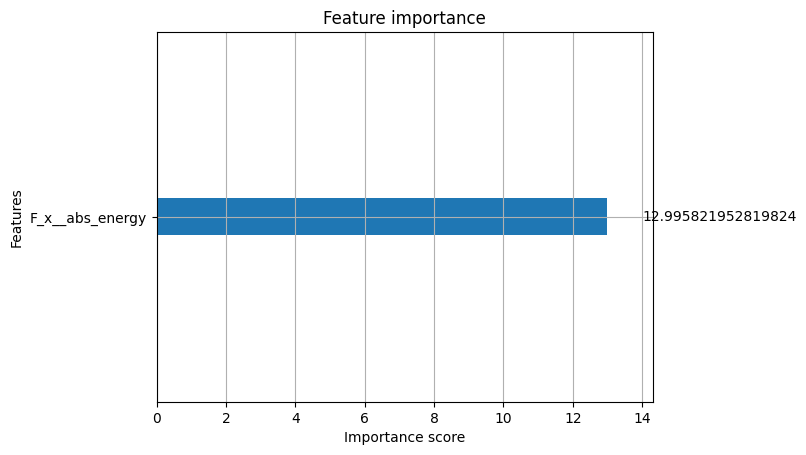

In [41]:
# ⑥-8 : XGBoost plot_importance 확인 및 시각화
# plot_importance를 통해 어떤 변수(특징)가 가장 유의미한지 확인합니다.
xgb.plot_importance(xgb_clf, importance_type = 'gain')
plt.show()

In [42]:
sum(xgb_clf.feature_importances_ != 0) # Fx 값의 abs_energy 특징만의 유의미함

np.int64(1)

결국 고장 유무를 판별하는 기준은 F_X_abs_energy라는 특징 하나였습니다!

In [46]:
# ⑥-9 : Classification report를 통한 검증 및 분석
from sklearn.metrics import classification_report

y_pred_test = xgb_clf.predict(comprehensive_features_test)

report = classification_report(
    y_test,
    y_pred_test,
    output_dict=True,
    zero_division=0  # 0으로 나누는 상황(정의 안되는 경우)에서 경고 방지
)

print(report)


{'True': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 3.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 3.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 3.0}}


=== classification_report DataFrame ===
              precision  recall  f1-score  support
True                1.0     1.0       1.0      3.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0      3.0
weighted avg        1.0     1.0       1.0      3.0

=== 해석 리포트 ===
- 테스트셋에는 True 샘플이 3개 포함되어 있습니다. (False는 0개)
- 모델은 이 3개 샘플을 모두 True로 예측했기 때문에,
  precision = 1.00, recall = 1.00, f1-score = 1.00 로 1.00이 나왔습니다.
- accuracy, macro avg, weighted avg도 모두 1.00인데,
  이는 테스트셋에 한 클래스(True)만 있고 표본 수가 3개뿐이기 때문에
  지표가 과대평가(overfitting처럼 보이는) 상태라고 해석해야 합니다.
- 따라서 이 결과는 '이 작은 테스트셋에서는 3개를 다 맞췄다' 정도의 의미만 가지며,
  실제 성능 평가는 교차검증(CV)이나 더 큰/균형 잡힌 테스트셋에서 다시 확인하는 것이 좋습니다.


<Figure size 800x400 with 0 Axes>

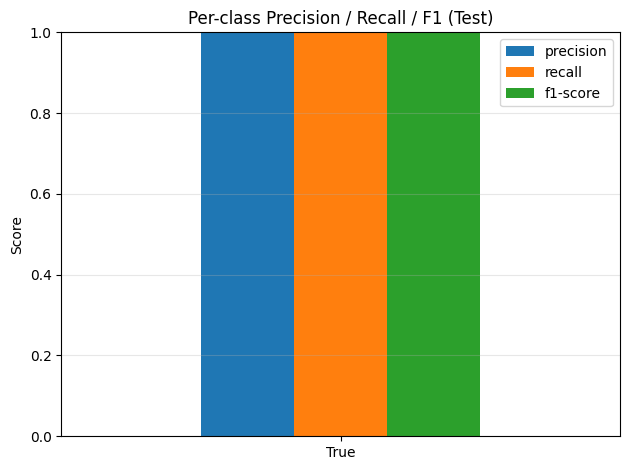

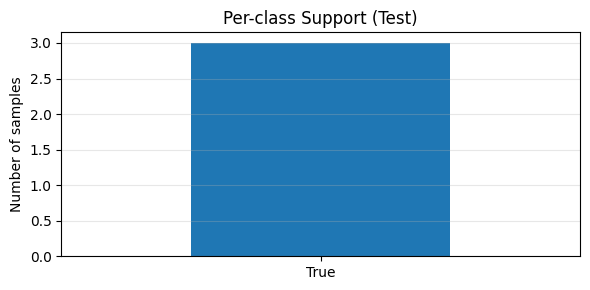

In [47]:
# ⑥-9 : Classification report를 통한 검증 및 분석 + 해석 리포트 + 시각화
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# 1) 예측값
y_pred_test = xgb_clf.predict(comprehensive_features_test)

# 2) classification_report 계산 (dict 형태)
report_dict = classification_report(
    y_test,
    y_pred_test,
    output_dict=True,
    zero_division=0
)

# 3) DataFrame 변환 및 출력
df_report = pd.DataFrame(report_dict).T

print("=== classification_report DataFrame ===")
print(df_report.round(3))

# 4) True 클래스 기준으로 통계치 뽑기
true_row = df_report.loc["True"]
true_precision = true_row["precision"]
true_recall    = true_row["recall"]
true_f1        = true_row["f1-score"]
true_support   = int(true_row["support"])

print("\n=== 해석 리포트 ===")
print(f"- 테스트셋에는 True 샘플이 {true_support}개 포함되어 있습니다. (False는 0개)")
print(f"- 모델은 이 {true_support}개 샘플을 모두 True로 예측했기 때문에,")
print(f"  precision = {true_precision:.2f}, recall = {true_recall:.2f}, f1-score = {true_f1:.2f} 로 1.00이 나왔습니다.")
print("- accuracy, macro avg, weighted avg도 모두 1.00인데,")
print("  이는 테스트셋에 한 클래스(True)만 있고 표본 수가 3개뿐이기 때문에")
print("  지표가 과대평가(overfitting처럼 보이는) 상태라고 해석해야 합니다.")
print("- 따라서 이 결과는 '이 작은 테스트셋에서는 3개를 다 맞췄다' 정도의 의미만 가지며,")
print("  실제 성능 평가는 교차검증(CV)이나 더 큰/균형 잡힌 테스트셋에서 다시 확인하는 것이 좋습니다.")

# 5) 클래스별 precision/recall/f1 시각화
cls_rows = [idx for idx in df_report.index
            if idx not in ["accuracy", "macro avg", "weighted avg"]]
metrics = ["precision", "recall", "f1-score"]
df_cls = df_report.loc[cls_rows, metrics]

plt.figure(figsize=(8, 4))
df_cls.plot(kind="bar", ylim=(0, 1), rot=0)
plt.title("Per-class Precision / Recall / F1 (Test)")
plt.ylabel("Score")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 6) support 시각화
plt.figure(figsize=(6, 3))
df_report.loc[cls_rows, "support"].plot(kind="bar", rot=0)
plt.title("Per-class Support (Test)")
plt.ylabel("Number of samples")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
